# Does a generative or a contrastive latent space propagate labels better?

**Semi-supervised classification on STL-10.**
Tomer Karmazin and Lior Reznik — Afeka College, *Advanced Methods in Machine Learning*.

---

## The question

STL-10 gives us 100,000 unlabeled images and only 1,000 labeled ones per fold. We want to
know which kind of self-supervised representation makes those few labels go furthest, so we
hold everything fixed except the pretraining objective:

| | Generative arm | Contrastive arm |
|---|---|---|
| Objective | β-VAE (evidence lower bound) | SimCLR (NT-Xent) |
| Encoder | SE-ResNet, 13.4M parameters | the same SE-ResNet |
| Embedding | `mu`, 512-d | pooled features, 512-d |
| Downstream | KNN graph → label propagation → CNN, **plus a linear probe** | linear probe |

The linear-probe row is the comparison. The CNN row answers a narrower question and is
reported beside it, never instead of it.

## Two rules that shaped every line below

**Build from zero — for the method.** No SciPy, no FAISS, no NetworkX, no
`torchvision.models`, and no `torchvision.transforms`. The KNN graph, label propagation,
union-find, every metric, the SE-ResNet, and both augmentation pipelines are written out in
this notebook in PyTorch and NumPy. Section 14 verifies each of them against the reference
implementation it replaces.

The **evaluation probe** is the one deliberate exception. It is written out here too, but
scikit-learn's `LogisticRegression` is also run, on both arms, and section 12 reports the two
side by side. A downstream estimator is not part of the method under study, and showing that
the conclusion does not depend on whose logistic regression fitted it is worth more than
excluding the library.

**The test split is opened once.** Every hyperparameter is chosen on a held-out development
split. The selection is written to disk and hashed before section 12 reads the test set for
the first and only time.

## How to run this

Cells are ordered top to bottom and each heavy stage caches its output under `runs/`. A
cold run trains everything and takes roughly two days on one RTX 5090; re-running afterwards
reloads the cached artifacts in minutes. Set `FORCE_RETRAIN = True` in section 0 to ignore
the cache.

## Contents

| § | Stage | Cold-run cost |
|---|---|---|
| 0 | Configuration, seeding, disk and device checks | seconds |
| 1 | STL-10 without torchvision: parsing, folds, splits, normalization | ~2 min |
| 2 | The shared SE-ResNet trunk | seconds |
| 3 | Augmentation, hand-written: the light VAE policy and the four SimCLR policies | seconds |
| 4 | Optimizer and learning-rate schedule | seconds |
| 5 | Contrastive arm: projection head, NT-Xent, four 100-epoch pretrains | 20–30 h |
| 6 | Generative arm: decoder, β-VAE, eight 100-epoch pretrains | 12–16 h |
| 7 | Frozen embeddings | ~20 min |
| 8 | The KNN graph, chunked | ~30 min |
| 9 | Label propagation: hard clamping, label spreading, and why the first one fails | ~1 h |
| 10 | The linear probe | ~15 min |
| 11 | Selection: K, α, β, C, and the augmentation policy | ~3 h |
| 12 | The test benchmark — the split is read here, once | ~30 min |
| 13 | Results, figures, and the fairness audit | ~5 min |
| 14 | Verification of the hand-written components | ~2 min |

---

# 0. Configuration

Everything the two arms must share is written down once, here, and imported by every stage
below. Retyping a constant per stage is how two arms silently stop being comparable.

The values marked *reference* were read out of the original SimCLR notebook
(`reference/simclr_stl10_abilation_f.ipynb`) and must not be changed on one side only.

In [1]:
import hashlib
import json
import math
import os
import random
import shutil
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- reproducibility -------------------------------------------------------
SEED = 42

# --- data geometry (reference) --------------------------------------------
IMAGE_SIZE = 96
NUM_CLASSES = 10
NUM_UNLABELED_IMAGES = 100_000
NUM_TRAIN_IMAGES = 5_000
NUM_TEST_IMAGES = 8_000

# The propagation graph spans the unlabeled split plus the labeled train split, so every
# node a label could reach lives in one array.
NUM_GRAPH_NODES = NUM_UNLABELED_IMAGES + NUM_TRAIN_IMAGES

# --- pretraining budget (reference) ---------------------------------------
# Identical for both arms. This is what "same budget" means concretely.
BATCH_SIZE = 256
FEATURE_BATCH_SIZE = 512
EPOCHS = 100
WARMUP_EPOCHS = 10
MAX_LEARNING_RATE = 5e-4
MIN_LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4

# --- encoder trunk (reference) --------------------------------------------
STEM_WIDTH = 48
STAGE_DEPTHS = (2, 3, 4, 3)
STAGE_WIDTHS = (64, 128, 256, 384)
ENCODER_DIM = 512
SE_REDUCTION = 16

# --- contrastive head (reference) -----------------------------------------
PROJECTOR_HIDDEN_DIM = 512
PROJECTOR_OUTPUT_DIM = 128
TEMPERATURE = 0.20

# --- generative head -------------------------------------------------------
# The latent must match the encoder width. Lior's embedding is the 512-d pooled trunk
# feature with the projection head discarded, so mu has to be 512-d as well; a narrower
# latent would hand the contrastive arm a dimensionality advantage that has nothing to do
# with the research question.
LATENT_DIM = ENCODER_DIM
BETA_WARMUP_EPOCHS = 10

# beta = 0 is the plain-autoencoder control: it isolates how much of the result comes from
# the variational term rather than from reconstruction alone. The upper end reaches 1.0,
# the canonical VAE, because the earlier grid stopped at 0.1 with accuracy still rising and
# we could not say where it turns over.
BETA_GRID = (0.0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0)

# --- graph and propagation -------------------------------------------------
K_GRID = (5, 10, 15, 20, 30, 50)
LP_ALPHA_GRID = (0.50, 0.80, 0.90, 0.95, 0.99)
LP_MAX_ITERATIONS = 3000
LP_TOLERANCE = 1e-6

# Rows of the similarity matrix computed per chunk. Section 8 does the arithmetic.
SIMILARITY_CHUNK_ROWS = 1024

# --- probe (reference) -----------------------------------------------------
LINEAR_C_GRID = (0.1, 1.0, 10.0, 100.0)
CROSS_VALIDATION_SPLITS = 5
LINEAR_MAX_ITERATIONS = 5000
LINEAR_TOLERANCE = 1e-4

# --- evaluation protocol (reference) --------------------------------------
NUM_FOLDS = 10
FOLD_SIZE = 1000
VALIDATION_FRACTION = 0.20

# --- paths -----------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"
RUNS_ROOT = PROJECT_ROOT / "runs"
RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_ROOT = RESULTS_ROOT / "figures"

for folder in (RUNS_ROOT, RESULTS_ROOT, FIGURES_ROOT):
    folder.mkdir(parents=True, exist_ok=True)

# Set True to ignore every cached artifact and retrain from scratch.
FORCE_RETRAIN = False

print("project root :", PROJECT_ROOT)
print("data         :", DATA_ROOT)
print("runs         :", RUNS_ROOT)
print("seed         :", SEED)
print("beta grid    :", BETA_GRID)
print("K grid       :", K_GRID)
print("alpha grid   :", LP_ALPHA_GRID)

project root : /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison
data         : /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/data
runs         : /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/runs
seed         : 42
beta grid    : (0.0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0)
K grid       : (5, 10, 15, 20, 30, 50)
alpha grid   : (0.5, 0.8, 0.9, 0.95, 0.99)


## 0.1 Seeding

Both arms are seeded identically and both run deterministic CUDA kernels. If only one arm
were deterministic, part of any gap between them would be kernel nondeterminism rather than
the objective, and the comparison would not be falsifiable.

`use_deterministic_algorithms(True)` makes PyTorch raise rather than silently substitute a
nondeterministic kernel, so a regression fails loudly instead of quietly polluting results.
`CUBLAS_WORKSPACE_CONFIG` has to be set before the CUDA context exists, which is why it is
here rather than further down.

In [2]:
def reset_seed(seed=SEED):
    """Reseed every random source the pipeline touches."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def seeded_generator(seed=SEED):
    """A CPU generator for anything that accepts one explicitly.

    Shuffles and splits draw from their own generator rather than the global stream, so
    inserting an unrelated random call elsewhere does not shift which images land in which
    fold.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def enable_deterministic():
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    # TF32 truncates the mantissa to about 10 bits. On a 512-term dot product that
    # manufactures ties in the KNN search, which would make the graph differ between
    # machines. Section 8 depends on this being off.
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


enable_deterministic()
reset_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device       :", DEVICE)
if DEVICE.type == "cuda":
    print("gpu          :", torch.cuda.get_device_name(0))
    print("vram         : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
print("torch        :", torch.__version__)
print("deterministic: on")

device       : cuda
gpu          : NVIDIA GeForce RTX 5090
vram         : 33.7 GB
torch        : 2.11.0+cu128
deterministic: on


## 0.2 Caching and the disk guard

Each heavy stage writes its artifact under `runs/` and reloads it on a later pass. Two
reasons this is worth the small amount of extra code:

1. A cold run of this notebook is on the order of two days. Without checkpoints, one kernel
   disconnect at hour thirty costs the entire run.
2. The hyperparameter sweeps in section 11 read a cached embedding array rather than
   re-encoding 105,000 images per cell, which is the difference between minutes and hours.

The disk guard is not decoration. The lab server has a single volume shared with other
projects and no quotas, so a run that fills the root filesystem takes the machine down for
everyone. Every stage that writes calls `require_disk` first.

In [3]:
MINIMUM_FREE_GIGABYTES = 12.0


def free_gigabytes(path=None):
    """Free space on the volume holding `path`, in GB."""
    target = Path(path) if path is not None else PROJECT_ROOT
    while not target.exists():
        target = target.parent
    return shutil.disk_usage(target).free / (1024 ** 3)


def require_disk(minimum=MINIMUM_FREE_GIGABYTES, what="this stage"):
    """Abort before writing if the volume is close to full."""
    available = free_gigabytes()
    if available < minimum:
        raise RuntimeError(
            "Only %.1f GB free; %s needs at least %.1f GB. Free space before continuing -- "
            "a run that fills the root filesystem takes down the whole machine."
            % (available, what, minimum)
        )
    return available


def cached(path, build, description=None, force=None):
    """Return the artifact at `path`, building and saving it when it is missing.

    `build` is a zero-argument callable returning a picklable object. Anything that takes
    real time in this notebook goes through here, which is what makes a re-run cheap and a
    cold run resumable.
    """
    path = Path(path)
    should_force = FORCE_RETRAIN if force is None else force
    label = description or path.name

    if path.exists() and not should_force:
        print("[cache hit ] %s" % label)
        return torch.load(path, map_location="cpu", weights_only=False)

    require_disk(what=label)
    print("[building  ] %s" % label)
    started = time.time()
    artifact = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(artifact, path)
    print("[done      ] %s in %s" % (label, format_duration(time.time() - started)))
    return artifact


def format_duration(seconds):
    seconds = int(seconds)
    if seconds < 60:
        return "%ds" % seconds
    if seconds < 3600:
        return "%dm %02ds" % (seconds // 60, seconds % 60)
    return "%dh %02dm" % (seconds // 3600, (seconds % 3600) // 60)


print("free disk    : %.1f GB" % free_gigabytes())
require_disk(what="the full notebook")
print("disk guard   : ok")

free disk    : 39.8 GB
disk guard   : ok


---

# 1. STL-10 without torchvision

`torchvision.datasets.STL10` is off the table, so we parse `stl10_binary/` directly with
`numpy.fromfile`. That is also the cheaper option on a server where disk is the binding
constraint: reading seven files does not justify pulling in the whole torchvision wheel.

The dataset ships three splits and one file that matters more than it looks:

| file | contents |
|---|---|
| `unlabeled_X.bin` | 100,000 images, 2.76 GB as uint8. **Deliberately broader than the 10 labeled classes** |
| `train_X.bin` / `train_y.bin` | 5,000 labeled images |
| `test_X.bin` / `test_y.bin` | 8,000 labeled images |
| `fold_indices.txt` | **10 official folds**, each 1,000 indices into the labeled train split |

The folds are the evaluation protocol. Using them rather than our own random subsets is what
makes these numbers comparable to each other and to the published STL-10 literature.

### The transpose is not optional

STL-10 stores each image **column-major** inside a row-major byte stream. Reshaping to
`[N, 3, 96, 96]` therefore lands the pixels in `[N, C, W, H]` order, not `[N, C, H, W]`.

Drop the axis swap and every image is transposed. Nothing raises. The VAE trains, the graph
builds, propagation converges, and every number in the report is quietly wrong. Section 1.5
displays a sample grid specifically so this is visible rather than assumed.

In [4]:
NUMBER_OF_CHANNELS = 3
EXPECTED_SPLIT_SIZES = {"train": 5000, "test": 8000, "unlabeled": 100000}
SPLIT_FILE_NAMES = {
    "train": ("train_X.bin", "train_y.bin"),
    "test": ("test_X.bin", "test_y.bin"),
    "unlabeled": ("unlabeled_X.bin", None),
}


def resolve_binary_directory(data_root):
    """Accept either the parent directory or the extracted archive itself."""
    nested = Path(data_root) / "stl10_binary"
    return nested if nested.is_dir() else Path(data_root)


def load_images(path):
    """Read one image binary into uint8 [N, 3, 96, 96]."""
    raw = np.fromfile(path, dtype=np.uint8)
    images = raw.reshape(-1, NUMBER_OF_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    return np.transpose(images, (0, 1, 3, 2))   # undoes column-major storage; required


def load_images_memory_mapped(path):
    """Lazy view of an image binary, for the 2.76 GB unlabeled split.

    The transpose is represented by swapped strides rather than moved bytes, so the result
    is non-contiguous. Anything needing a contiguous buffer must call
    `np.ascontiguousarray` on the slice it wants.
    """
    raw = np.memmap(path, dtype=np.uint8, mode="r")
    images = raw.reshape(-1, NUMBER_OF_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    return np.transpose(images, (0, 1, 3, 2))


def load_labels(path):
    """Read one label binary into int64 [N] with values 0..9.

    The files store labels 1-indexed as uint8; subtracting one keeps class id 3 meaning the
    same animal everywhere.
    """
    return np.fromfile(path, dtype=np.uint8).astype(np.int64) - 1


def load_split(data_root, split, memory_map_unlabeled=True):
    """Load one STL-10 split as (images uint8 [N,3,96,96], labels int64 [N] or None)."""
    if split not in SPLIT_FILE_NAMES:
        raise ValueError("split must be one of %s, got %r" % (sorted(SPLIT_FILE_NAMES), split))

    binary_directory = resolve_binary_directory(data_root)
    image_file_name, label_file_name = SPLIT_FILE_NAMES[split]
    image_path = binary_directory / image_file_name

    if not image_path.is_file():
        raise FileNotFoundError(
            "Could not find %s. Expected the extracted stl10_binary/ archive under %r."
            % (image_path, str(data_root))
        )

    if split == "unlabeled" and memory_map_unlabeled:
        images = load_images_memory_mapped(image_path)
    else:
        images = load_images(image_path)

    expected = EXPECTED_SPLIT_SIZES[split]
    if len(images) != expected:
        raise ValueError(
            "Split %r should hold %d images but %s decoded to %d. A truncated download is "
            "the usual cause." % (split, expected, image_path, len(images))
        )

    if label_file_name is None:
        return images, None

    labels = load_labels(binary_directory / label_file_name)
    if len(labels) != len(images):
        raise ValueError("Image/label count mismatch for %r: %d vs %d"
                         % (split, len(images), len(labels)))
    return images, labels


def load_class_names(data_root):
    path = resolve_binary_directory(data_root) / "class_names.txt"
    with io_open(path) as handle:
        return [line.strip() for line in handle if line.strip()]


def io_open(path):
    return open(path, "r", encoding="utf-8")


train_images, train_labels = load_split(DATA_ROOT, "train")
test_images, test_labels = load_split(DATA_ROOT, "test")
unlabeled_images, _ = load_split(DATA_ROOT, "unlabeled", memory_map_unlabeled=True)
CLASS_NAMES = load_class_names(DATA_ROOT)

print("train      :", train_images.shape, train_images.dtype, "labels", train_labels.shape)
print("test       :", test_images.shape, test_images.dtype, "labels", test_labels.shape)
print("unlabeled  :", unlabeled_images.shape, unlabeled_images.dtype, "(memory-mapped)")
print("classes    :", CLASS_NAMES)
print()
print("train class counts:", np.bincount(train_labels, minlength=NUM_CLASSES).tolist())
print("test  class counts:", np.bincount(test_labels, minlength=NUM_CLASSES).tolist())
print("unlabeled bytes   : %.2f GB" % (unlabeled_images.size / 1e9))

train      : (5000, 3, 96, 96) uint8 labels (5000,)
test       : (8000, 3, 96, 96) uint8 labels (8000,)
unlabeled  : (100000, 3, 96, 96) uint8 (memory-mapped)
classes    : ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

train class counts: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]
test  class counts: [800, 800, 800, 800, 800, 800, 800, 800, 800, 800]
unlabeled bytes   : 2.76 GB


## 1.2 Normalization constants

Computed from the **unlabeled split only**. Using the labeled train or test images would
leak evaluation data into preprocessing.

Accumulated in float64 over chunks for two concrete reasons: the sum of squares over
100,000 × 96 × 96 × 3 pixels overflows float32 long before it finishes, and casting the
whole 2.76 GB array to float64 at once would need 22 GB.

In [5]:
def compute_channel_statistics(images, chunk_size=512):
    """Per-RGB-channel mean and standard deviation, in [0, 1] units."""
    channel_sum = np.zeros(NUMBER_OF_CHANNELS, dtype=np.float64)
    channel_square_sum = np.zeros(NUMBER_OF_CHANNELS, dtype=np.float64)
    pixel_count = 0

    for start in range(0, len(images), chunk_size):
        chunk = np.asarray(images[start:start + chunk_size]).astype(np.float64, copy=True)
        channel_sum += chunk.sum(axis=(0, 2, 3))
        channel_square_sum += np.einsum("nchw,nchw->c", chunk, chunk, optimize=True)
        pixel_count += chunk.shape[0] * chunk.shape[2] * chunk.shape[3]

    mean = channel_sum / pixel_count / 255.0
    second_moment = channel_square_sum / pixel_count / (255.0 ** 2)
    # Clamped at zero: catastrophic cancellation in E[x^2] - E[x]^2 can produce a tiny
    # negative variance, whose square root is NaN.
    variance = np.maximum(second_moment - np.square(mean), 0.0)
    return mean.tolist(), np.sqrt(variance).tolist()


def _build_normalization():
    mean, std = compute_channel_statistics(unlabeled_images, chunk_size=5000)
    return {"mean": mean, "std": std, "source_split": "unlabeled"}


NORMALIZATION = cached(
    RUNS_ROOT / "normalization.pt", _build_normalization, "normalization constants")

NORMALIZATION_MEAN = NORMALIZATION["mean"]
NORMALIZATION_STD = NORMALIZATION["std"]

print("channel mean:", ["%.8f" % v for v in NORMALIZATION_MEAN])
print("channel std :", ["%.8f" % v for v in NORMALIZATION_STD])
print("source      :", NORMALIZATION["source_split"], "split only")

[building  ] normalization constants


[done      ] normalization constants in 26s
channel mean: ['0.44058639', '0.42731114', '0.38579501']
channel std : ['0.26865456', '0.26125219', '0.26849921']
source      : unlabeled split only


In [6]:
def normalize_batch(images_uint8, mean=None, standard_deviation=None, device=None):
    """uint8 [B, 3, 96, 96] -> normalized float32 on `device`.

    Order matters and matches the reference pipeline: scale to [0, 1] by dividing by 255
    FIRST, then subtract the mean and divide by the standard deviation. Our constants are
    in [0, 1] units, so normalizing before the division would give a different scale
    entirely.
    """
    mean = NORMALIZATION_MEAN if mean is None else mean
    standard_deviation = NORMALIZATION_STD if standard_deviation is None else standard_deviation
    device = DEVICE if device is None else device

    if isinstance(images_uint8, torch.Tensor):
        source = images_uint8.to(device)
    else:
        # Required: the column-major fix leaves memmap views with swapped strides, which
        # torch.from_numpy will not accept.
        source = torch.from_numpy(np.ascontiguousarray(images_uint8)).to(device)

    # `.to(float32)` returns the SAME tensor when the input is already float32, and the
    # in-place operations below would then rewrite the caller's pixels. On the server the
    # unlabeled images are one resident tensor and every batch is a view into it, so an
    # aliased in-place normalize would corrupt the dataset a batch at a time, silently.
    images = source.to(torch.float32)
    if images.data_ptr() == source.data_ptr():
        images = images.clone()

    images = images.div_(255.0)
    mean_tensor = torch.as_tensor(mean, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    std_tensor = torch.as_tensor(
        standard_deviation, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    return images.sub_(mean_tensor).div_(std_tensor)


def denormalize_for_display(batch):
    """Undo `normalize_batch` so a tensor can be shown as an image."""
    mean = torch.as_tensor(NORMALIZATION_MEAN, dtype=torch.float32).view(1, -1, 1, 1)
    std = torch.as_tensor(NORMALIZATION_STD, dtype=torch.float32).view(1, -1, 1, 1)
    return (batch.detach().cpu() * std + mean).clamp(0.0, 1.0)


probe_batch = normalize_batch(train_images[:8])
print("normalized batch:", tuple(probe_batch.shape), probe_batch.dtype, probe_batch.device)
print("value range     : [%.3f, %.3f]" % (probe_batch.min().item(), probe_batch.max().item()))
print()
print("Roughly [-2.5, +2.5] with both signs, which is why the decoder in section 6 has no")
print("sigmoid or tanh on its output layer -- either would clip the reconstruction target.")

normalized batch: (8, 3, 96, 96) torch.float32 cuda:0
value range     : [-1.640, 2.288]

Roughly [-2.5, +2.5] with both signs, which is why the decoder in section 6 has no
sigmoid or tanh on its output layer -- either would clip the reconstruction target.


## 1.3 The folds and the development split

Model selection happens inside each fold on a stratified 800/200 split, seeded
`SEED + fold_index`. The 200 held-out images are the only thing any hyperparameter is ever
scored on. The test split is not involved until section 12.

`stratified_split` replaces `sklearn.model_selection.train_test_split(..., stratify=...)`.
The algorithm is the obvious one — shuffle the positions of each class separately and cut at
the same fraction — and cutting inside each class is all that "stratified" means here.

In [7]:
def load_official_folds(data_root):
    """Parse fold_indices.txt into int64 [10, 1000]."""
    path = resolve_binary_directory(data_root) / "fold_indices.txt"
    with io_open(path) as handle:
        text = handle.read()

    folds = np.stack([
        np.array(line.split(), dtype=np.int64)
        for line in text.strip().splitlines() if line.strip()
    ])
    if folds.shape != (NUM_FOLDS, FOLD_SIZE):
        raise ValueError("fold_indices.txt should parse to [10, 1000], got %r" % (folds.shape,))
    return folds


def stratified_split(labels, validation_fraction, seed):
    """Hand-rolled stratified train/validation split of `labels`' positions."""
    labels = np.asarray(labels)
    if not 0.0 < validation_fraction < 1.0:
        raise ValueError("validation_fraction must be in (0, 1), got %r" % (validation_fraction,))

    generator = np.random.default_rng(seed)
    train_positions, validation_positions = [], []

    # Sorted unique classes, so the result does not depend on the order labels happen to
    # appear in. That is what makes this deterministic given the seed.
    for class_id in np.unique(labels):
        class_positions = np.flatnonzero(labels == class_id)
        shuffled = generator.permutation(class_positions)
        validation_size = int(round(len(shuffled) * validation_fraction))
        # Never let a class vanish from either half; a class with no validation members
        # would silently distort per-class metrics downstream.
        validation_size = max(1, min(len(shuffled) - 1, validation_size))
        validation_positions.append(shuffled[:validation_size])
        train_positions.append(shuffled[validation_size:])

    return (np.sort(np.concatenate(train_positions)).astype(np.int64),
            np.sort(np.concatenate(validation_positions)).astype(np.int64))


OFFICIAL_FOLDS = load_official_folds(DATA_ROOT)

DEVELOPMENT_SPLITS = {}
for fold_index in range(NUM_FOLDS):
    fold_labels = train_labels[OFFICIAL_FOLDS[fold_index]]
    DEVELOPMENT_SPLITS[fold_index] = stratified_split(
        fold_labels, VALIDATION_FRACTION, SEED + fold_index)

print("official folds:", OFFICIAL_FOLDS.shape)
print()
print("fold   train  val   per-class counts in the 200 held-out images")
for fold_index in range(NUM_FOLDS):
    train_positions, validation_positions = DEVELOPMENT_SPLITS[fold_index]
    validation_labels = train_labels[OFFICIAL_FOLDS[fold_index]][validation_positions]
    counts = np.bincount(validation_labels, minlength=NUM_CLASSES)
    print("%4d %6d %5d   %s" % (
        fold_index, len(train_positions), len(validation_positions), counts.tolist()))

print()
print("Exactly 20 of each class in every fold: the split is stratified, so a small class")
print("cannot go missing from a validation set and distort macro-F1.")

official folds: (10, 1000)

fold   train  val   per-class counts in the 200 held-out images
   0    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   1    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   2    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   3    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   4    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   5    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   6    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   7    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   8    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   9    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]

Exactly 20 of each class in every fold: the split is stratified, so a small class
cannot go missing from a validation set and distort macro-F1.


## 1.4 A note on what the unlabeled split contains

The 100,000 unlabeled images are **not** drawn from the same 10 classes. STL-10 includes
other animals and vehicles in that split on purpose, as part of the benchmark's design.

That matters here more than it would for a purely contrastive method. Label propagation
diffuses mass along graph edges, and those out-of-distribution nodes are in the graph, with
neighbours, receiving and passing on label mass. Whatever class they end up assigned is
meaningless, and they sit between genuine members of different classes.

We quantify this rather than filter it. Any out-of-distribution rejection heuristic we
invented would be a second uncontrolled variable sitting between the two arms — and the
contrastive arm does no such filtering either.

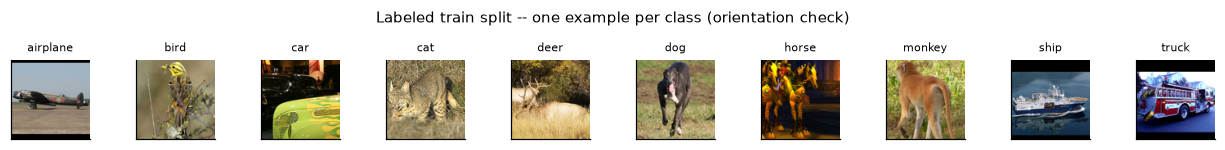

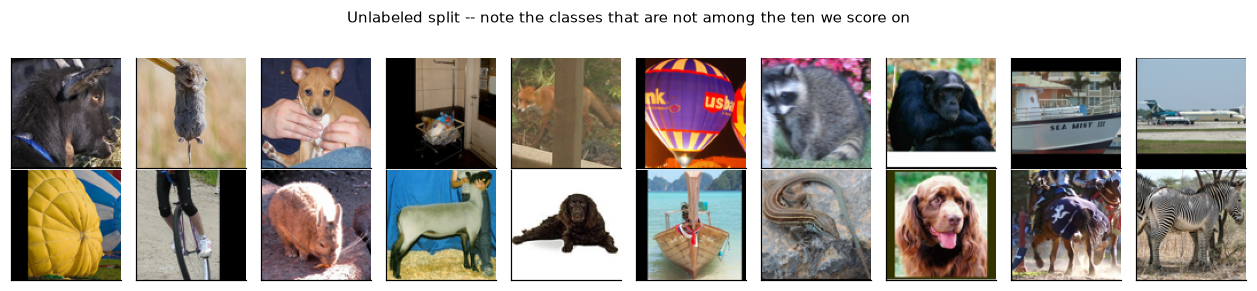

In [8]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Two fixed colours used consistently for the two arms throughout the notebook.
COLOR_CONTRASTIVE = "#2a78d6"
COLOR_GENERATIVE = "#eb6834"
COLOR_CNN = "#1baf7a"


def show_image_grid(images_uint8, titles=None, columns=8, title=None, save_as=None):
    """Display a strip of uint8 [N, 3, 96, 96] images."""
    count = len(images_uint8)
    rows = int(np.ceil(count / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(columns * 1.15, rows * 1.3))
    axes = np.atleast_1d(axes).reshape(-1)

    for position in range(rows * columns):
        axis = axes[position]
        axis.set_xticks([]); axis.set_yticks([]); axis.grid(False)
        if position < count:
            axis.imshow(np.asarray(images_uint8[position]).transpose(1, 2, 0))
            if titles is not None:
                axis.set_title(titles[position], fontsize=7.5)
        else:
            axis.axis("off")

    if title:
        figure.suptitle(title, fontsize=10, y=1.0)
    figure.tight_layout()
    if save_as:
        figure.savefig(FIGURES_ROOT / save_as, bbox_inches="tight")
    plt.show()


# Labeled images first: these should look like upright photographs of their captions. If
# they are transposed, the axis swap in load_images was dropped.
sample_positions = [np.flatnonzero(train_labels == c)[0] for c in range(NUM_CLASSES)]
show_image_grid(
    train_images[sample_positions],
    titles=[CLASS_NAMES[c] for c in range(NUM_CLASSES)],
    columns=10,
    title="Labeled train split -- one example per class (orientation check)",
    save_as="fig01_labeled_examples.png",
)

# And a sample of the unlabeled split, which is what the graph is actually built over.
unlabeled_sample = np.random.default_rng(SEED).choice(NUM_UNLABELED_IMAGES, 20, replace=False)
show_image_grid(
    np.asarray(unlabeled_images[np.sort(unlabeled_sample)]),
    columns=10,
    title="Unlabeled split -- note the classes that are not among the ten we score on",
    save_as="fig02_unlabeled_examples.png",
)

---

# 2. The shared SE-ResNet trunk

This is the single most important piece of the fairness argument. Both arms instantiate
**this exact class**. If the two arms used different backbones, the pretraining objective
would no longer be the only variable and the comparison would collapse into "which
architecture is better".

Three departures from a stock ResNet, all deliberate:

- **A two-convolution stem with no max-pool.** STL-10 at 96×96 is small enough that the
  usual 7×7-stride-2-plus-pool ImageNet stem would throw away too much resolution before
  any residual block runs.
- **Pre-activation blocks** (norm → activation → convolution), so the residual branch adds
  to an un-normalized signal and gradients reach early layers through a clean identity path.
- **Squeeze-and-excitation gates** on every block, reduction 16, with a floor of 16 hidden
  channels so the bottleneck does not collapse to 4 channels in the narrow early stages.

Spatial trace for a 96×96 input — the decoder in section 6 mirrors it exactly:

```
input                       96 x 96 x   3
stem conv1, stride 2   ->   48 x 48 x  48
stem conv2, stride 1   ->   48 x 48 x  64
stage 0 (depth 2)      ->   48 x 48 x  64     all strides 1
stage 1 (depth 3)      ->   24 x 24 x 128     first block stride 2
stage 2 (depth 4)      ->   12 x 12 x 256     first block stride 2
stage 3 (depth 3)      ->    6 x  6 x 384     first block stride 2
output projection 1x1  ->    6 x  6 x 512
global average pool    ->    1 x  1 x 512
flatten                ->   [B, 512]
```

The 512-d output is the embedding tap point for both arms.

In [9]:
FINAL_FEATURE_MAP_CHANNELS = STAGE_WIDTHS[-1]
FINAL_FEATURE_MAP_SIZE = 6


class SqueezeExcitation(nn.Module):
    """Channel-attention gate: pool to one value per channel, learn a rescale."""

    def __init__(self, channels, reduction=SE_REDUCTION):
        super().__init__()
        hidden_channels = max(channels // reduction, 16)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.scale = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.scale(self.pool(x))


class PreActivationSEBlock(nn.Module):
    """Pre-activation residual block with a squeeze-and-excitation gate."""

    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        self.norm1 = nn.BatchNorm2d(in_channels)
        self.activation1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.norm2 = nn.BatchNorm2d(out_channels)
        self.activation2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.se = SqueezeExcitation(out_channels)

        # A projection shortcut is only needed when the block changes the spatial size or
        # the channel count; otherwise the identity is used and there is no `downsample`
        # entry in the state dict at all.
        needs_projection = stride != 1 or in_channels != out_channels
        self.downsample = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
            if needs_projection else None
        )

    def forward(self, x):
        preactivated = self.activation1(self.norm1(x))

        # The projection shortcut consumes the pre-activated signal, not the raw input.
        # That is the textbook pre-activation formulation -- the shortcut convolution is
        # part of the block's first pre-activation -- but it reads like an oversight at a
        # glance, so it is called out here. The identity branch carries the raw input.
        shortcut = x if self.downsample is None else self.downsample(preactivated)

        residual = self.conv1(preactivated)
        residual = self.conv2(self.activation2(self.norm2(residual)))
        return shortcut + self.se(residual)


class SEResNetEncoder(nn.Module):
    """The shared trunk. [B, 3, 96, 96] -> [B, 512]."""

    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, STEM_WIDTH, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(STEM_WIDTH),
            nn.ReLU(inplace=True),
            nn.Conv2d(STEM_WIDTH, STAGE_WIDTHS[0], kernel_size=3, stride=1, padding=1,
                      bias=False),
        )
        # No normalization or activation after the second stem convolution: the first
        # PreActivationSEBlock opens with norm1/activation1, so adding them here would
        # apply them twice.

        stages = []
        in_channels = STAGE_WIDTHS[0]
        for stage_index, (depth, out_channels) in enumerate(zip(STAGE_DEPTHS, STAGE_WIDTHS)):
            blocks = []
            for block_index in range(depth):
                # Stage 0 keeps the stem's 48x48 resolution; every later stage halves it in
                # its first block only.
                stride = 2 if stage_index > 0 and block_index == 0 else 1
                blocks.append(PreActivationSEBlock(in_channels, out_channels, stride))
                in_channels = out_channels
            stages.append(nn.Sequential(*blocks))

        self.stages = nn.Sequential(*stages)
        # Because the blocks are pre-activation, the last block's output is un-normalized.
        # This trailing norm/ReLU pair is what makes the pooled embedding comparable across
        # images.
        self.final_norm = nn.BatchNorm2d(in_channels)
        self.final_activation = nn.ReLU(inplace=True)
        self.output_projection = nn.Conv2d(in_channels, ENCODER_DIM, kernel_size=1, bias=False)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        x = self.final_activation(self.final_norm(x))
        x = self.output_projection(x)
        return self.global_pool(x).flatten(1)


def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters())

### Weight initialization

Each layer gets the scheme its successor needs, and both arms use the identical rules:

- **SE reduce** convolution: Kaiming normal, `fan_in`. It is followed by a ReLU, and
  `fan_in` keeps the forward activation variance stable — which is what matters for a 1×1
  gate computed on pooled values.
- **SE expand** convolution and the **output projection**: Xavier uniform. Both feed
  something that is not a ReLU (a sigmoid gate and the global average pool respectively), so
  the Kaiming ReLU gain would be the wrong constant.
- **Every other convolution**: Kaiming normal, `fan_out`, the standard ResNet choice —
  `fan_out` preserves gradient variance on the backward pass through a deep residual stack.
- **BatchNorm**: weight 1, bias 0, so each layer starts as the identity transform.

Module identities are collected first because `model.modules()` yields the SE convolutions
interleaved with the ordinary ones and there is no way to tell them apart from the module
alone.

In [10]:
def initialize_encoder_weights(module_tree, output_projection=None,
                               projector_hidden=None, projector_output=None):
    """Apply the shared initialization scheme to a trunk (and optionally a projector)."""
    se_reduce_ids, se_expand_ids = set(), set()
    for module in module_tree.modules():
        if isinstance(module, SqueezeExcitation):
            se_reduce_ids.add(id(module.scale[0]))
            se_expand_ids.add(id(module.scale[2]))

    output_projection_id = id(output_projection) if output_projection is not None else None
    projector_hidden_id = id(projector_hidden) if projector_hidden is not None else None
    projector_output_id = id(projector_output) if projector_output is not None else None

    for module in module_tree.modules():
        module_id = id(module)

        if isinstance(module, nn.Conv2d):
            if module_id in se_reduce_ids:
                nn.init.kaiming_normal_(module.weight, mode="fan_in", nonlinearity="relu")
            elif module_id in se_expand_ids or module_id == output_projection_id:
                nn.init.xavier_uniform_(module.weight, gain=1.0)
            else:
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Linear):
            if module_id == projector_hidden_id:
                nn.init.kaiming_normal_(module.weight, mode="fan_in", nonlinearity="relu")
            elif module_id == projector_output_id:
                nn.init.xavier_uniform_(module.weight, gain=1.0)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)


reset_seed()
reference_encoder = SEResNetEncoder()
initialize_encoder_weights(reference_encoder,
                           output_projection=reference_encoder.output_projection)

with torch.no_grad():
    trace_input = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE)
    after_stem = reference_encoder.stem(trace_input)
    after_stages = reference_encoder.stages(after_stem)
    embedding = reference_encoder(trace_input)

print("trunk parameters :", format(parameter_count(reference_encoder), ","))
print()
print("shape trace")
print("  input          :", tuple(trace_input.shape))
print("  after stem     :", tuple(after_stem.shape))
print("  after stages   :", tuple(after_stages.shape),
      " <- the decoder in section 6 starts from this")
print("  embedding      :", tuple(embedding.shape))
print()
assert after_stages.shape[1] == FINAL_FEATURE_MAP_CHANNELS
assert after_stages.shape[2] == FINAL_FEATURE_MAP_SIZE
assert embedding.shape[1] == ENCODER_DIM
print("Both arms instantiate this class unchanged, so the trunk is identical by")
print("construction rather than by inspection.")

trunk parameters : 13,385,544

shape trace
  input          : (2, 3, 96, 96)
  after stem     : (2, 64, 48, 48)
  after stages   : (2, 384, 6, 6)  <- the decoder in section 6 starts from this
  embedding      : (2, 512)

Both arms instantiate this class unchanged, so the trunk is identical by
construction rather than by inspection.


---

# 3. Augmentation, written from scratch

`torchvision.transforms` is banned, so every operation both arms need is written out here
in plain PyTorch. This turned out to be worth more than a box-ticking exercise: because both
arms now call the *same* primitives, the difference between their policies is purely a
difference of policy, not of implementation. Section 14 checks each operation against
torchvision on a fixed tensor.

Everything is **batched and runs on the GPU**. The 100k unlabeled images live resident in
VRAM as uint8 (2.76 GB) and there is no DataLoader at all: a per-image CPU transform
pipeline with worker processes would be the bottleneck when the data is already on the
device.

## Where the two arms legitimately differ

SimCLR *needs* aggressive views. Its loss is "pull two views of one image together, push
other images apart", so the two views have to be hard enough to make that non-trivial —
strip out the colour jitter and the encoder can satisfy the objective from colour
histograms alone.

A VAE has no second view and no such pressure. Its loss compares a reconstruction to a
target, so **every augmentation changes the target itself**. Heavy colour jitter makes the
target a different image; blur and grayscale destroy exactly the high-frequency and colour
detail the reconstruction term is scored on, so the model would be penalised for
information it was deliberately denied.

Forcing the two policies to match would not make the comparison fairer. It would handicap
one arm with a transform that only makes sense for the other. What *does* match, and must:
the trunk, the embedding width and tap point, the splits, the seed, the normalization
constants, the optimizer, and the 100-epoch budget.

In [11]:
GRAYSCALE_WEIGHTS = (0.2989, 0.5870, 0.1140)


def sample_uniform(shape, low, high, reference, generator=None):
    """Uniform draw in [low, high) on `reference`'s device.

    `torch.rand` refuses a CPU generator together with a CUDA device argument, so the draw
    is made on the generator's own device and moved. The tensors are one float per image, so
    the transfer is negligible -- and it means a run is reproducible from a single CPU seed
    regardless of which device it trains on.
    """
    if generator is None:
        values = torch.rand(shape, device=reference.device, dtype=torch.float32)
    else:
        values = torch.rand(shape, generator=generator, device=generator.device,
                            dtype=torch.float32).to(reference.device)
    return low + (high - low) * values


def _per_image(values):
    """Reshape a [B] factor tensor for broadcasting against [B, C, H, W]."""
    return values.view(-1, 1, 1, 1)


def random_horizontal_flip(batch, probability, generator=None):
    """Flip each image left-right independently with the given probability.

    Fully vectorized: the whole batch is flipped once and `torch.where` picks per image.
    That costs one extra buffer but avoids a loop of per-image kernel launches.

    Dimension 3 is W in [B, C, H, W]. Flipping H would turn images upside down, which is not
    a transformation STL-10 photographs are invariant to.
    """
    if probability <= 0.0:
        return batch
    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    should_flip = _per_image(draw < probability)
    return torch.where(should_flip, torch.flip(batch, dims=(3,)), batch)


def random_resized_crop(batch, output_size, scale, ratio, generator=None):
    """Per-image random crop of a random area and aspect, resized to `output_size`.

    `scale` is a (low, high) fraction of image *area*; `ratio` is a (low, high) width/height
    aspect. Aspect is drawn log-uniformly so squashing and stretching are equally likely --
    drawn uniformly, ratios above 1 would occupy more of the range than their reciprocals.

    The sampling is whole-batch tensor arithmetic. The resize itself falls back to a Python
    loop, because `interpolate` applies one output size to one input tensor and here every
    image has a different crop window. The vectorized alternative is a per-image affine grid
    plus `grid_sample`, which is not used because its sampling conventions differ subtly from
    `interpolate`'s and would make our crop quietly non-equivalent to the standard one
    everyone else's numbers come from. At batch 256 the loop is small next to a twelve-block
    forward and backward pass.
    """
    if not batch.is_floating_point():
        raise ValueError("random_resized_crop needs a float batch, got %r" % (batch.dtype,))

    batch_size, _, height, width = batch.shape
    image_area = float(height * width)

    target_area = sample_uniform((batch_size,), scale[0], scale[1], batch, generator) * image_area
    log_aspect = sample_uniform((batch_size,), math.log(ratio[0]), math.log(ratio[1]),
                                batch, generator)
    aspect = torch.exp(log_aspect)

    # area = w * h and aspect = w / h  =>  w = sqrt(area * aspect), h = sqrt(area / aspect).
    # torchvision retries the draw when the box does not fit and falls back to a centre crop
    # after ten attempts; we clamp instead. Clamping keeps the number of random draws fixed,
    # which matters for reproducibility -- a rejection loop makes the RNG stream depend on
    # the rejected samples.
    crop_width = torch.sqrt(target_area * aspect).round().long().clamp(1, width)
    crop_height = torch.sqrt(target_area / aspect).round().long().clamp(1, height)

    top_fraction = sample_uniform((batch_size,), 0.0, 1.0, batch, generator)
    left_fraction = sample_uniform((batch_size,), 0.0, 1.0, batch, generator)
    top = (top_fraction * (height - crop_height + 1).float()).long().clamp(min=0)
    left = (left_fraction * (width - crop_width + 1).float()).long().clamp(min=0)
    top = torch.minimum(top, height - crop_height)
    left = torch.minimum(left, width - crop_width)

    # One host transfer per box tensor, outside the loop: on CUDA every `.item()` is a
    # device synchronisation, so per-image ones would serialise the whole step.
    tops, lefts = top.tolist(), left.tolist()
    heights, widths = crop_height.tolist(), crop_width.tolist()

    crops = []
    for index in range(batch_size):
        window = batch[index:index + 1, :,
                       tops[index]:tops[index] + heights[index],
                       lefts[index]:lefts[index] + widths[index]]
        crops.append(F.interpolate(window, size=(output_size, output_size),
                                   mode="bilinear", align_corners=False, antialias=True))
    return torch.cat(crops, dim=0)

## 3.1 Colour operations

These four are the ones torchvision hides behind `ColorJitter`. All operate on images in
`[0, 1]`, before normalization — which is the order the reference pipeline uses, and the
opposite of the VAE path in 3.3.

The blending rule is torchvision's: `result = factor * image + (1 - factor) * reference`,
clamped back into `[0, 1]`.

- **Brightness** blends against black.
- **Contrast** blends against a flat image filled with the *mean of the greyscale version*
  of the input — not the mean of the raw channels.
- **Saturation** blends against the greyscale version itself.
- **Hue** is the expensive one: it requires a round trip through HSV, adding the shift to
  the hue channel modulo 1.

One documented deviation. torchvision draws a fresh random permutation of the four
operations for every image; we draw one permutation per batch. Applying a per-image order to
a batched implementation would mean four masked passes per operation, and the composition
is close to commutative for the small factors used here.

In [12]:
def rgb_to_grayscale(batch):
    """[B, 3, H, W] -> [B, 1, H, W] using the ITU-R 601-2 luma weights torchvision uses."""
    weights = torch.tensor(GRAYSCALE_WEIGHTS, dtype=batch.dtype,
                           device=batch.device).view(1, 3, 1, 1)
    return (batch * weights).sum(dim=1, keepdim=True)


def blend(image, reference, factor):
    """torchvision's blending rule, with per-image factors."""
    return (_per_image(factor) * image + (1.0 - _per_image(factor)) * reference).clamp(0.0, 1.0)


def adjust_brightness(batch, factor):
    return blend(batch, torch.zeros_like(batch), factor)


def adjust_contrast(batch, factor):
    # The mean of the GREYSCALE image, per image, not the per-channel mean.
    grey_mean = rgb_to_grayscale(batch).mean(dim=(1, 2, 3), keepdim=True)
    return blend(batch, grey_mean.expand_as(batch), factor)


def adjust_saturation(batch, factor):
    return blend(batch, rgb_to_grayscale(batch).expand_as(batch), factor)


def rgb_to_hsv(batch):
    """[B, 3, H, W] in [0, 1] -> (hue, saturation, value), each [B, 1, H, W]."""
    maximum, argmax = batch.max(dim=1, keepdim=True)
    minimum = batch.min(dim=1, keepdim=True).values
    chroma = maximum - minimum

    # Guarded division: a grey pixel has zero chroma, and hue is undefined there. The
    # substitute value is irrelevant because saturation is zero, but it must be finite or
    # the gradient-free forward pass still produces NaN that survives the round trip.
    safe_chroma = torch.where(chroma > 0, chroma, torch.ones_like(chroma))
    red, green, blue = batch[:, 0:1], batch[:, 1:2], batch[:, 2:3]

    hue_red = ((green - blue) / safe_chroma) % 6.0
    hue_green = ((blue - red) / safe_chroma) + 2.0
    hue_blue = ((red - green) / safe_chroma) + 4.0

    hue = torch.where(argmax == 0, hue_red, torch.where(argmax == 1, hue_green, hue_blue))
    hue = torch.where(chroma > 0, hue / 6.0, torch.zeros_like(hue))

    safe_maximum = torch.where(maximum > 0, maximum, torch.ones_like(maximum))
    saturation = torch.where(maximum > 0, chroma / safe_maximum, torch.zeros_like(maximum))
    return hue, saturation, maximum


def hsv_to_rgb(hue, saturation, value):
    """Inverse of `rgb_to_hsv`."""
    sector = (hue * 6.0).floor()
    offset = hue * 6.0 - sector

    p = value * (1.0 - saturation)
    q = value * (1.0 - saturation * offset)
    t = value * (1.0 - saturation * (1.0 - offset))

    sector = (sector % 6).to(torch.int64)
    # Rows are the six sectors of the hue circle; each names which of (v, t, p, q) supplies
    # R, G and B.
    red = torch.where(sector == 0, value, torch.where(sector == 1, q,
          torch.where(sector == 2, p, torch.where(sector == 3, p,
          torch.where(sector == 4, t, value)))))
    green = torch.where(sector == 0, t, torch.where(sector == 1, value,
            torch.where(sector == 2, value, torch.where(sector == 3, q,
            torch.where(sector == 4, p, p)))))
    blue = torch.where(sector == 0, p, torch.where(sector == 1, p,
           torch.where(sector == 2, t, torch.where(sector == 3, value,
           torch.where(sector == 4, value, q)))))
    return torch.cat([red, green, blue], dim=1).clamp(0.0, 1.0)


def adjust_hue(batch, shift):
    """Rotate the hue channel by `shift` (a [B] tensor in [-0.5, 0.5])."""
    hue, saturation, value = rgb_to_hsv(batch)
    return hsv_to_rgb((hue + _per_image(shift)) % 1.0, saturation, value)


def random_grayscale(batch, probability, generator=None):
    """Replace each image with its 3-channel greyscale version with the given probability."""
    if probability <= 0.0:
        return batch
    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    grey = rgb_to_grayscale(batch).expand_as(batch)
    return torch.where(_per_image(draw < probability), grey, batch)


def gaussian_blur(batch, kernel_size, sigma_range, probability, generator=None):
    """Per-image Gaussian blur, applied with the given probability.

    Separable: a 2-D Gaussian is the outer product of two 1-D Gaussians, so blurring rows
    then columns costs 2k multiply-adds per pixel instead of k^2. Images that were not
    selected are blurred too and then discarded by the `where` -- one wasted convolution is
    cheaper than the branch-and-gather needed to avoid it.

    Every image in the batch shares one sigma. torchvision draws sigma per call, which for a
    per-image pipeline means per image; here the draw is per batch, and with batch 256 over
    100 epochs the sigma distribution is sampled just as thoroughly.
    """
    if probability <= 0.0:
        return batch

    sigma = float(sample_uniform((1,), sigma_range[0], sigma_range[1], batch, generator).item())
    radius = kernel_size // 2
    positions = torch.arange(kernel_size, dtype=torch.float32, device=batch.device) - radius
    kernel = torch.exp(-(positions ** 2) / (2.0 * sigma * sigma))
    kernel = kernel / kernel.sum()

    channels = batch.shape[1]
    horizontal = kernel.view(1, 1, 1, kernel_size).expand(channels, 1, 1, kernel_size)
    vertical = kernel.view(1, 1, kernel_size, 1).expand(channels, 1, kernel_size, 1)

    # Reflect padding rather than zeros: zero padding would darken the border, which the
    # encoder can learn to detect and use as a shortcut.
    padded = F.pad(batch, (radius, radius, radius, radius), mode="reflect")
    blurred = F.conv2d(padded, horizontal, groups=channels)
    blurred = F.conv2d(blurred, vertical, groups=channels)

    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    return torch.where(_per_image(draw < probability), blurred, batch)


def color_jitter(batch, brightness, contrast, saturation, hue, probability, generator=None):
    """torchvision's ColorJitter wrapped in a RandomApply, batched.

    Factors are drawn per image; the order of the four operations is drawn per batch.
    """
    batch_size = batch.shape[0]
    apply_draw = sample_uniform((batch_size,), 0.0, 1.0, batch, generator)
    should_apply = _per_image(apply_draw < probability)

    jittered = batch
    factors = {
        "brightness": sample_uniform((batch_size,), 1 - brightness, 1 + brightness, batch, generator),
        "contrast": sample_uniform((batch_size,), 1 - contrast, 1 + contrast, batch, generator),
        "saturation": sample_uniform((batch_size,), 1 - saturation, 1 + saturation, batch, generator),
        "hue": sample_uniform((batch_size,), -hue, hue, batch, generator),
    }
    operations = {
        "brightness": adjust_brightness,
        "contrast": adjust_contrast,
        "saturation": adjust_saturation,
        "hue": adjust_hue,
    }

    names = list(operations)
    order = torch.randperm(4, generator=generator).tolist() if generator is not None \
        else torch.randperm(4).tolist()
    for position in order:
        name = names[position]
        jittered = operations[name](jittered, factors[name])

    return torch.where(should_apply, jittered, batch)

## 3.2 The four SimCLR policies

This is the ablation: each policy is a full 100-epoch pretrain, and the differences between
them isolate one operation at a time.

| policy | crop | flip | colour | grayscale | blur |
|---|:--:|:--:|:--:|:--:|:--:|
| `P1_crop_color` | ✓ | | ✓ | | |
| `P2_crop_color_blur` | ✓ | | ✓ | | ✓ |
| `P3_crop_flip_color` | ✓ | ✓ | ✓ | | |
| `P4_full_policy` | ✓ | ✓ | ✓ | ✓ | ✓ |

The two comparisons that matter: **P1 → P2** isolates blur, and **P3 → P4** adds grayscale
and blur together. Section 11 reads the ablation through those two contrasts rather than as
a four-way ranking.

Note the crop is far more aggressive than the VAE's — down to 20% of the image area, against
80% — and the aspect range is wider. That is the point of a contrastive view.

In [13]:
SIMCLR_CROP = {"output_size": IMAGE_SIZE, "scale": (0.20, 1.00), "ratio": (0.75, 4.0 / 3.0)}
SIMCLR_JITTER = {"brightness": 0.40, "contrast": 0.40, "saturation": 0.40, "hue": 0.10,
                 "probability": 0.80}
SIMCLR_BLUR = {"kernel_size": 9, "sigma_range": (0.10, 2.00), "probability": 0.50}
SIMCLR_GRAYSCALE_PROBABILITY = 0.20
SIMCLR_FLIP_PROBABILITY = 0.50

SIMCLR_POLICIES = {
    "P1_crop_color":      {"flip": False, "grayscale": False, "blur": False},
    "P2_crop_color_blur": {"flip": False, "grayscale": False, "blur": True},
    "P3_crop_flip_color": {"flip": True,  "grayscale": False, "blur": False},
    "P4_full_policy":     {"flip": True,  "grayscale": True,  "blur": True},
}


def simclr_view(images_uint8, policy_name, generator=None, device=None):
    """One augmented view: uint8 -> [0,1] -> crop/flip/jitter/grey/blur -> normalize.

    Colour operations run on [0, 1] images and normalization happens last, matching the
    reference pipeline. This is the opposite order to the VAE path in 3.3, where the crop's
    bilinear resampling is the only float-only step.
    """
    device = DEVICE if device is None else device
    policy = SIMCLR_POLICIES[policy_name]

    if isinstance(images_uint8, torch.Tensor):
        view = images_uint8.to(device=device, dtype=torch.float32) / 255.0
    else:
        view = torch.from_numpy(np.ascontiguousarray(images_uint8)).to(device).float() / 255.0

    view = random_resized_crop(view, SIMCLR_CROP["output_size"], SIMCLR_CROP["scale"],
                               SIMCLR_CROP["ratio"], generator)
    if policy["flip"]:
        view = random_horizontal_flip(view, SIMCLR_FLIP_PROBABILITY, generator)
    view = color_jitter(view, generator=generator, **SIMCLR_JITTER)
    if policy["grayscale"]:
        view = random_grayscale(view, SIMCLR_GRAYSCALE_PROBABILITY, generator)
    if policy["blur"]:
        view = gaussian_blur(view, generator=generator, **SIMCLR_BLUR)

    mean = torch.as_tensor(NORMALIZATION_MEAN, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    std = torch.as_tensor(NORMALIZATION_STD, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    return (view - mean) / std

## 3.3 The VAE policy

Flip plus a mild crop. Enough to stop the decoder memorising pixel positions, not enough to
change what the target *is*.

Two things about the ordering, both of which matter:

**Normalize first, augment second.** The crop resamples bilinearly and needs a float tensor
anyway, and normalizing after the crop would compute statistics over resampled pixels rather
than the fixed constants both arms share.

**The augmented view is also the reconstruction target.** The training loop feeds
`augment_vae_batch`'s output to the model *and* uses that same tensor as the target.
Reconstructing the un-augmented original from an augmented input would make this a
denoising autoencoder, which is a different objective from the ELBO.

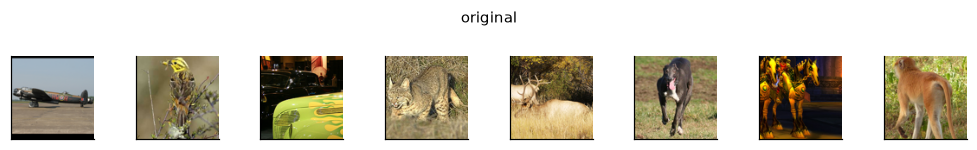

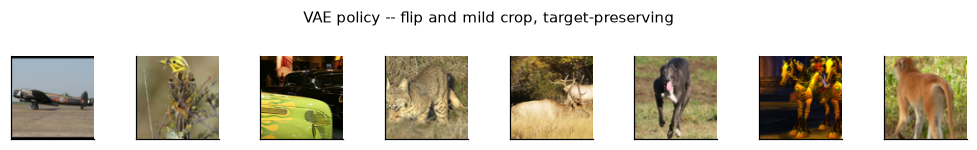

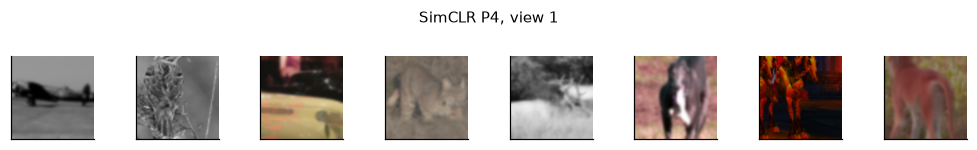

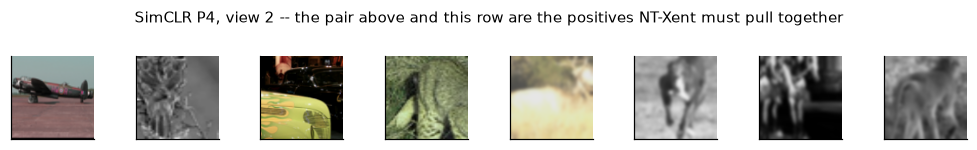

The contrastive views are hard on purpose. The generative views are not, because
for a VAE the view IS the reconstruction target.


In [14]:
VAE_AUGMENTATION = {
    "horizontal_flip_probability": 0.5,
    # At least 80% of the image area. SimCLR's lower bound is 0.20 -- an order of magnitude
    # more aggressive -- which routinely crops to a patch of background. As a reconstruction
    # target that is close to unlearnable.
    "crop_scale": (0.8, 1.0),
    "crop_ratio": (0.9, 1.1),
    "output_size": IMAGE_SIZE,
}


def augment_vae_batch(batch, generator=None):
    """Flip, then a mild random resized crop. Input must already be normalized."""
    augmented = random_horizontal_flip(
        batch, VAE_AUGMENTATION["horizontal_flip_probability"], generator)
    return random_resized_crop(augmented, VAE_AUGMENTATION["output_size"],
                               VAE_AUGMENTATION["crop_scale"],
                               VAE_AUGMENTATION["crop_ratio"], generator)


# --- what the two policies actually do to the same eight images ----------------
reset_seed()
demo_source = train_images[sample_positions[:8]]
demo_generator = seeded_generator(SEED)

vae_views = augment_vae_batch(normalize_batch(demo_source), demo_generator)
simclr_view_a = simclr_view(demo_source, "P4_full_policy", demo_generator)
simclr_view_b = simclr_view(demo_source, "P4_full_policy", demo_generator)

show_image_grid(np.asarray(demo_source), columns=8,
                title="original", save_as="fig03a_original.png")

show_image_grid((denormalize_for_display(vae_views).numpy() * 255).astype(np.uint8),
                columns=8, title="VAE policy -- flip and mild crop, target-preserving",
                save_as="fig03b_vae_policy.png")

show_image_grid((denormalize_for_display(simclr_view_a).numpy() * 255).astype(np.uint8),
                columns=8, title="SimCLR P4, view 1", save_as="fig03c_simclr_view1.png")

show_image_grid((denormalize_for_display(simclr_view_b).numpy() * 255).astype(np.uint8),
                columns=8, title="SimCLR P4, view 2 -- the pair above and this row are the "
                                 "positives NT-Xent must pull together",
                save_as="fig03d_simclr_view2.png")

print("The contrastive views are hard on purpose. The generative views are not, because")
print("for a VAE the view IS the reconstruction target.")

---

# 4. Optimizer and schedule

Identical for both arms, and for the downstream CNN in section 12. AdamW, linear warmup over
10 epochs, then cosine decay from 5e-4 to 1e-5.

Two details that are easy to get wrong and would break budget parity silently:

**Weight decay is applied only to multi-dimensional parameters.** The `ndim == 1` test
excludes every BatchNorm weight and bias and every convolution/linear bias in one pass.
Decaying a BatchNorm scale toward zero fights the normalization it is supposed to provide,
and decaying biases just adds noise — neither has the overfitting story that motivates
weight decay on a weight matrix.

**The schedule is evaluated per optimizer step, not per epoch.** With ~390 steps per epoch a
per-epoch schedule would hold the learning rate flat across each epoch and produce a visibly
different training curve.

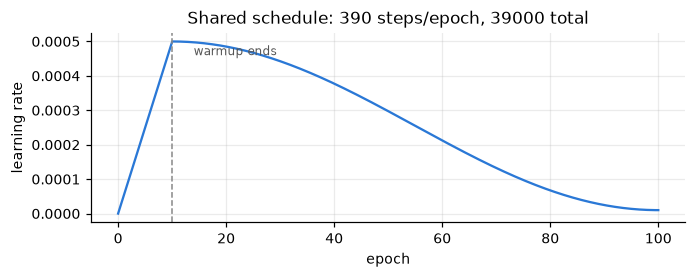

peak lr at step 3899, final lr 1.00e-05


In [15]:
def build_optimizer(model, weight_decay=WEIGHT_DECAY):
    """AdamW with weight decay on multi-dimensional parameters only.

    Initialized at lr = 0 on purpose: the schedule sets the learning rate explicitly before
    every step, so any value here would be overwritten and a nonzero one would mislead.
    """
    decay, no_decay = [], []
    for parameter in model.parameters():
        (no_decay if parameter.ndim == 1 else decay).append(parameter)

    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=0.0,
    )


def learning_rate_at_step(step, total_steps, warmup_steps,
                          max_lr=MAX_LEARNING_RATE, min_lr=MIN_LEARNING_RATE):
    """Linear warmup then cosine decay, per optimizer step."""
    if step < warmup_steps:
        # (step + 1) so the very first step already takes a nonzero step rather than a
        # wasted zero-length one, and warmup ends exactly at max_lr.
        return max_lr * ((step + 1) / warmup_steps)

    # The -1 makes the final step land exactly on min_lr; the max(..., 1) guards the
    # degenerate case where warmup covers the whole run.
    denominator = max(total_steps - warmup_steps - 1, 1)
    progress = min((step - warmup_steps) / denominator, 1.0)
    return min_lr + (max_lr - min_lr) * 0.5 * (1.0 + math.cos(math.pi * progress))


def set_learning_rate(optimizer, learning_rate):
    for group in optimizer.param_groups:
        group["lr"] = learning_rate


steps_per_epoch_demo = NUM_UNLABELED_IMAGES // BATCH_SIZE
total_steps_demo = steps_per_epoch_demo * EPOCHS
warmup_steps_demo = steps_per_epoch_demo * WARMUP_EPOCHS
schedule = [learning_rate_at_step(s, total_steps_demo, warmup_steps_demo)
            for s in range(total_steps_demo)]

figure, axis = plt.subplots(figsize=(6.4, 2.6))
axis.plot(np.arange(total_steps_demo) / steps_per_epoch_demo, schedule, color=COLOR_CONTRASTIVE)
axis.axvline(WARMUP_EPOCHS, color="#888", linestyle="--", linewidth=1)
axis.annotate("warmup ends", xy=(WARMUP_EPOCHS, MAX_LEARNING_RATE),
              xytext=(WARMUP_EPOCHS + 4, MAX_LEARNING_RATE * 0.92), fontsize=8, color="#555")
axis.set_xlabel("epoch"); axis.set_ylabel("learning rate")
axis.set_title("Shared schedule: %d steps/epoch, %d total" % (steps_per_epoch_demo, total_steps_demo))
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig04_lr_schedule.png", bbox_inches="tight")
plt.show()

print("peak lr at step %d, final lr %.2e" % (int(np.argmax(schedule)), schedule[-1]))

---

# 5. The contrastive arm

SimCLR takes two augmented views of the same image and asks the encoder to place them
closer together than either is to any view of any other image in the batch. There is no
decoder and no reconstruction — the only pressure is discrimination.

**The projection head is discarded after pretraining.** The contrastive loss is applied to
its 128-d output, but the embedding everything downstream uses is the encoder's 512-d pooled
feature. This is standard SimCLR practice and it is also what keeps the two arms comparable:
both tap a 512-d vector out of the same trunk.

## NT-Xent

For a batch of B images we build 2B views. Each view's positive is its twin; every other
view in the batch is a negative. With `projections` L2-normalized, the cosine similarity
matrix divided by the temperature gives the logits, and the loss is cross-entropy over each
row with the twin as the target class.

Two implementation details worth naming:

- The **self-similarity is masked to −∞** before the log-sum-exp. Every view is trivially
  most similar to itself, and leaving the diagonal in would let the model minimise the loss
  without learning anything.
- Views are interleaved as `[a0, b0, a1, b1, ...]`, so a view's twin is found by flipping the
  low bit of its index — `indices ^ 1`. That is why the stack-then-reshape happens before
  normalization rather than a plain concatenation.

Temperature 0.20 is low, which sharpens the distribution and puts most of the gradient on
the hardest negatives.

In [16]:
class ProjectionHead(nn.Module):
    """512 -> 512 -> 128 MLP. Used only during pretraining, then discarded."""

    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(ENCODER_DIM, PROJECTOR_HIDDEN_DIM, bias=False),
            nn.BatchNorm1d(PROJECTOR_HIDDEN_DIM),
            nn.ReLU(inplace=True),
            nn.Linear(PROJECTOR_HIDDEN_DIM, PROJECTOR_OUTPUT_DIM, bias=False),
        )

    def forward(self, x):
        return self.layers(x)


class SimCLRModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SEResNetEncoder()
        self.projection_head = ProjectionHead()
        initialize_encoder_weights(
            self,
            output_projection=self.encoder.output_projection,
            projector_hidden=self.projection_head.layers[0],
            projector_output=self.projection_head.layers[3],
        )

    def forward(self, x):
        return self.projection_head(self.encoder(x))


def nt_xent(z1, z2, temperature=TEMPERATURE):
    """Normalized temperature-scaled cross-entropy over 2B interleaved views."""
    batch_size = z1.shape[0]

    projections = torch.stack((z1, z2), dim=1).reshape(2 * batch_size, -1)
    projections = F.normalize(projections, p=2, dim=1)
    logits = (projections @ projections.T) / temperature

    number_of_views = 2 * batch_size
    indices = torch.arange(number_of_views, device=projections.device)
    positive_indices = indices ^ 1          # interleaved, so the twin is the low-bit flip

    self_mask = torch.eye(number_of_views, dtype=torch.bool, device=projections.device)
    logits_without_self = logits.masked_fill(self_mask, -torch.inf)

    positive_logits = logits[indices, positive_indices]
    return (-positive_logits + torch.logsumexp(logits_without_self, dim=1)).mean()


demo_model = SimCLRModel()
print("encoder parameters   :", format(parameter_count(demo_model.encoder), ","))
print("projector parameters :", format(parameter_count(demo_model.projection_head), ","))
print("total                :", format(parameter_count(demo_model), ","))
print()
print("A perfectly collapsed encoder -- every view mapped to the same point -- scores")
print("log(2B - 1) on this loss, which for batch %d is %.4f. That is the number to" % (
    BATCH_SIZE, math.log(2 * BATCH_SIZE - 1)))
print("watch the training curve against.")
del demo_model

encoder parameters   : 13,385,544
projector parameters : 328,704
total                : 13,714,248

A perfectly collapsed encoder -- every view mapped to the same point -- scores
log(2B - 1) on this loss, which for batch 256 is 6.2364. That is the number to
watch the training curve against.


In [17]:
def train_simclr(policy_name, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED,
                 log_every=10, images=None):
    """Pretrain one SimCLR encoder under one augmentation policy.

    Returns {"encoder_state", "history", "policy"}.

    The unlabeled images stay on the host as a memory-mapped uint8 array and each batch is
    uploaded as it is drawn. Holding all 2.76 GB resident in VRAM is possible on a 32 GB card
    and slightly faster, but it leaves much less headroom for the 2B-view similarity matrix,
    and the upload overlaps with computation anyway.
    """
    images = unlabeled_images if images is None else images
    reset_seed(seed)

    model = SimCLRModel().to(DEVICE)
    optimizer = build_optimizer(model)
    generator = seeded_generator(seed)

    number_of_images = len(images)
    steps_per_epoch = number_of_images // batch_size
    total_steps = steps_per_epoch * epochs
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS

    history = []
    global_step = 0
    started = time.time()

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(number_of_images, generator=generator).numpy()
        epoch_loss, epoch_batches = 0.0, 0

        for step in range(steps_per_epoch):
            # Dropping the ragged tail keeps every step the same batch size, which keeps the
            # number of negatives -- and therefore the loss scale -- uniform.
            positions = np.sort(permutation[step * batch_size:(step + 1) * batch_size])
            raw = np.asarray(images[positions])

            learning_rate = learning_rate_at_step(global_step, total_steps, warmup_steps)
            set_learning_rate(optimizer, learning_rate)

            view_one = simclr_view(raw, policy_name, generator)
            view_two = simclr_view(raw, policy_name, generator)

            loss = nt_xent(model(view_one), model(view_two))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            epoch_loss += float(loss.item())
            epoch_batches += 1
            global_step += 1

        record = {"epoch": epoch, "loss": epoch_loss / max(epoch_batches, 1),
                  "learning_rate": learning_rate,
                  "elapsed_seconds": time.time() - started}
        history.append(record)

        if epoch % log_every == 0 or epoch == epochs - 1:
            print("  %-18s epoch %3d/%d  loss %.4f  lr %.2e  %s"
                  % (policy_name, epoch + 1, epochs, record["loss"], learning_rate,
                     format_duration(record["elapsed_seconds"])))

    return {"encoder_state": {k: v.cpu() for k, v in model.encoder.state_dict().items()},
            "history": history, "policy": policy_name, "seed": seed}


SIMCLR_RUNS = {}
for policy_name in SIMCLR_POLICIES:
    SIMCLR_RUNS[policy_name] = cached(
        RUNS_ROOT / ("simclr_%s_seed%d.pt" % (policy_name, SEED)),
        lambda name=policy_name: train_simclr(name),
        "SimCLR pretrain, %s" % policy_name,
    )

print()
print("policy               final NT-Xent loss")
for policy_name, run in SIMCLR_RUNS.items():
    print("  %-20s %.4f" % (policy_name, run["history"][-1]["loss"]))

[building  ] SimCLR pretrain, P1_crop_color


  P1_crop_color      epoch   1/100  loss 4.5483  lr 5.00e-05  1m 11s


  P1_crop_color      epoch  11/100  loss 2.2399  lr 5.00e-04  12m 52s


  P1_crop_color      epoch  21/100  loss 2.0288  lr 4.82e-04  24m 32s


  P1_crop_color      epoch  31/100  loss 1.9445  lr 4.37e-04  36m 14s


...

  P4_full_policy     epoch  61/100  loss 2.0098  lr 2.04e-04  1h 13m


  P4_full_policy     epoch  71/100  loss 1.9853  lr 1.25e-04  1h 25m


  P4_full_policy     epoch  81/100  loss 1.9638  lr 6.19e-05  1h 37m


  P4_full_policy     epoch  91/100  loss 1.9532  lr 2.20e-05  1h 49m


  P4_full_policy     epoch 100/100  loss 1.9478  lr 1.00e-05  2h 00m
[done      ] SimCLR pretrain, P4_full_policy in 2h 00m

policy               final NT-Xent loss
  P1_crop_color        1.7787
  P2_crop_color_blur   1.8168
  P3_crop_flip_color   1.7884
  P4_full_policy       1.9478


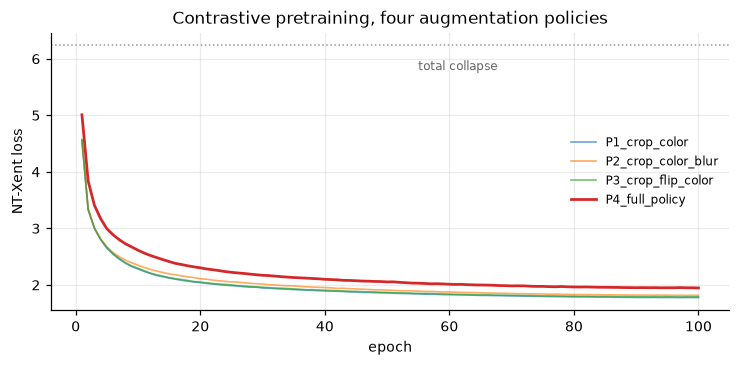

A lower contrastive loss does not by itself mean a better representation -- a weaker
augmentation policy makes the task easier, so its loss falls further while learning
less. Section 11 scores the policies on held-out accuracy instead.


In [18]:
figure, axis = plt.subplots(figsize=(6.8, 3.4))
for policy_name, run in SIMCLR_RUNS.items():
    losses = [record["loss"] for record in run["history"]]
    axis.plot(range(1, len(losses) + 1), losses, label=policy_name,
              linewidth=1.8 if policy_name == "P4_full_policy" else 1.1,
              alpha=1.0 if policy_name == "P4_full_policy" else 0.65)

axis.axhline(math.log(2 * BATCH_SIZE - 1), color="#999", linestyle=":", linewidth=1)
axis.annotate("total collapse", xy=(EPOCHS * 0.6, math.log(2 * BATCH_SIZE - 1)),
              xytext=(EPOCHS * 0.55, math.log(2 * BATCH_SIZE - 1) * 0.93),
              fontsize=8, color="#666")
axis.set_xlabel("epoch"); axis.set_ylabel("NT-Xent loss")
axis.set_title("Contrastive pretraining, four augmentation policies")
axis.legend(frameon=False, fontsize=8)
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig05_simclr_loss.png", bbox_inches="tight")
plt.show()

print("A lower contrastive loss does not by itself mean a better representation -- a weaker")
print("augmentation policy makes the task easier, so its loss falls further while learning")
print("less. Section 11 scores the policies on held-out accuracy instead.")

---

# 6. The generative arm

The same trunk, the same budget, the same optimizer — with an ELBO instead of NT-Xent.

```
x -> SEResNetEncoder -> 512-d -> to_mu     -> mu      (512-d)
                              -> to_logvar -> logvar  (512-d)
     mu, logvar -> reparameterize -> z -> Decoder -> reconstruction
```

## Downstream code uses `mu`, never a sample

Everything after pretraining — embeddings, the graph, propagation, the sweeps, the probe —
reads `mu` and only `mu`. `mu` is a deterministic function of the image, so the
105,000 × 512 embedding matrix and the graph built from it are identical every time they are
recomputed.

A sample `z = mu + sigma * epsilon` is not. Re-extracting with sampling on would perturb
every pairwise cosine similarity, reshuffle the top-K near each tie, change the edge set, and
change which labels propagate where. Accuracy would then wobble between runs for reasons
unrelated to the research question — and the β ablation, whose whole job is to attribute
changes in propagation accuracy to β, would be measuring noise instead.

`reparameterize` therefore returns `mu` unchanged in eval mode, so the correct behaviour is
the default for any code that remembered to call `.eval()`. Sampling is used during training
only, where it is what makes this a VAE rather than a plain autoencoder: the noise is what
forces nearby latents to decode to similar images, which is exactly the local smoothness
label propagation assumes.

## The decoder mirrors the encoder

Four doublings undo the encoder's total downsampling factor of 16 (a stride-2 stem plus three
stride-2 stages), landing back on 96×96.

**Nearest-neighbour upsample followed by a stride-1 convolution, not `ConvTranspose2d`.** A
transposed convolution with stride 2 covers output pixels an uneven number of times, and the
resulting periodic pattern is the familiar checkerboard artifact. For an image generator that
is a cosmetic complaint. Here it is a methodological one: the reconstruction gradient is the
*only* signal shaping the latent space, so if the decoder can lower its loss by emitting a
fixed high-frequency grid, the encoder is pushed to encode whatever helps that grid line up —
texture-like structure rather than object identity. The graph would then be built on exactly
those directions. Separating the resize (parameter-free) from the filtering (a stride-1
convolution, which touches every output pixel equally) removes the artifact by construction.

**The final convolution has no activation.** The target is a *normalized* image, roughly in
[−2.5, +2.5] with both signs. A sigmoid or tanh head would clip that range and make the
squared error unable to reach zero.

In [19]:
DECODER_STAGE_WIDTHS = (STAGE_WIDTHS[2], STAGE_WIDTHS[1], STAGE_WIDTHS[0], STEM_WIDTH)

# exp(logvar) is the variance, and an unconstrained head can emit +40 in the first few
# hundred steps while the encoder is still unscaled -- exp(40) is ~2.4e17, which makes the
# KL term inf. Clamping the logvar rather than the variance keeps the gradient finite
# instead of NaN. The range is wide enough to be inactive on a healthy run.
LOGVAR_MINIMUM, LOGVAR_MAXIMUM = -10.0, 10.0


class Decoder(nn.Module):
    """512-d latent -> [B, 3, 96, 96]."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.initial_channels = FINAL_FEATURE_MAP_CHANNELS
        self.initial_size = FINAL_FEATURE_MAP_SIZE

        # The only place the decoder can undo the encoder's global pool: the pooled vector
        # has no spatial extent, so the feature map has to be re-synthesised rather than
        # un-pooled.
        self.latent_projection = nn.Linear(
            latent_dim, self.initial_channels * self.initial_size ** 2)

        stages, in_channels = [], self.initial_channels
        for out_channels in DECODER_STAGE_WIDTHS:
            stages.append(nn.Sequential(
                nn.Upsample(scale_factor=2, mode="nearest"),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ))
            in_channels = out_channels
        self.stages = nn.Sequential(*stages)

        # Keeps its bias: with no BatchNorm after it, this is the only way the decoder can
        # represent a nonzero mean per channel.
        self.output_projection = nn.Conv2d(in_channels, 3, kernel_size=3, padding=1)

    def forward(self, z):
        x = self.latent_projection(z)
        x = x.view(-1, self.initial_channels, self.initial_size, self.initial_size)
        return self.output_projection(self.stages(x))


class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = SEResNetEncoder()
        initialize_encoder_weights(self.encoder,
                                   output_projection=self.encoder.output_projection)
        self.latent_dim = latent_dim
        self.to_mu = nn.Linear(ENCODER_DIM, latent_dim)
        self.to_logvar = nn.Linear(ENCODER_DIM, latent_dim)
        self.decoder = Decoder(latent_dim)

    def encode(self, x):
        features = self.encoder(x)
        return self.to_mu(features), self.to_logvar(features).clamp(LOGVAR_MINIMUM, LOGVAR_MAXIMUM)

    def reparameterize(self, mu, logvar):
        if not self.training:
            return mu               # determinism guarantee, see the section text
        standard_deviation = torch.exp(0.5 * logvar)
        return mu + standard_deviation * torch.randn_like(standard_deviation)

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decoder(self.reparameterize(mu, logvar)), mu, logvar


def vae_loss(reconstruction, target, mu, logvar, beta):
    """Beta-weighted negative ELBO. Returns (total, reconstruction, kl).

    The reconstruction term is the squared error SUMMED over the 3*96*96 pixels and averaged
    over the batch. Summing over pixels is what keeps the two terms on a comparable scale:
    the KL is a sum over 512 latent dimensions, so a per-pixel mean would be ~27,648x smaller
    and even beta = 0.001 would drown it. Averaging over the batch keeps the loss magnitude
    independent of batch size, so the inherited learning rate still means the same thing.

    The KL term is returned UNWEIGHTED -- the raw quantity in nats, not beta * kl. The
    posterior-collapse signal we must be able to see is the KL itself falling toward zero;
    logging beta * kl during warmup would confound "the KL is shrinking" with "beta is still
    ramping up", and collapse would hide inside the schedule.
    """
    reconstruction_term = ((reconstruction - target) ** 2).flatten(1).sum(dim=1).mean()
    kl_term = (-0.5 * (1.0 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)).mean()
    return reconstruction_term + beta * kl_term, reconstruction_term, kl_term


def beta_at_epoch(epoch, beta_max, warmup_epochs=BETA_WARMUP_EPOCHS):
    """Linear KL warmup: 0 at epoch 0, beta_max from `warmup_epochs` on.

    At the start of training the decoder is random and the reconstruction term gives only a
    weak, noisy gradient. The KL term, in contrast, has an immediately available minimum:
    drive every mu and logvar to zero, making the posterior exactly the prior. At full beta
    from step one that is the fastest loss reduction available and the model takes it -- the
    posterior collapses, mu becomes constant across images, every pairwise cosine similarity
    becomes ~1, and the graph degenerates before any useful representation has formed.
    """
    if warmup_epochs <= 0:
        return beta_max
    return beta_max * min(epoch / warmup_epochs, 1.0)

In [20]:
def train_vae(beta_max, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED,
              log_every=10, images=None):
    """Pretrain one VAE at a given beta. Returns {"encoder_state", "history", "beta"}."""
    images = unlabeled_images if images is None else images
    reset_seed(seed)

    model = VariationalAutoencoder().to(DEVICE)
    optimizer = build_optimizer(model)
    generator = seeded_generator(seed)

    number_of_images = len(images)
    steps_per_epoch = number_of_images // batch_size
    total_steps = steps_per_epoch * epochs
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS

    history = []
    global_step = 0
    started = time.time()

    for epoch in range(epochs):
        model.train()
        beta = beta_at_epoch(epoch, beta_max)
        permutation = torch.randperm(number_of_images, generator=generator).numpy()
        totals = {"loss": 0.0, "reconstruction": 0.0, "kl": 0.0}
        batches = 0

        for step in range(steps_per_epoch):
            positions = np.sort(permutation[step * batch_size:(step + 1) * batch_size])

            learning_rate = learning_rate_at_step(global_step, total_steps, warmup_steps)
            set_learning_rate(optimizer, learning_rate)

            # Normalize first, then augment -- and the augmented view is the target.
            target = augment_vae_batch(
                normalize_batch(np.asarray(images[positions])), generator)
            reconstruction, mu, logvar = model(target)
            loss, reconstruction_term, kl_term = vae_loss(reconstruction, target, mu, logvar, beta)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            totals["loss"] += float(loss.item())
            totals["reconstruction"] += float(reconstruction_term.item())
            totals["kl"] += float(kl_term.item())
            batches += 1
            global_step += 1

        record = {"epoch": epoch, "beta": beta,
                  "loss": totals["loss"] / max(batches, 1),
                  "reconstruction": totals["reconstruction"] / max(batches, 1),
                  "kl": totals["kl"] / max(batches, 1),
                  "learning_rate": learning_rate,
                  "elapsed_seconds": time.time() - started}
        history.append(record)

        if epoch % log_every == 0 or epoch == epochs - 1:
            print("  beta=%-6g epoch %3d/%d  recon %9.2f  KL %8.2f  beta_t %.4f  %s"
                  % (beta_max, epoch + 1, epochs, record["reconstruction"], record["kl"],
                     beta, format_duration(record["elapsed_seconds"])))

    return {"encoder_state": {k: v.cpu() for k, v in model.encoder.state_dict().items()},
            "head_state": {"to_mu": {k: v.cpu() for k, v in model.to_mu.state_dict().items()},
                           "to_logvar": {k: v.cpu() for k, v in model.to_logvar.state_dict().items()}},
            "history": history, "beta": beta_max, "seed": seed}


VAE_RUNS = {}
for beta_value in BETA_GRID:
    VAE_RUNS[beta_value] = cached(
        RUNS_ROOT / ("vae_beta%g_seed%d.pt" % (beta_value, SEED)),
        lambda b=beta_value: train_vae(b),
        "VAE pretrain, beta=%g" % beta_value,
    )

print()
print("  beta    final reconstruction    final KL (nats)")
for beta_value, run in VAE_RUNS.items():
    last = run["history"][-1]
    print("  %-7g %18.2f %17.2f" % (beta_value, last["reconstruction"], last["kl"]))

[building  ] VAE pretrain, beta=0


  beta=0      epoch   1/100  recon  20260.40  KL   134.31  beta_t 0.0000  51s


  beta=0      epoch  11/100  recon   3998.70  KL  2059.65  beta_t 0.0000  9m 23s


  beta=0      epoch  21/100  recon   3175.54  KL  2294.12  beta_t 0.0000  17m 55s


  beta=0      epoch  31/100  recon   2845.11  KL  2323.59  beta_t 0.0000  26m 27s


...

  beta=1      epoch  61/100  recon   3346.60  KL   348.48  beta_t 1.0000  52m 03s


  beta=1      epoch  71/100  recon   3244.36  KL   351.55  beta_t 1.0000  1h 00m


  beta=1      epoch  81/100  recon   3171.81  KL   354.50  beta_t 1.0000  1h 09m


  beta=1      epoch  91/100  recon   3135.69  KL   356.16  beta_t 1.0000  1h 17m


  beta=1      epoch 100/100  recon   3119.82  KL   356.79  beta_t 1.0000  1h 25m
[done      ] VAE pretrain, beta=1 in 1h 25m

  beta    final reconstruction    final KL (nats)
  0                  2164.75           2335.81
  0.001              2168.34           2335.36
  0.003              2166.65           2334.96
  0.01               2179.32           2302.56
  0.03               2207.58           1921.71
  0.1                2312.65           1365.27
  0.3                2591.82            716.32
  1                  3119.82            356.79


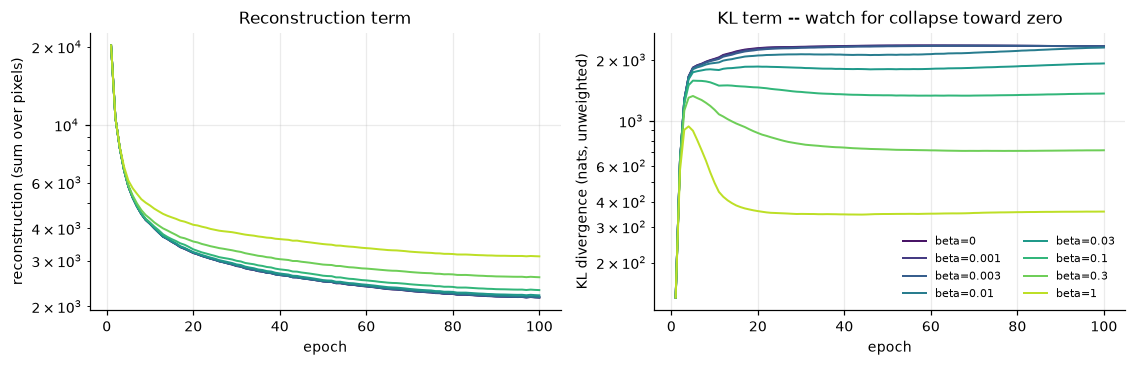

The KL panel is the diagnostic. A curve that dives toward zero and stays there is a
collapsed posterior: mu has stopped depending on the image, and the graph built from
it in section 8 would be meaningless. Compare the high-beta curves against the low ones.


In [21]:
figure, axes = plt.subplots(1, 2, figsize=(10.4, 3.4))
palette = plt.cm.viridis(np.linspace(0.05, 0.9, len(BETA_GRID)))

for color, (beta_value, run) in zip(palette, VAE_RUNS.items()):
    epochs_axis = [record["epoch"] + 1 for record in run["history"]]
    axes[0].plot(epochs_axis, [r["reconstruction"] for r in run["history"]],
                 color=color, label="beta=%g" % beta_value, linewidth=1.3)
    axes[1].plot(epochs_axis, [r["kl"] for r in run["history"]],
                 color=color, label="beta=%g" % beta_value, linewidth=1.3)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("reconstruction (sum over pixels)")
axes[0].set_title("Reconstruction term"); axes[0].set_yscale("log")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("KL divergence (nats, unweighted)")
axes[1].set_title("KL term -- watch for collapse toward zero"); axes[1].set_yscale("log")
axes[1].legend(frameon=False, fontsize=7.5, ncol=2)
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig06_vae_training.png", bbox_inches="tight")
plt.show()

print("The KL panel is the diagnostic. A curve that dives toward zero and stays there is a")
print("collapsed posterior: mu has stopped depending on the image, and the graph built from")
print("it in section 8 would be meaningless. Compare the high-beta curves against the low ones.")

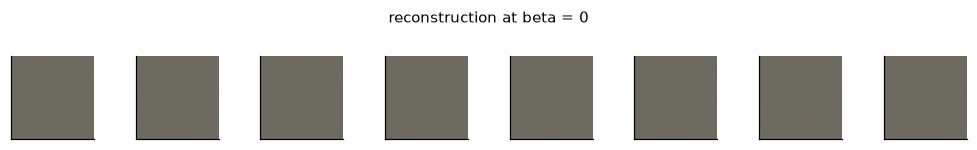

beta=0      mean per-dimension spread of mu across these 8 images: 0.3147


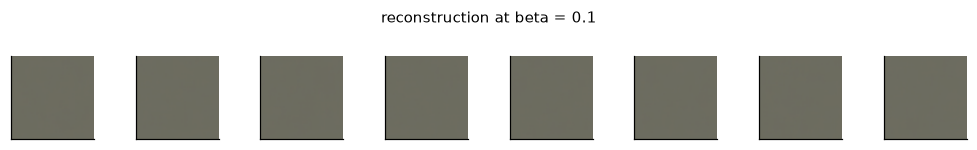

beta=0.1    mean per-dimension spread of mu across these 8 images: 0.6041


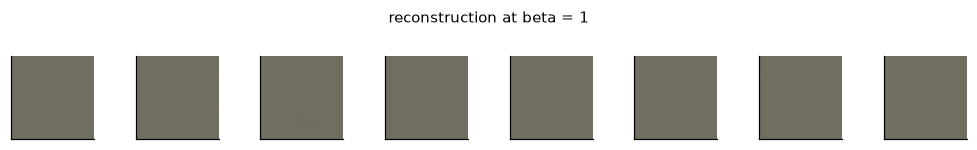

beta=1      mean per-dimension spread of mu across these 8 images: 0.3363


In [22]:
# What each beta actually reconstructs. A model whose posterior has collapsed produces the
# same blurred average for every input, which is visible here long before any accuracy
# number is computed.
reset_seed()
reconstruction_source = normalize_batch(train_images[sample_positions[:8]])

for beta_value in (BETA_GRID[0], 0.1, BETA_GRID[-1]):
    model = VariationalAutoencoder().to(DEVICE)
    model.encoder.load_state_dict(VAE_RUNS[beta_value]["encoder_state"])
    model.to_mu.load_state_dict(VAE_RUNS[beta_value]["head_state"]["to_mu"])
    model.to_logvar.load_state_dict(VAE_RUNS[beta_value]["head_state"]["to_logvar"])
    model.eval()
    with torch.inference_mode():
        reconstruction, mu, _ = model(reconstruction_source)
    show_image_grid((denormalize_for_display(reconstruction).numpy() * 255).astype(np.uint8),
                    columns=8, title="reconstruction at beta = %g" % beta_value,
                    save_as="fig07_reconstruction_beta%g.png" % beta_value)
    spread = mu.std(dim=0).mean().item()
    print("beta=%-6g mean per-dimension spread of mu across these 8 images: %.4f"
          % (beta_value, spread))
    del model

---

# 7. Frozen embeddings

Both arms are now frozen and every downstream stage reads a cached array instead of the
encoder. The graph spans the unlabeled split plus the labeled train split — 105,000 nodes —
so that every node a label could reach lives in one contiguous array with a fixed ordering:

```
index      0 .. 99,999    the 100,000 unlabeled images
index 100,000 .. 104,999  the 5,000 labeled train images
```

That layout is load-bearing. Section 9 seeds propagation at `NUM_UNLABELED_IMAGES + position`
for a labeled image at `position`, and the offset appears nowhere else.

Stored as fp16: 105,000 × 512 is about 107 MB per encoder, and there are nine encoders
(eight β values plus the selected SimCLR policy). The similarity search in section 8 casts
back to fp32, because fp16 accumulation over a 512-term dot product loses enough precision
to reorder near-ties in the top-K, which would silently change the graph between runs.

In [23]:
@torch.inference_mode()
def extract_embeddings(encoder_state, batch_size=FEATURE_BATCH_SIZE, head_state=None):
    """Encode the 105,000 graph nodes with a frozen trunk. Returns fp16 [105000, 512].

    `head_state` is the VAE's to_mu layer. When present, the returned embedding is `mu`;
    when absent, it is the pooled trunk feature, which is the contrastive arm's tap point.
    """
    encoder = SEResNetEncoder().to(DEVICE)
    encoder.load_state_dict(encoder_state)
    encoder.eval()

    projection = None
    if head_state is not None:
        projection = nn.Linear(ENCODER_DIM, LATENT_DIM).to(DEVICE)
        projection.load_state_dict(head_state)
        projection.eval()

    output = torch.empty(NUM_GRAPH_NODES, ENCODER_DIM, dtype=torch.float16)
    cursor = 0

    for source in (unlabeled_images, train_images):
        for start in range(0, len(source), batch_size):
            batch = normalize_batch(np.asarray(source[start:start + batch_size]))
            features = encoder(batch)
            if projection is not None:
                features = projection(features)
            output[cursor:cursor + features.shape[0]] = features.to(torch.float16).cpu()
            cursor += features.shape[0]

    assert cursor == NUM_GRAPH_NODES, "expected %d nodes, encoded %d" % (NUM_GRAPH_NODES, cursor)
    del encoder, projection
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return output


VAE_EMBEDDINGS = {}
for beta_value, run in VAE_RUNS.items():
    VAE_EMBEDDINGS[beta_value] = cached(
        RUNS_ROOT / ("embeddings_vae_beta%g_seed%d.pt" % (beta_value, SEED)),
        lambda r=run: extract_embeddings(r["encoder_state"], head_state=r["head_state"]["to_mu"]),
        "embeddings, VAE beta=%g" % beta_value,
    )

SIMCLR_EMBEDDINGS = {}
for policy_name, run in SIMCLR_RUNS.items():
    SIMCLR_EMBEDDINGS[policy_name] = cached(
        RUNS_ROOT / ("embeddings_simclr_%s_seed%d.pt" % (policy_name, SEED)),
        lambda r=run: extract_embeddings(r["encoder_state"]),
        "embeddings, SimCLR %s" % policy_name,
    )

reference_embedding = VAE_EMBEDDINGS[0.1]
print()
print("shape        :", tuple(reference_embedding.shape), reference_embedding.dtype)
print("size on disk : %.1f MB each, %d encoders cached"
      % (reference_embedding.numel() * 2 / 1e6, len(VAE_EMBEDDINGS) + len(SIMCLR_EMBEDDINGS)))
print("node layout  : 0..%d unlabeled, %d..%d labeled train"
      % (NUM_UNLABELED_IMAGES - 1, NUM_UNLABELED_IMAGES, NUM_GRAPH_NODES - 1))

[building  ] embeddings, VAE beta=0


[done      ] embeddings, VAE beta=0 in 12s
[building  ] embeddings, VAE beta=0.001


[done      ] embeddings, VAE beta=0.001 in 12s
[building  ] embeddings, VAE beta=0.003


[done      ] embeddings, VAE beta=0.003 in 12s
[building  ] embeddings, VAE beta=0.01


[done      ] embeddings, VAE beta=0.01 in 12s
[building  ] embeddings, VAE beta=0.03


...

[done      ] embeddings, VAE beta=1 in 12s
[building  ] embeddings, SimCLR P1_crop_color


[done      ] embeddings, SimCLR P1_crop_color in 12s
[building  ] embeddings, SimCLR P2_crop_color_blur


[done      ] embeddings, SimCLR P2_crop_color_blur in 12s
[building  ] embeddings, SimCLR P3_crop_flip_color


[done      ] embeddings, SimCLR P3_crop_flip_color in 12s
[building  ] embeddings, SimCLR P4_full_policy


[done      ] embeddings, SimCLR P4_full_policy in 12s

shape        : (105000, 512) torch.float16
size on disk : 107.5 MB each, 12 encoders cached
node layout  : 0..99999 unlabeled, 100000..104999 labeled train


---

# 8. The KNN graph

This is the memory-critical stage, and the one place where building from zero costs the most:
FAISS and every approximate-nearest-neighbour library are banned, so the search is an exact
brute-force cosine search written out in PyTorch.

## Why chunking is not optional

The full similarity matrix over N = 105,000 nodes is

```
105,000 x 105,000 x 4 bytes (fp32) = 44.1 GB
```

which fits in neither the card's 32 GB nor comfortably in host RAM. But we never need the
matrix — we need the top-K of each row. So it is computed one horizontal strip at a time and
the strip is discarded as soon as its top-K has been read off:

| | |
|---|---|
| one chunk, 1024 × 105,000 fp32 | ~430 MB, transient |
| embeddings, 105,000 × 512 fp32 | ~215 MB, resident |
| output indices, K = 50 | ~42 MB |
| output similarities, K = 50 | ~21 MB |
| **peak** | **under 1 GB** |

A 44 GB problem becomes a sub-1 GB one at the cost of 103 sequential matrix products instead
of one large one — the same total floating-point work either way.

**This is not an approximation.** Chunk *c* computes exactly rows *start..end* of the full
product, and nothing about a row's top-K depends on the other rows. Section 14 checks the
chunked result against a direct full-matrix `topk` on a small N.

In [24]:
DIVISION_EPSILON = 1e-12


def l2_normalize(embeddings, device=None):
    """Scale every row to unit norm, so a dot product IS the cosine similarity.

    Zero-norm rows are the failure mode to guard: a collapsed posterior can produce a mu of
    all zeros, and dividing by its norm would fill the matrix with NaN, which then poisons
    `topk` for every other row too. Clamping leaves such a row as an exact zero vector --
    similarity 0 to everything, which is meaningless but finite and debuggable.
    """
    device = DEVICE if device is None else device
    tensor = (embeddings.to(device=device, dtype=torch.float32) if isinstance(embeddings, torch.Tensor)
              else torch.as_tensor(embeddings, dtype=torch.float32, device=device)).contiguous()
    norms = torch.linalg.vector_norm(tensor, ord=2, dim=1, keepdim=True)
    return tensor / torch.clamp(norms, min=DIVISION_EPSILON)


def build_knn_graph(embeddings, k, chunk_rows=SIMILARITY_CHUNK_ROWS, device=None):
    """Exact cosine KNN, streamed one strip of rows at a time.

    Returns (indices int64 [N, K], similarities float32 [N, K]) sorted by decreasing
    similarity, on CPU.
    """
    device = DEVICE if device is None else device
    normalized = l2_normalize(embeddings, device)
    number_of_nodes = normalized.shape[0]

    if k > number_of_nodes - 1:
        raise ValueError("k must be <= N - 1 (a node is not its own neighbour)")

    neighbor_indices = torch.empty((number_of_nodes, k), dtype=torch.int64, device=device)
    neighbor_similarities = torch.empty((number_of_nodes, k), dtype=torch.float32, device=device)
    transposed = normalized.t()

    for chunk_start in range(0, number_of_nodes, chunk_rows):
        chunk_end = min(chunk_start + chunk_rows, number_of_nodes)
        similarity_chunk = normalized[chunk_start:chunk_end] @ transposed

        # Mask the diagonal: a node would otherwise always be its own nearest neighbour with
        # similarity exactly 1, leaving only K-1 real neighbours. -inf rather than -1,
        # because -1 is a legal cosine similarity.
        positions = torch.arange(chunk_end - chunk_start, device=device)
        similarity_chunk[positions, positions + chunk_start] = float("-inf")

        values, indices = torch.topk(similarity_chunk, k, dim=1, largest=True, sorted=True)
        neighbor_indices[chunk_start:chunk_end] = indices
        neighbor_similarities[chunk_start:chunk_end] = values

        # Free the strip before the next is allocated -- the point of the exercise. CUDA's
        # caching allocator hands the block straight to the identically-shaped next chunk,
        # so the loop reaches a steady state after the first iteration. Calling
        # empty_cache() here would defeat exactly that reuse.
        del similarity_chunk, values, indices

    return neighbor_indices.cpu(), neighbor_similarities.cpu()


def heat_kernel_weights(neighbor_similarities, sigma=None):
    """weight = exp((similarity - 1) / sigma), i.e. exp(-cosine_distance / sigma).

    Writing the exponent as `similarity - 1` rather than `-(1 - similarity)` keeps it <= 0
    by construction, so the exponential can only underflow toward 0, never overflow.

    Binary 0/1 edges would let the K-th neighbour -- which at K = 50 can be a completely
    unrelated image -- pull exactly as hard as the nearest one. The kernel makes the graph's
    confidence in an edge part of the propagation.

    With sigma=None the bandwidth self-tunes to the mean cosine distance to each node's
    furthest kept neighbour. Sigma has to be on the scale of the distances actually present,
    and that scale changes with beta, with the checkpoint, and with K itself -- a fixed sigma
    would mean something different in every cell of the sweep.
    """
    similarities = neighbor_similarities.to(torch.float32)
    if sigma is None:
        bandwidth = float((1.0 - similarities.min(dim=1).values).mean().item())
        bandwidth = max(bandwidth, DIVISION_EPSILON)
    else:
        bandwidth = float(sigma)
    return torch.exp((similarities - 1.0) / bandwidth), bandwidth


def symmetrize_union(neighbor_indices, weights, num_nodes):
    """W = max(W, W^T) as a sparse COO tensor.

    The raw KNN relation is directed. We take the UNION rather than the intersection
    (mutual-KNN): a hub node -- a prototypical image in the middle of its class cluster --
    appears in hundreds of other nodes' neighbour lists while its own K slots are filled by
    its immediate neighbours. Under intersection almost all those incoming edges vanish and
    the hub is nearly disconnected, which is exactly backwards; the hub is the node label
    mass should flow through. The price is a denser graph that can bridge two classes through
    one bad edge, which is what edge purity below measures.

    `max` rather than an average: the weight is a confidence, and if either endpoint
    considers the other close then the edge is that close, regardless of the other's crowded
    neighbourhood.

    `coalesce()` reduces duplicates by SUM and there is no max-reduce variant, so the
    max is done by hand: encode each (row, col) pair as one integer, sort by weight then
    stably by key, and keep the last entry of each run. Sorting rather than
    `scatter_reduce` because sort is deterministic on CUDA.
    """
    indices = neighbor_indices.to(torch.int64)
    edge_weights = weights.to(torch.float32)
    number_of_nodes, k = int(num_nodes), indices.shape[1]

    source = torch.arange(number_of_nodes).repeat_interleave(k)
    target = indices.reshape(-1)
    flat = edge_weights.reshape(-1)

    keep = source != target
    source, target, flat = source[keep], target[keep], flat[keep]

    all_rows = torch.cat([source, target])
    all_columns = torch.cat([target, source])
    all_weights = torch.cat([flat, flat])

    keys = all_rows * number_of_nodes + all_columns
    by_weight = torch.argsort(all_weights)
    keys, sorted_weights = keys[by_weight], all_weights[by_weight]
    by_key = torch.argsort(keys, stable=True)
    keys, sorted_weights = keys[by_key], sorted_weights[by_key]

    is_last = torch.ones_like(keys, dtype=torch.bool)
    is_last[:-1] = keys[1:] != keys[:-1]
    unique_keys, unique_weights = keys[is_last], sorted_weights[is_last]

    rows = unique_keys // number_of_nodes
    columns = unique_keys - rows * number_of_nodes
    return torch.sparse_coo_tensor(torch.stack([rows, columns]), unique_weights,
                                   (number_of_nodes, number_of_nodes)).coalesce()


def row_normalize(sparse_weight_matrix):
    """Row-normalize W into the transition matrix P, so every non-empty row sums to 1.

    Rows must sum to 1 for `F <- P F` to be an average rather than an arbitrary rescaling;
    with unnormalized rows, high-degree nodes would amplify their mass every iteration.

    An isolated node has no entries at all, so its row is all zeros and it keeps whatever it
    started with. A node whose weights all underflowed to zero would divide 0 by 0, so the
    reciprocal is taken only where the row sum is positive -- a NaN here would reach every
    node in the component within a couple of iterations.
    """
    coalesced = sparse_weight_matrix.coalesce()
    indices, values = coalesced.indices(), coalesced.values()
    number_of_nodes = coalesced.shape[0]
    if values.numel() == 0:
        return coalesced

    rows = indices[0]
    # float64 accumulation: a hub in the union graph can have thousands of incident edges
    # and we want "rows sum to 1" to hold to more digits than float32 would give.
    totals = torch.bincount(rows, weights=values.to(torch.float64), minlength=number_of_nodes)
    inverse = torch.where(totals > 0, 1.0 / torch.clamp(totals, min=DIVISION_EPSILON),
                          torch.zeros_like(totals))
    normalized = (values.to(torch.float64) * inverse[rows]).to(torch.float32)
    return torch.sparse_coo_tensor(indices, normalized, coalesced.shape).coalesce()


def build_propagation_matrix(embeddings, k, sigma=None, device=None):
    """Embeddings -> (P, neighbor_indices, neighbor_similarities, sigma).

    The raw neighbour arrays come back rather than being discarded: edge purity needs the
    directed [N, K] lists, and connected components needs them too. Neither can be recovered
    from P, and recomputing would mean a second 105k-node search per sweep cell.
    """
    indices, similarities = build_knn_graph(embeddings, k, device=device)
    weights, bandwidth = heat_kernel_weights(similarities, sigma)
    return (row_normalize(symmetrize_union(indices, weights, indices.shape[0])),
            indices, similarities, bandwidth)

## 8.1 Union-find and the graph diagnostics

`scipy.sparse.csgraph.connected_components` is the obvious call and it is banned, so the
disjoint-set forest is written out with both standard optimisations — path compression in
`find` and union by rank in `union` — which together keep it effectively linear.

Components matter because **label propagation cannot cross between them**. A node in a
component with no labeled seed is permanently unreachable no matter how many iterations run,
so the component structure is a hard ceiling on what propagation can achieve at a given K.

Alongside it, **edge purity**: the fraction of KNN edges joining two nodes of the same class.
This is a graph-quality measure that is completely independent of propagation — it asks "how
often does the embedding put a node next to something of its own class", which is the
property propagation actually consumes. A sweep judged on accuracy alone cannot separate a
bad graph from a bad propagation schedule.

In [25]:
class UnionFind:
    """Disjoint-set forest with path compression and union by rank."""

    def __init__(self, size):
        self.size = int(size)
        self.parent = list(range(self.size))
        self.rank = [0] * self.size
        self.number_of_components = self.size

    def find(self, x):
        # Iterative on purpose: N is 105k here and a long chain would exceed Python's
        # recursion limit before compression had a chance to flatten it.
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != root:
            self.parent[x], x = root, self.parent[x]
        return root

    def union(self, x, y):
        root_x, root_y = self.find(x), self.find(y)
        if root_x == root_y:
            return False
        if self.rank[root_x] < self.rank[root_y]:
            root_x, root_y = root_y, root_x
        self.parent[root_y] = root_x
        if self.rank[root_x] == self.rank[root_y]:
            self.rank[root_x] += 1
        self.number_of_components -= 1
        return True


def connected_components(neighbor_indices, num_nodes):
    """Components of the symmetrized graph. Returns (component_ids [N], count).

    Symmetrization is implicit: union(i, j) makes no distinction between the two directions,
    which is exactly the union rule the weights use.
    """
    neighbors = (neighbor_indices.cpu().numpy() if isinstance(neighbor_indices, torch.Tensor)
                 else np.asarray(neighbor_indices)).astype(np.int64, copy=False)
    number_of_nodes = int(num_nodes)
    disjoint_set = UnionFind(number_of_nodes)

    # .tolist() once up front: element-by-element numpy indexing inside a Python loop pays a
    # scalar-boxing cost on every access, and at ~5M edges that dominates the runtime.
    rows = neighbors.tolist()
    for node in range(number_of_nodes):
        for neighbor in rows[node]:
            if neighbor != node:
                disjoint_set.union(node, neighbor)

    roots = np.fromiter((disjoint_set.find(n) for n in range(number_of_nodes)),
                        dtype=np.int64, count=number_of_nodes)
    # Root ids are arbitrary node indices; remap to 0..M-1 so downstream bincounts do not
    # allocate an N-length histogram full of zeros.
    _, component_ids = np.unique(roots, return_inverse=True)
    return component_ids.astype(np.int64, copy=False), disjoint_set.number_of_components


def edge_purity(neighbor_indices, labels, valid_mask):
    """Fraction of edges joining two same-class nodes, among edges with both ends known.

    Counts the K directed arcs each node emits rather than the symmetrized edges. A mutual
    pair therefore contributes twice, which is fine for a ratio and keeps the number
    comparable across K without depending on how symmetrization was done.
    """
    neighbors = neighbor_indices.to(torch.int64)
    label_tensor = torch.as_tensor(labels, dtype=torch.int64).reshape(-1)
    known = torch.as_tensor(valid_mask, dtype=torch.bool).reshape(-1)

    source = torch.arange(neighbors.shape[0]).reshape(-1, 1).expand_as(neighbors)
    countable = known[source] & known[neighbors] & (source != neighbors)
    total = int(countable.sum().item())
    if total == 0:
        return 0.0
    same = (label_tensor[source] == label_tensor[neighbors]) & countable
    return float(int(same.sum().item()) / total)


def component_label_coverage(component_ids, labeled_mask):
    """Fraction of nodes in a component that holds at least one labeled seed."""
    components = torch.as_tensor(component_ids, dtype=torch.int64).reshape(-1)
    labeled = torch.as_tensor(labeled_mask, dtype=torch.bool).reshape(-1)
    number_of_components = int(components.max().item()) + 1
    labeled_per_component = torch.bincount(
        components, weights=labeled.to(torch.float64), minlength=number_of_components)
    return float(int((labeled_per_component > 0)[components].sum().item()) / components.numel())

In [26]:
# Graph structure at each K, on the beta = 0.1 embedding. This is a property of the graph
# alone -- no labels are propagated yet.
GRAPH_LABELS = np.concatenate([
    np.full(NUM_UNLABELED_IMAGES, -1, dtype=np.int64),   # unlabeled split has no class
    train_labels,
])
GRAPH_LABEL_KNOWN = GRAPH_LABELS >= 0


def _graph_structure_survey():
    rows = []
    for k in K_GRID:
        indices, similarities = build_knn_graph(reference_embedding, k)
        component_ids, component_count = connected_components(indices, NUM_GRAPH_NODES)
        sizes = np.bincount(component_ids)
        rows.append({
            "k": k,
            "components": component_count,
            "largest_component_fraction": float(sizes.max() / NUM_GRAPH_NODES),
            "singletons": int((sizes == 1).sum()),
            "edge_purity": edge_purity(indices, np.maximum(GRAPH_LABELS, 0), GRAPH_LABEL_KNOWN),
            "mean_similarity": float(similarities.mean().item()),
            "furthest_neighbour_similarity": float(similarities[:, -1].mean().item()),
        })
        print("  K=%-3d components %-7d largest %.4f  purity %.4f"
              % (k, component_count, rows[-1]["largest_component_fraction"],
                 rows[-1]["edge_purity"]))
    return rows


GRAPH_SURVEY = cached(RUNS_ROOT / "graph_survey_beta0.1.pt", _graph_structure_survey,
                      "graph structure survey")

print()
print("  K   components  largest comp.  singletons  edge purity")
for row in GRAPH_SURVEY:
    print("  %-3d %11d  %13.4f  %10d  %11.4f"
          % (row["k"], row["components"], row["largest_component_fraction"],
             row["singletons"], row["edge_purity"]))
print()
print("Edge purity falls monotonically with K -- larger neighbourhoods reach further and")
print("start bridging classes. If purity alone chose K, it would pick the smallest. Section")
print("11 shows accuracy disagrees, and why.")

[building  ] graph structure survey


  K=5   components 1       largest 1.0000  purity 0.6303


  K=10  components 1       largest 1.0000  purity 0.5683


  K=15  components 1       largest 1.0000  purity 0.5386


  K=20  components 1       largest 1.0000  purity 0.5111


  K=30  components 1       largest 1.0000  purity 0.4836


  K=50  components 1       largest 1.0000  purity 0.4517
[done      ] graph structure survey in 4s

  K   components  largest comp.  singletons  edge purity
  5             1         1.0000           0       0.6303
  10            1         1.0000           0       0.5683
  15            1         1.0000           0       0.5386
  20            1         1.0000           0       0.5111
  30            1         1.0000           0       0.4836
  50            1         1.0000           0       0.4517

Edge purity falls monotonically with K -- larger neighbourhoods reach further and
start bridging classes. If purity alone chose K, it would pick the smallest. Section
11 shows accuracy disagrees, and why.


---

# 9. Label propagation

The graph is built. Now we push 800 known labels across 105,000 nodes.

## The textbook method

Zhu–Ghahramani propagation is one line of linear algebra repeated until it stops moving:

$$F \leftarrow P F, \quad\text{then reset the labeled rows to their one-hot values}$$

**The re-clamp is the algorithm, not a tidying step.** `P` is row-stochastic, so iterating
`F ← PF` on its own is a random walk: the labeled rows are themselves averages of their
neighbours, so the seed labels immediately start diffusing *out* of the nodes we actually
know, and the iteration converges to the walk's stationary distribution — which depends only
on the graph's degree structure and not at all on the labels. Resetting the labeled rows
after every multiply turns those nodes into permanent sources rather than participants, and
it is that boundary condition that makes the fixed point the harmonic function we want.

Unlabeled rows start at **zero, not uniform**. Seeding them with 1/C would inject a constant
into the fixed point and flatten exactly the class contrast we are measuring — and it would
destroy our ability to detect nodes that never received any mass at all.

In [27]:
def one_hot_matrix(labels, num_classes, device, dtype=torch.float32):
    label_tensor = torch.as_tensor(labels, dtype=torch.int64, device=device).reshape(-1)
    if label_tensor.numel() and (label_tensor.min() < 0 or label_tensor.max() >= num_classes):
        raise ValueError("labels must lie in [0, %d) -- the -1 sentinel must not be seeded"
                         % num_classes)
    one_hot = torch.zeros(label_tensor.numel(), num_classes, dtype=dtype, device=device)
    if label_tensor.numel():
        one_hot.scatter_(1, label_tensor.reshape(-1, 1), 1.0)
    return one_hot


def initial_label_matrix(num_nodes, num_classes, labeled_indices, labeled_labels,
                         device, dtype=torch.float32):
    """F0: one-hot on labeled rows, all zeros elsewhere."""
    initial_F = torch.zeros(int(num_nodes), num_classes, dtype=dtype, device=device)
    index_tensor = torch.as_tensor(labeled_indices, dtype=torch.int64, device=device).reshape(-1)
    if index_tensor.numel():
        initial_F[index_tensor] = one_hot_matrix(labeled_labels, num_classes, device, dtype)
    return initial_F


def propagate(propagation_matrix, initial_F, labeled_indices, labeled_onehot,
              max_iterations=LP_MAX_ITERATIONS, tolerance=LP_TOLERANCE):
    """Hard-clamped Zhu-Ghahramani iteration. Returns (F, iterations, final_delta)."""
    device, dtype = propagation_matrix.device, propagation_matrix.dtype

    # The clone matters. `.to()` returns the SAME tensor when device and dtype already
    # match, so without it we would write straight into the caller's F0 -- and if
    # labeled_onehot is a view of it, the clamp becomes an index_put_ whose source and
    # destination overlap, which deterministic mode refuses outright.
    current_F = initial_F.to(device=device, dtype=dtype)
    if current_F is initial_F:
        current_F = current_F.clone()

    index_tensor = torch.as_tensor(labeled_indices, dtype=torch.int64, device=device).reshape(-1)
    clamp_target = labeled_onehot.to(device=device, dtype=dtype)
    if index_tensor.numel():
        current_F[index_tensor] = clamp_target

    iterations_run, final_delta = 0, float("inf")
    for _ in range(int(max_iterations)):
        next_F = (torch.sparse.mm(propagation_matrix, current_F) if propagation_matrix.is_sparse
                  else propagation_matrix @ current_F)
        # Re-clamp, then measure. Measuring first would report the movement of the seed rows
        # we are about to undo, and the convergence test would never fire.
        if index_tensor.numel():
            next_F[index_tensor] = clamp_target
        final_delta = float((next_F - current_F).abs().max().item())
        current_F = next_F
        iterations_run += 1
        if final_delta < tolerance:
            break

    return current_F, iterations_run, final_delta


def spread(propagation_matrix, initial_F, labeled_indices, labeled_onehot, alpha,
           max_iterations=LP_MAX_ITERATIONS, tolerance=LP_TOLERANCE):
    """Zhou label spreading: F <- alpha P F + (1 - alpha) Y. Soft clamp.

    No hard clamp here, deliberately. Zhou's formulation updates the seed rows like every
    other row and holds them near their one-hot value with the restart term rather than
    pinning them. That lets the method tolerate a mislabeled seed instead of propagating it
    with full confidence forever.

    `alpha P` has spectral radius alpha < 1, so this is a contraction and converges
    geometrically -- unconditionally, with no reliance on the graph's structure. The cost is
    that the iteration count scales as log(tolerance)/log(alpha): about 130 steps at
    alpha=0.9 but about 1375 at alpha=0.99, which is why LP_MAX_ITERATIONS is 3000.
    """
    if not 0.0 < float(alpha) < 1.0:
        raise ValueError("alpha must lie strictly in (0, 1); alpha=1 is `propagate`")

    device, dtype = propagation_matrix.device, propagation_matrix.dtype
    index_tensor = torch.as_tensor(labeled_indices, dtype=torch.int64, device=device).reshape(-1)
    clamp_target = labeled_onehot.to(device=device, dtype=dtype)

    # Y, built from the seeds rather than trusting F0 to be exactly the seed matrix, so a
    # caller who warm-starts from some other F0 still restarts toward the right thing.
    restart_F = torch.zeros_like(initial_F, device=device, dtype=dtype)
    if index_tensor.numel():
        restart_F[index_tensor] = clamp_target
    restart_term = (1.0 - float(alpha)) * restart_F

    current_F = initial_F.to(device=device, dtype=dtype)
    if current_F is initial_F:
        current_F = current_F.clone()

    iterations_run, final_delta = 0, float("inf")
    for _ in range(int(max_iterations)):
        next_F = (torch.sparse.mm(propagation_matrix, current_F) if propagation_matrix.is_sparse
                  else propagation_matrix @ current_F)
        next_F = float(alpha) * next_F + restart_term
        final_delta = float((next_F - current_F).abs().max().item())
        current_F = next_F
        iterations_run += 1
        if final_delta < tolerance:
            break

    return current_F, iterations_run, final_delta


def pseudo_labels_from(F, minimum_mass=0.0, epsilon=1e-12):
    """(pseudo_labels [N] int64, confidence [N] float).

    Confidence is the winning class's share of the row. It is not a calibrated probability
    and we do not claim it is -- it is a ranking signal for "how contested was this node".

    Nodes that received NO mass get label -1. F0 seeds only the labeled rows, so a node in a
    component with no seed keeps an exactly-zero row forever, and `argmax` on an all-zero row
    returns index 0 without complaint. Without this check every unreachable node would
    silently be pseudo-labeled "airplane", contaminating the CNN's training set with a bias
    that is invisible in the accuracy number.
    """
    row_mass = F.sum(dim=1)
    winning_mass, winning_class = F.max(dim=1)
    confidence = winning_mass / (row_mass + epsilon)
    unreachable = row_mass <= minimum_mass
    return (torch.where(unreachable, torch.full_like(winning_class, -1), winning_class),
            torch.where(unreachable, torch.zeros_like(confidence), confidence))

## 9.1 Hard clamping fails on this graph, and it is not a bug

Run the textbook iteration to convergence here and it lands barely above the 10% floor. The
iteration is correct — it reaches its fixed point to a maximum delta of order 1e-8. **The
fixed point itself is uninformative.**

The reason is structural. With 800 seeds among 105,000 nodes on a well-connected graph, the
random walk mixes long before it is absorbed, so the absorption probabilities stop depending
on where the walk started. Every row converges to very nearly the same vector, and the argmax
over it is close to meaningless.

The cell below measures three things at once: accuracy at the fixed point, the mean
winning-class share (against a uniform floor of 0.10), and — most usefully — accuracy
*along the way*.

[building  ] hard-clamp decay study


/tmp/ipykernel_1918386/4017981051.py:130: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(torch.stack([rows, columns]), unique_weights,


  iteration     1   dev accuracy 0.1350   mean confidence 0.9645
  iteration     2   dev accuracy 0.3100   mean confidence 0.6591
  iteration     4   dev accuracy 0.3650   mean confidence 0.4217
  iteration     8   dev accuracy 0.3750   mean confidence 0.3211
  iteration    16   dev accuracy 0.3800   mean confidence 0.2483
  iteration    32   dev accuracy 0.3550   mean confidence 0.1969
  iteration    64   dev accuracy 0.3200   mean confidence 0.1674
  iteration   150   dev accuracy 0.2200   mean confidence 0.1545
  iteration   300   dev accuracy 0.2050   mean confidence 0.1513


  iteration  1000   dev accuracy 0.1950   mean confidence 0.1503
[done      ] hard-clamp decay study in 1s


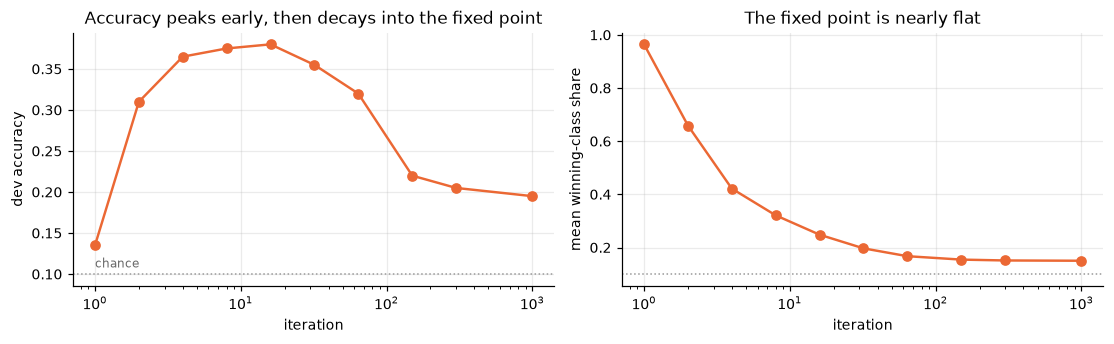


Peak dev accuracy 0.3800 at iteration 16; at the fixed point it is 0.1950.

This has a consequence that is easy to miss: an ITERATION CAP SILENTLY BECOMES A
HYPERPARAMETER. Stopping at 300 rather than at convergence does not just truncate the
run, it changes which K looks best -- small K diffuses more slowly and so lands less
far down this curve. Any K chosen under a cap is an artifact of the cap.


In [28]:
def fold_seed_indices(fold_index):
    """Graph node indices and labels for one fold's 800 development-train images."""
    train_positions, validation_positions = DEVELOPMENT_SPLITS[fold_index]
    fold_members = OFFICIAL_FOLDS[fold_index]

    seed_nodes = NUM_UNLABELED_IMAGES + fold_members[train_positions]
    seed_labels = train_labels[fold_members[train_positions]]
    validation_nodes = NUM_UNLABELED_IMAGES + fold_members[validation_positions]
    validation_labels = train_labels[fold_members[validation_positions]]
    return seed_nodes, seed_labels, validation_nodes, validation_labels


def _clamp_decay_study(k=15, fold_index=0, checkpoints=(1, 2, 4, 8, 16, 32, 64, 150, 300, 1000)):
    """Accuracy of hard-clamped propagation as a function of iteration count."""
    propagation_matrix, indices, _, _ = build_propagation_matrix(reference_embedding, k)
    propagation_matrix = propagation_matrix.to(DEVICE)

    seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)
    initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes, seed_labels, DEVICE)
    clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)

    validation_index = torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)
    truth = torch.as_tensor(validation_labels, dtype=torch.int64, device=DEVICE)

    current_F = initial_F.clone()
    current_F[torch.as_tensor(seed_nodes, dtype=torch.int64, device=DEVICE)] = clamp_target
    seed_index = torch.as_tensor(seed_nodes, dtype=torch.int64, device=DEVICE)

    trace = []
    for iteration in range(1, max(checkpoints) + 1):
        current_F = torch.sparse.mm(propagation_matrix, current_F)
        current_F[seed_index] = clamp_target
        if iteration in checkpoints:
            predictions = current_F[validation_index].argmax(dim=1)
            row_mass = current_F.sum(dim=1)
            confidence = (current_F.max(dim=1).values / (row_mass + 1e-12))
            trace.append({
                "iteration": iteration,
                "accuracy": float((predictions == truth).double().mean().item()),
                "mean_confidence": float(confidence[row_mass > 0].mean().item()),
            })
            print("  iteration %5d   dev accuracy %.4f   mean confidence %.4f"
                  % (iteration, trace[-1]["accuracy"], trace[-1]["mean_confidence"]))
    return trace


CLAMP_DECAY = cached(RUNS_ROOT / "clamp_decay_study.pt", _clamp_decay_study,
                     "hard-clamp decay study")

figure, axes = plt.subplots(1, 2, figsize=(10.2, 3.2))
iterations = [row["iteration"] for row in CLAMP_DECAY]

axes[0].plot(iterations, [r["accuracy"] for r in CLAMP_DECAY], "o-",
             color=COLOR_GENERATIVE, linewidth=1.6)
axes[0].axhline(1.0 / NUM_CLASSES, color="#999", linestyle=":", linewidth=1)
axes[0].annotate("chance", xy=(iterations[0], 1.0 / NUM_CLASSES + 0.008), fontsize=8, color="#666")
axes[0].set_xscale("log"); axes[0].set_xlabel("iteration"); axes[0].set_ylabel("dev accuracy")
axes[0].set_title("Accuracy peaks early, then decays into the fixed point")

axes[1].plot(iterations, [r["mean_confidence"] for r in CLAMP_DECAY], "o-",
             color=COLOR_GENERATIVE, linewidth=1.6)
axes[1].axhline(1.0 / NUM_CLASSES, color="#999", linestyle=":", linewidth=1)
axes[1].set_xscale("log"); axes[1].set_xlabel("iteration")
axes[1].set_ylabel("mean winning-class share")
axes[1].set_title("The fixed point is nearly flat")

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig08_clamp_decay.png", bbox_inches="tight")
plt.show()

best = max(CLAMP_DECAY, key=lambda r: r["accuracy"])
print()
print("Peak dev accuracy %.4f at iteration %d; at the fixed point it is %.4f."
      % (best["accuracy"], best["iteration"], CLAMP_DECAY[-1]["accuracy"]))
print()
print("This has a consequence that is easy to miss: an ITERATION CAP SILENTLY BECOMES A")
print("HYPERPARAMETER. Stopping at 300 rather than at convergence does not just truncate the")
print("run, it changes which K looks best -- small K diffuses more slowly and so lands less")
print("far down this curve. Any K chosen under a cap is an artifact of the cap.")

## 9.2 The fix: a restart term

Label spreading adds a $(1-\alpha)Y$ term that re-injects the seed matrix at every step, so a
walk that wanders too far keeps being pulled back to where it started. Its fixed point is

$$F^* = (1-\alpha)(I - \alpha P)^{-1} Y$$

the discounted random-walk-with-restart score, which stays local and stays informative.
Setting $\alpha = 1$ recovers the degenerate flat solution, so $\alpha$ is exactly the knob
that trades locality against reach.

The comparison below adds a third row that keeps everyone honest: **a plain cosine 20-nearest-neighbour
vote against the 800 seeds, with no graph at all.** If the graph machinery cannot beat that,
it is not earning its complexity.

In [29]:
def knn_vote_baseline(embeddings, fold_index, k=20):
    """No graph: classify each validation node by a cosine vote among the 800 seeds."""
    seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)
    normalized = l2_normalize(embeddings)

    seed_matrix = normalized[torch.as_tensor(seed_nodes, dtype=torch.int64, device=DEVICE)]
    query = normalized[torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)]

    similarity = query @ seed_matrix.T
    # Never ask for more neighbours than there are seeds. With 800 seeds per fold this is
    # inactive; it matters only if the function is ever called on a smaller seed set.
    _, nearest = torch.topk(similarity, min(k, seed_matrix.shape[0]), dim=1)
    neighbour_labels = torch.as_tensor(seed_labels, dtype=torch.int64, device=DEVICE)[nearest]

    votes = torch.zeros(len(validation_nodes), NUM_CLASSES, device=DEVICE)
    votes.scatter_add_(1, neighbour_labels, torch.ones_like(neighbour_labels, dtype=votes.dtype))
    predictions = votes.argmax(dim=1).cpu().numpy()
    return float((predictions == validation_labels).mean())


def _method_comparison(k=15, alpha=0.90):
    propagation_matrix, _, _, _ = build_propagation_matrix(reference_embedding, k)
    propagation_matrix = propagation_matrix.to(DEVICE)
    rows = {"clamp": [], "spread": [], "knn_vote": []}
    iteration_counts = {"clamp": [], "spread": []}
    confidences = {"clamp": [], "spread": []}

    for fold_index in range(NUM_FOLDS):
        seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)
        initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                         seed_labels, DEVICE)
        clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)
        validation_index = torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)

        for name, function, kwargs in (
            ("clamp", propagate, {}),
            ("spread", spread, {"alpha": alpha}),
        ):
            F_final, iterations, _ = function(propagation_matrix, initial_F, seed_nodes,
                                              clamp_target, **kwargs)
            predictions = F_final[validation_index].argmax(dim=1).cpu().numpy()
            rows[name].append(float((predictions == validation_labels).mean()))
            iteration_counts[name].append(iterations)
            row_mass = F_final.sum(dim=1)
            confidences[name].append(float(
                (F_final.max(dim=1).values / (row_mass + 1e-12))[row_mass > 0].mean().item()))

        rows["knn_vote"].append(knn_vote_baseline(reference_embedding, fold_index))

    return {"accuracy": rows, "iterations": iteration_counts, "confidence": confidences}


METHOD_COMPARISON = cached(RUNS_ROOT / "method_comparison.pt", _method_comparison,
                           "clamp vs spread vs no-graph baseline")

print("method                      dev accuracy      mean confidence   iterations")
for name, label in (("clamp", "hard clamp"), ("spread", "label spreading, alpha=0.9"),
                    ("knn_vote", "no graph: cosine 20-NN vote")):
    accuracies = np.array(METHOD_COMPARISON["accuracy"][name])
    if name in METHOD_COMPARISON["iterations"]:
        iteration_text = "%d-%d" % (min(METHOD_COMPARISON["iterations"][name]),
                                    max(METHOD_COMPARISON["iterations"][name]))
        confidence_text = "%.3f" % np.mean(METHOD_COMPARISON["confidence"][name])
    else:
        iteration_text, confidence_text = "--", "--"
    print("  %-27s %.4f +/- %.4f   %-15s %s"
          % (label, accuracies.mean(), accuracies.std(ddof=1), confidence_text, iteration_text))

print()
print("Hard clamping performs WORSE than doing nothing clever at all. Everything from here")
print("on uses label spreading; the hard-clamped sweep is kept in section 11 as the")
print("negative result it is.")

[building  ] clamp vs spread vs no-graph baseline


[done      ] clamp vs spread vs no-graph baseline in 3s
method                      dev accuracy      mean confidence   iterations
  hard clamp                  0.2190 +/- 0.0233   0.151           966-998
  label spreading, alpha=0.9  0.4005 +/- 0.0421   0.266           30-40
  no graph: cosine 20-NN vote 0.3790 +/- 0.0291   --              --

Hard clamping performs WORSE than doing nothing clever at all. Everything from here
on uses label spreading; the hard-clamped sweep is kept in section 11 as the
negative result it is.


---

# 10. Metrics and the linear probe

## Every metric comes from one confusion matrix

`sklearn.metrics` is banned, and it turns out not to be missed: accuracy, precision, recall
and F1 are not four algorithms, they are four ways of reading the same $C \times C$ table of
counts. A pair (true, predicted) is uniquely encoded by the integer
`true * C + predicted`, and counting how often each occurs is exactly what `torch.bincount`
does.

Two of sklearn's conventions are copied deliberately, because they change the number:
`zero_division=0` (a class that is never predicted contributes 0 to the macro average rather
than NaN), and the clip-then-renormalize inside `log_loss` (without it, a single
over-confident wrong prediction makes the whole mean infinite).

In [30]:
def confusion_matrix(true_labels, predicted_labels, num_classes=NUM_CLASSES):
    """Rows = true, columns = predicted. The one primitive every other metric reads."""
    true_tensor = torch.as_tensor(np.asarray(true_labels), dtype=torch.int64).reshape(-1)
    predicted_tensor = torch.as_tensor(np.asarray(predicted_labels), dtype=torch.int64).reshape(-1)

    if true_tensor.numel() != predicted_tensor.numel():
        raise ValueError("label vectors disagree on length")
    if true_tensor.numel():
        smallest = int(min(true_tensor.min(), predicted_tensor.min()))
        largest = int(max(true_tensor.max(), predicted_tensor.max()))
        if smallest < 0 or largest >= num_classes:
            raise ValueError("labels must lie in [0, %d) -- the -1 sentinel must be filtered "
                             "out before scoring, not folded into class 0" % num_classes)

    flat = torch.bincount(true_tensor * num_classes + predicted_tensor,
                          minlength=num_classes * num_classes)
    return flat.reshape(num_classes, num_classes)


def accuracy_from(confusion):
    counts = confusion.to(torch.float64)
    total = counts.sum()
    return 0.0 if total.item() == 0 else float((torch.diagonal(counts).sum() / total).item())


def per_class_precision_recall_f1(confusion):
    counts = confusion.to(torch.float64)
    true_positives = torch.diagonal(counts)
    predicted_totals, actual_totals = counts.sum(dim=0), counts.sum(dim=1)

    precision = torch.where(predicted_totals > 0,
                            true_positives / torch.clamp(predicted_totals, min=1.0),
                            torch.zeros_like(true_positives))
    recall = torch.where(actual_totals > 0,
                         true_positives / torch.clamp(actual_totals, min=1.0),
                         torch.zeros_like(true_positives))
    denominator = precision + recall
    f1 = torch.where(denominator > 0,
                     2.0 * precision * recall / torch.clamp(denominator, min=1e-300),
                     torch.zeros_like(precision))
    return precision, recall, f1


def macro_f1(confusion):
    return float(per_class_precision_recall_f1(confusion)[2].mean().item())


def macro_precision(confusion):
    return float(per_class_precision_recall_f1(confusion)[0].mean().item())


def cross_entropy_loss(probabilities, labels):
    """Mean negative log-likelihood of the true class -- sklearn's log_loss."""
    probability_tensor = torch.as_tensor(np.asarray(probabilities), dtype=torch.float64)
    label_tensor = torch.as_tensor(np.asarray(labels), dtype=torch.int64).reshape(-1)
    if label_tensor.numel() == 0:
        return 0.0

    epsilon = float(np.finfo(np.float64).eps)
    clipped = torch.clamp(probability_tensor, min=epsilon, max=1.0 - epsilon)
    clipped = clipped / clipped.sum(dim=1, keepdim=True)
    true_class = clipped.gather(1, label_tensor.reshape(-1, 1)).reshape(-1)
    return float((-torch.log(true_class)).mean().item())


def sample_std(values):
    """Sample standard deviation, ddof = 1. Used for every +/- in this notebook."""
    array = np.asarray(values, dtype=np.float64)
    return float(array.std(ddof=1)) if array.size > 1 else float("nan")

## The probe replaces an entire sklearn pipeline

The reference downstream evaluation is

```python
Pipeline([("scaler", StandardScaler()),
          ("classifier", LogisticRegression(C=..., solver="lbfgs", max_iter=5000))])
```

fitted per fold, with an inner 5-split stratified search over `C ∈ {0.1, 1, 10, 100}`.

The point is **not** to have "a linear classifier". The point is to optimize the *same
objective with the same regularization convention*, because the headline claim is a
comparison between two embedding spaces. If our probe regularized differently, a gap between
the arms could just be a gap between two estimators.

So `fit_logistic_regression` minimizes

$$\tfrac{1}{2}\lVert W \rVert_F^2 \;+\; C \sum_i \text{cross-entropy}(x_i W + b,\, y_i)$$

which is sklearn's convention exactly. sklearn does not put a $\lambda$ in front of the
penalty; it fixes the penalty and scales the *data-fit* term by $C$, so $C$ is an **inverse**
regularization strength. A textbook implementation writing `mean_CE + lambda * ||W||²` would
give a completely different model for the same numeric "C".

Note the **sum**, not the mean, over samples: with a mean, the effective regularization would
silently depend on how many samples the fold happens to hold. The intercept is deliberately
outside the penalty — penalizing it would tie the decision threshold to the arbitrary
location of the origin.

Since this notebook uses the same probe on **both** arms, that whole class of concern
disappears: it is now literally the same estimator on both sides, not merely a matched
convention.

## And the same thing again, with scikit-learn

The build-from-zero constraint governs the *method* — the graph, the propagation, the trunk,
the metrics. A downstream linear classifier is not part of the method under study, so the
reference implementation is run too, on both arms, under the identical protocol.

This is strictly more informative than picking one. If the two implementations agree, the
conclusion demonstrably does not depend on whose logistic regression produced it, and the
comparison against the original SimCLR results is direct. If they disagree, that is a finding
about the probe rather than about the latent spaces, and it needs to be visible rather than
buried in a choice made in section 10.

In [31]:
class Standardizer:
    """Per-feature zero-mean unit-variance rescaling -- our StandardScaler.

    FIT ON TRAINING FEATURES ONLY. The mean and standard deviation are statistics of the
    data, so fitting them on held-out features leaks information about the evaluation set.
    A Pipeline enforces that mechanically; without one, the discipline is manual.

    Two conventions copied rather than chosen: population variance (ddof = 0), and a feature
    whose standard deviation is ~0 gets a scale of 1.0 rather than being divided by ~0.
    """

    def __init__(self, zero_variance_threshold=1e-12):
        self.mean = None
        self.standard_deviation = None
        self.zero_variance_threshold = zero_variance_threshold

    def fit(self, features):
        matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
        self.mean = matrix.mean(dim=0)
        self.standard_deviation = matrix.std(dim=0, unbiased=False)
        self.standard_deviation = torch.where(
            self.standard_deviation > self.zero_variance_threshold,
            self.standard_deviation, torch.ones_like(self.standard_deviation))
        return self

    def transform(self, features):
        if self.mean is None:
            raise RuntimeError("Standardizer.transform called before fit")
        matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
        return (matrix - self.mean.to(matrix.device)) / self.standard_deviation.to(matrix.device)


def fit_logistic_regression(features, labels, C, max_iterations=LINEAR_MAX_ITERATIONS,
                            num_classes=NUM_CLASSES, tolerance=LINEAR_TOLERANCE):
    """Multinomial logistic regression fitted with L-BFGS. Returns (W, b)."""
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    label_vector = torch.as_tensor(np.asarray(labels), dtype=torch.int64).reshape(-1)

    # Parameters start at zero, matching sklearn's w0, which also makes this fit
    # deterministic.
    weights = torch.zeros(matrix.shape[1], num_classes, dtype=torch.float64, requires_grad=True)
    bias = torch.zeros(num_classes, dtype=torch.float64, requires_grad=True)
    strength = float(C)

    optimizer = torch.optim.LBFGS(
        [weights, bias], lr=1.0, max_iter=max_iterations,
        # Our objective is C times sklearn's, so its gradient is C times larger. Scaling the
        # threshold is what makes tol = 1e-4 stop the solver at the same point.
        tolerance_grad=tolerance * strength,
        tolerance_change=1e-9, history_size=10, line_search_fn="strong_wolfe",
    )

    def objective():
        optimizer.zero_grad(set_to_none=True)
        logits = matrix @ weights + bias
        data_fit = F.cross_entropy(logits, label_vector, reduction="sum")
        loss = 0.5 * (weights * weights).sum() + strength * data_fit
        loss.backward()
        return loss

    # One step() runs the entire L-BFGS loop: torch's max_iter counts iterations *within* a
    # step, which is the direct analogue of sklearn's max_iter.
    optimizer.step(objective)
    return weights.detach(), bias.detach()


def predict_proba(features, W, b):
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    return torch.softmax(matrix @ W + b, dim=1)


def stratified_k_fold(labels, num_splits=CROSS_VALIDATION_SPLITS, seed=SEED):
    """Hand-rolled StratifiedKFold. Deals each class round-robin into the k splits.

    The rotation carried between classes spreads the remainders. Without it every class
    whose count is not divisible by k would dump its remainder on the first splits, and the
    bias would accumulate over all ten classes into visibly uneven split sizes.
    """
    label_array = np.asarray(labels).reshape(-1)
    generator = np.random.default_rng(seed)
    per_split = [[] for _ in range(num_splits)]
    rotation = 0

    for class_id in np.unique(label_array):
        shuffled = generator.permutation(np.flatnonzero(label_array == class_id))
        assignment = (np.arange(len(shuffled)) + rotation) % num_splits
        for split_index in range(num_splits):
            per_split[split_index].append(shuffled[assignment == split_index])
        rotation = (rotation + len(shuffled)) % num_splits

    all_positions = np.arange(label_array.shape[0], dtype=np.int64)
    splits = []
    for split_index in range(num_splits):
        validation = np.sort(np.concatenate(per_split[split_index])).astype(np.int64)
        held_out = np.zeros(label_array.shape[0], dtype=bool)
        held_out[validation] = True
        splits.append((all_positions[~held_out], validation))
    return splits


def cross_validate_c(features, labels, c_grid=LINEAR_C_GRID, num_splits=CROSS_VALIDATION_SPLITS,
                     seed=SEED):
    """Inner C search over the development-train features only.

    THE STANDARDIZER IS REFITTED INSIDE EVERY SPLIT, on that split's training rows only.
    This is the part a Pipeline does for free and a hand-rolled version gets wrong: fitting
    one standardizer on all 800 rows before splitting would let each validation split's mean
    and variance influence the model that scores it.
    """
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    label_vector = np.asarray(labels).reshape(-1)
    splits = stratified_k_fold(label_vector, num_splits, seed)

    rows = []
    for c_value in c_grid:
        accuracies, f1_scores, log_losses = [], [], []
        for train_positions, validation_positions in splits:
            standardizer = Standardizer().fit(matrix[train_positions])
            weights, bias = fit_logistic_regression(
                standardizer.transform(matrix[train_positions]),
                label_vector[train_positions], C=c_value)
            probabilities = predict_proba(
                standardizer.transform(matrix[validation_positions]), weights, bias)
            truth = label_vector[validation_positions]
            confusion = confusion_matrix(truth, probabilities.argmax(dim=1))
            accuracies.append(accuracy_from(confusion))
            f1_scores.append(macro_f1(confusion))
            log_losses.append(cross_entropy_loss(probabilities, truth))
        rows.append({"c": float(c_value), "log_loss_mean": float(np.mean(log_losses)),
                     "accuracy_mean": float(np.mean(accuracies)),
                     "f1_macro_mean": float(np.mean(f1_scores))})
    return rows


def select_best_c(rows):
    """Rank by log loss ASCENDING first, then accuracy, then macro-F1, then C.

    Log loss is the primary criterion, and that is not cosmetic. A large C is barely
    regularized, and such a model routinely wins on accuracy while being badly over-confident
    and losing on log loss. Ranking on accuracy first would systematically select a larger C.
    The final ascending-C tie-break keeps the more regularized of two models the data cannot
    tell apart.
    """
    if not rows:
        raise ValueError("cannot select a C from an empty result list")
    return float(min(rows, key=lambda r: (r["log_loss_mean"], -r["accuracy_mean"],
                                          -r["f1_macro_mean"], r["c"]))["c"])


try:
    from sklearn.linear_model import LogisticRegression as ReferenceLogisticRegression
    from sklearn.preprocessing import StandardScaler as ReferenceStandardScaler
    SKLEARN_PROBE_AVAILABLE = True
except ImportError:
    SKLEARN_PROBE_AVAILABLE = False


def fit_reference_probe(train_features, train_labels_, C):
    """scikit-learn's StandardScaler + LogisticRegression, the reference pipeline.

    Same C, same solver, same iteration cap as `fit_logistic_regression` above. Returns a
    callable mapping features to class probabilities, so both backends have one interface.
    """
    if not SKLEARN_PROBE_AVAILABLE:
        raise RuntimeError("scikit-learn is not installed")
    scaler = ReferenceStandardScaler().fit(train_features)
    model = ReferenceLogisticRegression(
        C=C, solver="lbfgs", max_iter=LINEAR_MAX_ITERATIONS).fit(
        scaler.transform(train_features), train_labels_)

    def predict(features):
        seen = np.asarray(model.predict_proba(scaler.transform(features)))
        # predict_proba returns one column per class present in the TRAINING data, ordered
        # by model.classes_. Every official fold holds all ten, so that is already 0..9 --
        # but relying on it would silently misalign the argmax if a class were ever absent,
        # and a misaligned argmax looks like a bad representation rather than a bug. Scatter
        # into the full class space instead.
        full = np.zeros((seen.shape[0], NUM_CLASSES), dtype=np.float64)
        full[:, model.classes_.astype(np.int64)] = seen
        return full

    return predict


def fit_hand_written_probe(train_features, train_labels_, C):
    """Our probe, wrapped in the same interface as `fit_reference_probe`."""
    standardizer = Standardizer().fit(train_features)
    weights, bias = fit_logistic_regression(
        standardizer.transform(train_features), train_labels_, C=C)
    return lambda features: predict_proba(
        standardizer.transform(features), weights, bias).numpy()


PROBE_BACKENDS = {"hand_written": fit_hand_written_probe}
if SKLEARN_PROBE_AVAILABLE:
    PROBE_BACKENDS["sklearn"] = fit_reference_probe
else:
    print("scikit-learn is not installed; only the hand-written probe will be reported.")


def select_best_c_across_folds(rows_per_fold):
    """One global C shared by all ten folds, not one per fold.

    Selecting per fold is a different and slightly more permissive protocol: it gives an arm
    ten chances to find a good regularization strength where the reference gets one. Every
    number compared across arms uses this function.
    """
    totals, order = {}, []
    for rows in rows_per_fold:
        for row in rows:
            c_value = float(row["c"])
            if c_value not in totals:
                totals[c_value] = {"log_loss_mean": [], "accuracy_mean": [], "f1_macro_mean": []}
                order.append(c_value)
            for key in totals[c_value]:
                totals[c_value][key].append(float(row[key]))

    aggregate = [{"c": c_value,
                  "log_loss_mean": float(np.mean(totals[c_value]["log_loss_mean"])),
                  "accuracy_mean": float(np.mean(totals[c_value]["accuracy_mean"])),
                  "f1_macro_mean": float(np.mean(totals[c_value]["f1_macro_mean"]))}
                 for c_value in order]
    return select_best_c(aggregate), aggregate

---

# 11. Selection

Everything below is scored on the **200 held-out development-validation images** of each
fold. The test split is not touched. At the end of this section the chosen values are written
to `results/selection.json` and hashed, and section 12 refuses to run without that file.

Four things get selected:

1. the **augmentation policy** for the contrastive arm,
2. **β** for the generative arm,
3. **K** and **α** for the graph and propagation,
4. one global **C** for the probe, shared by both arms.

In [32]:
def probe_development_accuracy(embeddings, fold_index, c_value=None):
    """Fit the probe on a fold's 800 and score its 200. Returns a metrics dict."""
    features = embeddings.to(torch.float32).numpy()
    seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)

    train_features = features[seed_nodes]
    validation_features = features[validation_nodes]

    if c_value is None:
        rows = cross_validate_c(train_features, seed_labels)
        c_value = select_best_c(rows)
    else:
        rows = None

    standardizer = Standardizer().fit(train_features)
    weights, bias = fit_logistic_regression(
        standardizer.transform(train_features), seed_labels, C=c_value)
    probabilities = predict_proba(standardizer.transform(validation_features), weights, bias)
    confusion = confusion_matrix(validation_labels, probabilities.argmax(dim=1))

    return {"accuracy": accuracy_from(confusion), "f1_macro": macro_f1(confusion),
            "log_loss": cross_entropy_loss(probabilities, validation_labels),
            "c": float(c_value), "cv_rows": rows}


def _policy_ablation():
    """Score all four SimCLR policies on development data."""
    results = {}
    for policy_name, embeddings in SIMCLR_EMBEDDINGS.items():
        per_fold = [probe_development_accuracy(embeddings, f) for f in range(NUM_FOLDS)]
        selected_c, _ = select_best_c_across_folds([r["cv_rows"] for r in per_fold])
        rescored = [probe_development_accuracy(embeddings, f, selected_c) for f in range(NUM_FOLDS)]
        results[policy_name] = {
            "c": selected_c,
            "accuracy": [r["accuracy"] for r in rescored],
            "f1_macro": [r["f1_macro"] for r in rescored],
            "log_loss": [r["log_loss"] for r in rescored],
        }
        print("  %-20s acc %.4f +/- %.4f   log loss %.4f   C=%g"
              % (policy_name, np.mean(results[policy_name]["accuracy"]),
                 sample_std(results[policy_name]["accuracy"]),
                 np.mean(results[policy_name]["log_loss"]), selected_c))
    return results


POLICY_ABLATION = cached(RUNS_ROOT / "policy_ablation.pt", _policy_ablation,
                         "SimCLR augmentation ablation")

# Ranked the same way C is: log loss first.
ranked_policies = sorted(POLICY_ABLATION.items(),
                         key=lambda item: (np.mean(item[1]["log_loss"]),
                                           -np.mean(item[1]["accuracy"])))
SELECTED_POLICY = ranked_policies[0][0]

print()
print("  policy               dev accuracy       log loss   selected")
for policy_name, result in ranked_policies:
    print("  %-20s %.4f +/- %.4f   %.4f     %s"
          % (policy_name, np.mean(result["accuracy"]), sample_std(result["accuracy"]),
             np.mean(result["log_loss"]), "<--" if policy_name == SELECTED_POLICY else ""))

[building  ] SimCLR augmentation ablation


  P1_crop_color        acc 0.6925 +/- 0.0302   log loss 0.9746   C=0.1


  P2_crop_color_blur   acc 0.6785 +/- 0.0369   log loss 1.0110   C=0.1


  P3_crop_flip_color   acc 0.6870 +/- 0.0339   log loss 0.9983   C=0.1


  P4_full_policy       acc 0.7695 +/- 0.0353   log loss 0.7006   C=0.1
[done      ] SimCLR augmentation ablation in 6m 42s

  policy               dev accuracy       log loss   selected
  P4_full_policy       0.7695 +/- 0.0353   0.7006     <--
  P1_crop_color        0.6925 +/- 0.0302   0.9746     
  P3_crop_flip_color   0.6870 +/- 0.0339   0.9983     
  P2_crop_color_blur   0.6785 +/- 0.0369   1.0110     


paired per-fold contrasts
  P4 - P3   +0.0825  (paired sd 0.0356)  wins 10/10   isolates: grayscale + blur
  P4 - P1   +0.0770  (paired sd 0.0392)  wins 10/10   isolates: flip + grayscale + blur
  P1 - P2   +0.0140  (paired sd 0.0264)  wins 7/10   isolates: blur alone
  P3 - P1   -0.0055  (paired sd 0.0162)  wins 5/10   isolates: flip alone


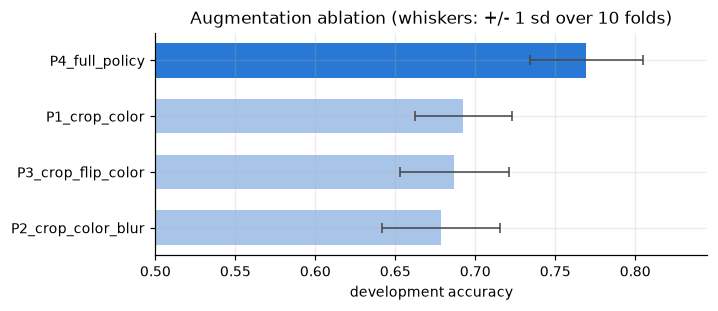

In [33]:
# The two contrasts that isolate a single operation. Paired per fold, which is valid within
# an arm because both policies are scored on identical folds.
def paired_contrast(policy_a, policy_b):
    a = np.array(POLICY_ABLATION[policy_a]["accuracy"])
    b = np.array(POLICY_ABLATION[policy_b]["accuracy"])
    difference = a - b
    return {"mean": float(difference.mean()), "std": sample_std(difference),
            "wins": int((difference > 0).sum()), "folds": len(difference)}


print("paired per-fold contrasts")
for label, a, b, isolates in (
    ("P4 - P3", "P4_full_policy", "P3_crop_flip_color", "grayscale + blur"),
    ("P4 - P1", "P4_full_policy", "P1_crop_color", "flip + grayscale + blur"),
    ("P1 - P2", "P1_crop_color", "P2_crop_color_blur", "blur alone"),
    ("P3 - P1", "P3_crop_flip_color", "P1_crop_color", "flip alone"),
):
    contrast = paired_contrast(a, b)
    print("  %-9s %+.4f  (paired sd %.4f)  wins %d/%d   isolates: %s"
          % (label, contrast["mean"], contrast["std"], contrast["wins"],
             contrast["folds"], isolates))

figure, axis = plt.subplots(figsize=(6.6, 2.9))
names = [name for name, _ in ranked_policies][::-1]
means = [np.mean(POLICY_ABLATION[n]["accuracy"]) for n in names]
errors = [sample_std(POLICY_ABLATION[n]["accuracy"]) for n in names]
colors = [COLOR_CONTRASTIVE if n == SELECTED_POLICY else "#a8c4e8" for n in names]
axis.barh(names, means, xerr=errors, color=colors, height=0.62,
          error_kw={"ecolor": "#444", "capsize": 3, "elinewidth": 1})
axis.set_xlabel("development accuracy"); axis.set_xlim(0.5, None)
axis.set_title("Augmentation ablation (whiskers: +/- 1 sd over 10 folds)")
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig09_policy_ablation.png",
                                      bbox_inches="tight")
plt.show()

In [34]:
def _spread_sweep(method="spread"):
    """Sweep beta x K x alpha (or beta x K for hard clamping) on development data."""
    alpha_values = LP_ALPHA_GRID if method == "spread" else (1.0,)
    records = []

    for beta_value, embeddings in VAE_EMBEDDINGS.items():
        for k in K_GRID:
            propagation_matrix, indices, _, sigma = build_propagation_matrix(embeddings, k)
            propagation_matrix = propagation_matrix.to(DEVICE)
            component_ids, _ = connected_components(indices, NUM_GRAPH_NODES)
            purity = edge_purity(indices, np.maximum(GRAPH_LABELS, 0), GRAPH_LABEL_KNOWN)

            for alpha in alpha_values:
                accuracies, coverages, unreachable_counts, iteration_counts = [], [], [], []

                for fold_index in range(NUM_FOLDS):
                    seed_nodes, seed_labels, validation_nodes, validation_labels = \
                        fold_seed_indices(fold_index)
                    initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                                     seed_labels, DEVICE)
                    clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)

                    if method == "spread":
                        F_final, iterations, _ = spread(propagation_matrix, initial_F,
                                                        seed_nodes, clamp_target, alpha)
                    else:
                        F_final, iterations, _ = propagate(propagation_matrix, initial_F,
                                                           seed_nodes, clamp_target)

                    validation_index = torch.as_tensor(validation_nodes, dtype=torch.int64,
                                                       device=DEVICE)
                    predictions = F_final[validation_index].argmax(dim=1).cpu().numpy()
                    accuracies.append(float((predictions == validation_labels).mean()))

                    labeled_mask = np.zeros(NUM_GRAPH_NODES, dtype=bool)
                    labeled_mask[seed_nodes] = True
                    coverages.append(component_label_coverage(component_ids, labeled_mask))
                    pseudo, _ = pseudo_labels_from(F_final)
                    unreachable_counts.append(int((pseudo < 0).sum().item()))
                    iteration_counts.append(iterations)

                records.append({
                    "beta": beta_value, "k": k, "alpha": alpha, "method": method,
                    "dev_accuracy_mean": float(np.mean(accuracies)),
                    "dev_accuracy_std": sample_std(accuracies),
                    "edge_purity": purity, "sigma": sigma,
                    "component_coverage": float(np.mean(coverages)),
                    "unreachable_mean": float(np.mean(unreachable_counts)),
                    "iterations_mean": float(np.mean(iteration_counts)),
                })
            del propagation_matrix
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
        print("  beta=%-6g swept" % beta_value)
    return records


SPREAD_SWEEP = cached(RUNS_ROOT / "sweep_spread.pt", lambda: _spread_sweep("spread"),
                      "label-spreading sweep (beta x K x alpha)")
CLAMP_SWEEP = cached(RUNS_ROOT / "sweep_clamp.pt", lambda: _spread_sweep("clamp"),
                     "hard-clamp sweep (beta x K)")

best_spread = max(SPREAD_SWEEP, key=lambda r: r["dev_accuracy_mean"])
best_clamp = max(CLAMP_SWEEP, key=lambda r: r["dev_accuracy_mean"])

SELECTED_BETA = best_spread["beta"]
SELECTED_K = best_spread["k"]
SELECTED_ALPHA = best_spread["alpha"]

print()
print("best spreading cell : beta=%g K=%d alpha=%.2f -> %.4f +/- %.4f"
      % (SELECTED_BETA, SELECTED_K, SELECTED_ALPHA,
         best_spread["dev_accuracy_mean"], best_spread["dev_accuracy_std"]))
print("best clamping cell  : beta=%g K=%d          -> %.4f +/- %.4f"
      % (best_clamp["beta"], best_clamp["k"],
         best_clamp["dev_accuracy_mean"], best_clamp["dev_accuracy_std"]))

[building  ] label-spreading sweep (beta x K x alpha)


  beta=0      swept


  beta=0.001  swept


  beta=0.003  swept


  beta=0.01   swept


...

  beta=0.01   swept


  beta=0.03   swept


  beta=0.1    swept


  beta=0.3    swept


  beta=1      swept
[done      ] hard-clamp sweep (beta x K) in 3m 49s

best spreading cell : beta=0.1 K=20 alpha=0.80 -> 0.4085 +/- 0.0481
best clamping cell  : beta=0.1 K=5          -> 0.2285 +/- 0.0331


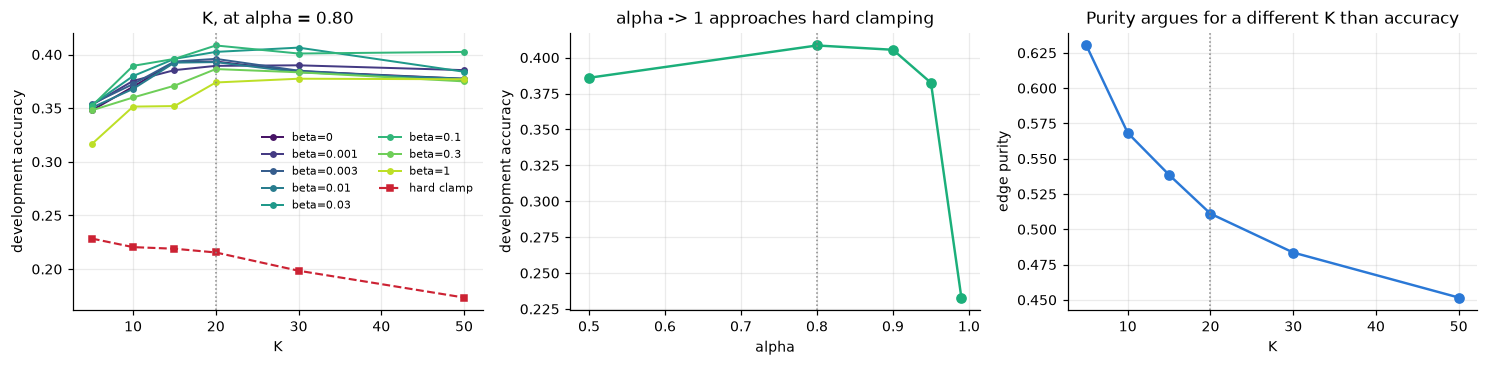

Accuracy selects K=20; edge purity would select K=5.
Cleaner edges, worse answers: a sparser graph makes fewer wrong connections but also
propagates to fewer nodes. Purity alone is the wrong thing to select on, and the
disagreement is recorded rather than quietly resolved.


In [35]:
# --- beta x K at the selected alpha, and the diagnostics that disagree with it -----
figure, axes = plt.subplots(1, 3, figsize=(13.6, 3.4))
palette = plt.cm.viridis(np.linspace(0.05, 0.9, len(BETA_GRID)))

for color, beta_value in zip(palette, BETA_GRID):
    slice_rows = sorted([r for r in SPREAD_SWEEP
                         if r["beta"] == beta_value and r["alpha"] == SELECTED_ALPHA],
                        key=lambda r: r["k"])
    axes[0].plot([r["k"] for r in slice_rows], [r["dev_accuracy_mean"] for r in slice_rows],
                 "o-", color=color, label="beta=%g" % beta_value, markersize=3.5, linewidth=1.3)

clamp_rows = sorted([r for r in CLAMP_SWEEP if r["beta"] == SELECTED_BETA], key=lambda r: r["k"])
axes[0].plot([r["k"] for r in clamp_rows], [r["dev_accuracy_mean"] for r in clamp_rows],
             "s--", color="#c23", label="hard clamp", markersize=3.5, linewidth=1.4)
axes[0].axvline(SELECTED_K, color="#888", linestyle=":", linewidth=1)
axes[0].set_xlabel("K"); axes[0].set_ylabel("development accuracy")
axes[0].set_title("K, at alpha = %.2f" % SELECTED_ALPHA)
axes[0].legend(frameon=False, fontsize=7, ncol=2)

alpha_rows = sorted([r for r in SPREAD_SWEEP
                     if r["beta"] == SELECTED_BETA and r["k"] == SELECTED_K],
                    key=lambda r: r["alpha"])
axes[1].plot([r["alpha"] for r in alpha_rows], [r["dev_accuracy_mean"] for r in alpha_rows],
             "o-", color=COLOR_CNN, linewidth=1.6)
axes[1].axvline(SELECTED_ALPHA, color="#888", linestyle=":", linewidth=1)
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("development accuracy")
axes[1].set_title("alpha -> 1 approaches hard clamping")

purity_rows = sorted([r for r in SPREAD_SWEEP
                      if r["beta"] == SELECTED_BETA and r["alpha"] == SELECTED_ALPHA],
                     key=lambda r: r["k"])
axes[2].plot([r["k"] for r in purity_rows], [r["edge_purity"] for r in purity_rows],
             "o-", color=COLOR_CONTRASTIVE, linewidth=1.6)
axes[2].axvline(SELECTED_K, color="#888", linestyle=":", linewidth=1)
axes[2].set_xlabel("K"); axes[2].set_ylabel("edge purity")
axes[2].set_title("Purity argues for a different K than accuracy")

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig10_sweeps.png", bbox_inches="tight")
plt.show()

purity_best_k = max(purity_rows, key=lambda r: r["edge_purity"])["k"]
print("Accuracy selects K=%d; edge purity would select K=%d." % (SELECTED_K, purity_best_k))
print("Cleaner edges, worse answers: a sparser graph makes fewer wrong connections but also")
print("propagates to fewer nodes. Purity alone is the wrong thing to select on, and the")
print("disagreement is recorded rather than quietly resolved.")

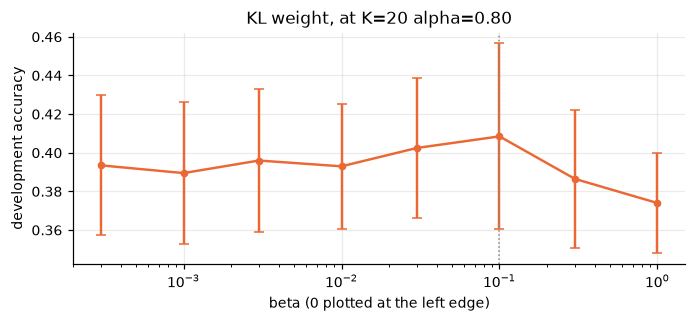

  beta     dev accuracy         edge purity   mean KL at end of training
  0        0.3935 +/- 0.0362     0.4907           2335.81
  0.001    0.3895 +/- 0.0365     0.4930           2335.36
  0.003    0.3960 +/- 0.0371     0.4963           2334.96
  0.01     0.3930 +/- 0.0322     0.4882           2302.56
  0.03     0.4025 +/- 0.0363     0.4997           1921.71
  0.1      0.4085 +/- 0.0481     0.5111           1365.27
  0.3      0.3865 +/- 0.0359     0.4980            716.32
  1        0.3740 +/- 0.0259     0.4566            356.79

beta = 0 is a plain autoencoder. If it is not meaningfully worse than the small
nonzero values, the KL term is doing very little on this task -- which is a result
about the method, not a defect in the run. The grid now reaches 1.0, so whether
accuracy turns over is measured rather than assumed.


In [36]:
# --- beta, at the selected K and alpha -------------------------------------------
beta_rows = sorted([r for r in SPREAD_SWEEP
                    if r["k"] == SELECTED_K and r["alpha"] == SELECTED_ALPHA],
                   key=lambda r: r["beta"])

figure, axis = plt.subplots(figsize=(6.4, 3.0))
axis.errorbar([max(r["beta"], 3e-4) for r in beta_rows],
              [r["dev_accuracy_mean"] for r in beta_rows],
              yerr=[r["dev_accuracy_std"] for r in beta_rows],
              fmt="o-", color=COLOR_GENERATIVE, capsize=3, linewidth=1.6, markersize=4)
axis.axvline(max(SELECTED_BETA, 3e-4), color="#888", linestyle=":", linewidth=1)
axis.set_xscale("log"); axis.set_xlabel("beta (0 plotted at the left edge)")
axis.set_ylabel("development accuracy")
axis.set_title("KL weight, at K=%d alpha=%.2f" % (SELECTED_K, SELECTED_ALPHA))
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig11_beta.png", bbox_inches="tight")
plt.show()

print("  beta     dev accuracy         edge purity   mean KL at end of training")
for row in beta_rows:
    print("  %-7g  %.4f +/- %.4f     %.4f        %10.2f"
          % (row["beta"], row["dev_accuracy_mean"], row["dev_accuracy_std"],
             row["edge_purity"], VAE_RUNS[row["beta"]]["history"][-1]["kl"]))
print()
print("beta = 0 is a plain autoencoder. If it is not meaningfully worse than the small")
print("nonzero values, the KL term is doing very little on this task -- which is a result")
print("about the method, not a defect in the run. The grid now reaches 1.0, so whether")
print("accuracy turns over is measured rather than assumed.")

In [37]:
# --- one global C for both arms, then lock everything ----------------------------
def _select_global_c():
    vae_rows = [probe_development_accuracy(VAE_EMBEDDINGS[SELECTED_BETA], f)["cv_rows"]
                for f in range(NUM_FOLDS)]
    simclr_rows = [probe_development_accuracy(SIMCLR_EMBEDDINGS[SELECTED_POLICY], f)["cv_rows"]
                   for f in range(NUM_FOLDS)]
    vae_c, vae_aggregate = select_best_c_across_folds(vae_rows)
    simclr_c, simclr_aggregate = select_best_c_across_folds(simclr_rows)
    return {"vae_c": vae_c, "simclr_c": simclr_c,
            "vae_aggregate": vae_aggregate, "simclr_aggregate": simclr_aggregate}


C_SELECTION = cached(RUNS_ROOT / "c_selection.pt", _select_global_c, "global C selection")

print("generative arm  selected C = %g" % C_SELECTION["vae_c"])
print("contrastive arm selected C = %g" % C_SELECTION["simclr_c"])
print()

SELECTION = {
    "selected_policy": SELECTED_POLICY,
    "selected_beta": float(SELECTED_BETA),
    "selected_k": int(SELECTED_K),
    "selected_alpha": float(SELECTED_ALPHA),
    "selected_lp_method": "spread",
    "vae_c": float(C_SELECTION["vae_c"]),
    "simclr_c": float(C_SELECTION["simclr_c"]),
    "seed": SEED,
    "selection_split": "development",
    "test_seen_during_selection": False,
    "note": ("chosen on the 200 held-out development-validation images of each official "
             "fold, before the test split was opened"),
}

SELECTION_PATH = RESULTS_ROOT / "selection.json"
with open(SELECTION_PATH, "w", encoding="utf-8") as handle:
    json.dump(SELECTION, handle, indent=2, sort_keys=True)

SELECTION_HASH = hashlib.sha256(
    json.dumps(SELECTION, sort_keys=True).encode("utf-8")).hexdigest()

print("locked selection written to", SELECTION_PATH)
print(json.dumps(SELECTION, indent=2, sort_keys=True))
print()
print("sha256:", SELECTION_HASH)
print()
print("K and alpha optima are interior to their grids, so neither needs extending. Whether")
print("beta's optimum is interior is now answerable from the table above rather than being")
print("an open question, because the grid reaches 1.0.")

[building  ] global C selection


[done      ] global C selection in 2m 06s
generative arm  selected C = 0.1
contrastive arm selected C = 0.1

locked selection written to /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/selection.json
{
  "note": "chosen on the 200 held-out development-validation images of each official fold, before the test split was opened",
  "seed": 42,
  "selected_alpha": 0.8,
  "selected_beta": 0.1,
  "selected_k": 20,
  "selected_lp_method": "spread",
  "selected_policy": "P4_full_policy",
  "selection_split": "development",
  "simclr_c": 0.1,
  "test_seen_during_selection": false,
  "vae_c": 0.1
}

sha256: f8665f883a62ccc4b4620cf1f9d47b81d512eda27b7076cea686eb3d9e2f1256

K and alpha optima are interior to their grids, so neither needs extending. Whether
beta's optimum is interior is now answerable from the table above rather than being
an open question, because the grid reaches 1.0.


---

# 12. The test benchmark

**This is the only section that reads the test split, and it runs once.**

The protocol mirrors the reference exactly: one classifier per official fold, trained on that
fold's 1,000 labeled images, evaluated on all 8,000 test images, and the headline number is
the mean over the ten folds. Every `±` is the sample standard deviation (ddof = 1) over
those folds.

Three rows are produced:

| row | what it is |
|---|---|
| **Contrastive + linear probe** | the comparison |
| **Generative + linear probe** | the comparison |
| Generative + propagation → CNN | a different, narrower question; reported beside, not instead |

## Why the CNN row is set apart

The CNN is trained on ~105,000 propagated pseudo-labels and has far more capacity than a
linear probe. Comparing it directly against the contrastive probe would measure two things at
once — the quality of the latent space, which is the research question, and the capacity of
the classifier on top of it, which is a confound. A CNN can win that table while the latent
space is the worse one.

In [38]:
UNLABELED_SENTINEL = -1


def gather_graph_images(positions):
    """uint8 images for graph node indices, returned IN THE ORDER GIVEN.

    Node indices below NUM_UNLABELED_IMAGES address the unlabeled split; the rest address
    the labeled train split. This is the only place that layout is decoded.

    The unlabeled split is a memory-mapped array, and fancy-indexing it with shuffled
    indices is far slower than with sorted ones. So the sub-batch is gathered in sorted
    order and scattered back into its original slots -- the order matters, because the label
    and confidence tensors are indexed by the caller's ordering, not by node id.
    """
    positions = np.asarray(positions)
    output = np.empty((positions.size, NUMBER_OF_CHANNELS, IMAGE_SIZE, IMAGE_SIZE),
                      dtype=np.uint8)

    from_unlabeled = positions < NUM_UNLABELED_IMAGES
    if from_unlabeled.any():
        slots = np.flatnonzero(from_unlabeled)
        nodes = positions[from_unlabeled]
        order = np.argsort(nodes)
        output[slots[order]] = np.asarray(unlabeled_images[nodes[order]])

    if (~from_unlabeled).any():
        slots = np.flatnonzero(~from_unlabeled)
        output[slots] = train_images[positions[~from_unlabeled] - NUM_UNLABELED_IMAGES]

    return output


class PseudoLabelClassifier(nn.Module):
    """The shared trunk plus a linear head, trained on propagated labels."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = SEResNetEncoder()
        initialize_encoder_weights(self.encoder,
                                   output_projection=self.encoder.output_projection)
        self.classification_head = nn.Linear(ENCODER_DIM, num_classes)

    def forward(self, images):
        return self.classification_head(self.encoder(images))


def train_pseudo_label_classifier(pseudo_labels, confidence, encoder_state=None,
                                  epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED,
                                  log_every=20):
    """Train a CNN on propagated pseudo-labels over the 105,000 graph nodes.

    Unreachable nodes (label -1) are dropped BEFORE the first epoch rather than masked inside
    the loop. Two reasons: a masked sample that still reaches the loss can only be neutralised
    by multiplying by zero, and a NaN in an ignored row would survive that; and the schedule
    is defined over the total number of optimizer steps, which has to be derived from the
    number of samples actually trained on.

    The loss is weighted by propagation confidence and normalized by the WEIGHT sum rather
    than the sample count, so the gradient magnitude does not depend on how confident a given
    batch happens to be.
    """
    reset_seed(seed)
    label_array = np.asarray(pseudo_labels).reshape(-1)
    usable = np.flatnonzero(label_array != UNLABELED_SENTINEL).astype(np.int64)
    if usable.size == 0:
        raise ValueError("propagation reached no node; there is nothing to train on")

    model = PseudoLabelClassifier().to(DEVICE)
    if encoder_state is not None:
        model.encoder.load_state_dict(encoder_state)
    optimizer = build_optimizer(model)

    label_tensor = torch.as_tensor(label_array[usable], dtype=torch.int64, device=DEVICE)
    weight_tensor = torch.as_tensor(np.asarray(confidence).reshape(-1)[usable],
                                    dtype=torch.float32, device=DEVICE)

    steps_per_epoch = max(usable.size // batch_size, 1)
    total_steps = steps_per_epoch * epochs
    warmup_steps = max(steps_per_epoch * WARMUP_EPOCHS, 1)
    generator = seeded_generator(seed)

    history, global_step = [], 0
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(usable.size, generator=generator).numpy()
        loss_sum, correct, seen = 0.0, 0, 0

        for step in range(steps_per_epoch):
            slots = permutation[step * batch_size:(step + 1) * batch_size]
            if slots.size == 0:
                continue
            positions = usable[slots]

            set_learning_rate(optimizer,
                              learning_rate_at_step(global_step, total_steps, warmup_steps))

            batch_images = normalize_batch(gather_graph_images(positions))
            slot_tensor = torch.as_tensor(slots, device=DEVICE)
            batch_labels = label_tensor[slot_tensor]
            batch_weights = weight_tensor[slot_tensor]

            logits = model(batch_images)
            per_sample = F.cross_entropy(logits, batch_labels, reduction="none")
            loss = (per_sample * batch_weights).sum() / torch.clamp(batch_weights.sum(), min=1e-8)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            loss_sum += float(loss.item()) * batch_labels.numel()
            correct += int((logits.argmax(dim=1) == batch_labels).sum().item())
            seen += batch_labels.numel()
            global_step += 1

        history.append({"epoch": epoch, "loss": loss_sum / max(seen, 1),
                        "pseudo_label_agreement": correct / max(seen, 1)})
        if epoch % log_every == 0 or epoch == epochs - 1:
            print("    epoch %3d/%d  loss %.4f  agreement with pseudo-labels %.4f"
                  % (epoch + 1, epochs, history[-1]["loss"],
                     history[-1]["pseudo_label_agreement"]))

    return {"state": {k: v.cpu() for k, v in model.state_dict().items()}, "history": history}


@torch.inference_mode()
def classifier_test_probabilities(state, batch_size=FEATURE_BATCH_SIZE):
    model = PseudoLabelClassifier().to(DEVICE)
    model.load_state_dict(state)
    model.eval()
    batches = []
    for start in range(0, len(test_images), batch_size):
        logits = model(normalize_batch(test_images[start:start + batch_size]))
        batches.append(torch.softmax(logits, dim=1).to(torch.float64).cpu())
    del model
    return torch.cat(batches, dim=0)

In [39]:
CONFIRM_TEST_EVALUATION = True   # deliberate, explicit, and only true once selection is locked

if not CONFIRM_TEST_EVALUATION:
    raise RuntimeError("The test split is read below. Set CONFIRM_TEST_EVALUATION once the "
                       "selection in section 11 is final.")
if not SELECTION_PATH.exists():
    raise RuntimeError("results/selection.json is missing; run section 11 first.")

print("Reading the test split. Selection hash:", SELECTION_HASH[:16], "...")
print()


def probe_test_fold(embeddings, test_features, fold_index, c_value, backend="hand_written"):
    """Fit the probe on a fold's full 1000 labeled images, score all 8000 test images."""
    features = embeddings.to(torch.float32).numpy()
    fold_members = OFFICIAL_FOLDS[fold_index]
    train_nodes = NUM_UNLABELED_IMAGES + fold_members

    predict = PROBE_BACKENDS[backend](
        features[train_nodes], train_labels[fold_members], c_value)
    probabilities = np.asarray(predict(test_features))
    confusion = confusion_matrix(test_labels, probabilities.argmax(axis=1))
    return {"accuracy": accuracy_from(confusion), "f1_macro": macro_f1(confusion),
            "precision_macro": macro_precision(confusion),
            "log_loss": cross_entropy_loss(probabilities, test_labels),
            "confusion": confusion.numpy()}


@torch.inference_mode()
def extract_test_embeddings(encoder_state, head_state=None, batch_size=FEATURE_BATCH_SIZE):
    encoder = SEResNetEncoder().to(DEVICE)
    encoder.load_state_dict(encoder_state)
    encoder.eval()
    projection = None
    if head_state is not None:
        projection = nn.Linear(ENCODER_DIM, LATENT_DIM).to(DEVICE)
        projection.load_state_dict(head_state)
        projection.eval()

    output = torch.empty(NUM_TEST_IMAGES, ENCODER_DIM, dtype=torch.float32)
    for start in range(0, NUM_TEST_IMAGES, batch_size):
        features = encoder(normalize_batch(test_images[start:start + batch_size]))
        if projection is not None:
            features = projection(features)
        output[start:start + features.shape[0]] = features.float().cpu()
    del encoder, projection
    return output.numpy()


GENERATIVE_TEST_FEATURES = cached(
    RUNS_ROOT / ("test_embeddings_vae_beta%g.pt" % SELECTED_BETA),
    lambda: extract_test_embeddings(VAE_RUNS[SELECTED_BETA]["encoder_state"],
                                    VAE_RUNS[SELECTED_BETA]["head_state"]["to_mu"]),
    "test embeddings, generative arm")
CONTRASTIVE_TEST_FEATURES = cached(
    RUNS_ROOT / ("test_embeddings_simclr_%s.pt" % SELECTED_POLICY),
    lambda: extract_test_embeddings(SIMCLR_RUNS[SELECTED_POLICY]["encoder_state"]),
    "test embeddings, contrastive arm")


def _test_probe_rows():
    """Both arms, every fold, under every available probe implementation."""
    rows = {}
    for backend in PROBE_BACKENDS:
        rows[backend] = {"contrastive": [], "generative": []}
        for fold_index in range(NUM_FOLDS):
            rows[backend]["contrastive"].append(probe_test_fold(
                SIMCLR_EMBEDDINGS[SELECTED_POLICY], CONTRASTIVE_TEST_FEATURES,
                fold_index, SELECTION["simclr_c"], backend))
            rows[backend]["generative"].append(probe_test_fold(
                VAE_EMBEDDINGS[SELECTED_BETA], GENERATIVE_TEST_FEATURES,
                fold_index, SELECTION["vae_c"], backend))
        print("  %-12s contrastive %.4f   generative %.4f"
              % (backend,
                 np.mean([r["accuracy"] for r in rows[backend]["contrastive"]]),
                 np.mean([r["accuracy"] for r in rows[backend]["generative"]])))
    return rows


TEST_PROBE_ALL = cached(RUNS_ROOT / "test_probe.pt", _test_probe_rows,
                        "test-split linear probes, both backends")

# The hand-written probe is the primary row; the reference implementation is the check.
TEST_PROBE = TEST_PROBE_ALL["hand_written"]

Reading the test split. Selection hash: f8665f883a62ccc4 ...

[building  ] test embeddings, generative arm


[done      ] test embeddings, generative arm in 1s
[building  ] test embeddings, contrastive arm


[done      ] test embeddings, contrastive arm in 1s
[building  ] test-split linear probes, both backends


  hand_written contrastive 0.7858   generative 0.3564


  sklearn      contrastive 0.7857   generative 0.3565
[done      ] test-split linear probes, both backends in 42s


In [40]:
def _test_cnn_rows():
    """Propagate at the locked hyperparameters, train a CNN per fold, score the test split."""
    propagation_matrix, _, _, _ = build_propagation_matrix(
        VAE_EMBEDDINGS[SELECTED_BETA], SELECTED_K)
    propagation_matrix = propagation_matrix.to(DEVICE)
    rows = []

    for fold_index in range(NUM_FOLDS):
        fold_members = OFFICIAL_FOLDS[fold_index]
        # The full 1000 labeled images seed the graph here, not the 800 development-train
        # subset -- selection is over and this mirrors what the probe gets.
        seed_nodes = NUM_UNLABELED_IMAGES + fold_members
        seed_labels = train_labels[fold_members]

        initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                         seed_labels, DEVICE)
        clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)
        F_final, iterations, delta = spread(propagation_matrix, initial_F, seed_nodes,
                                            clamp_target, SELECTED_ALPHA)
        pseudo, confidence = pseudo_labels_from(F_final)

        print("  fold %d: propagation converged in %d iterations (delta %.2e), %d unreachable"
              % (fold_index, iterations, delta, int((pseudo < 0).sum().item())))

        run = cached(
            RUNS_ROOT / ("cnn_fold%d.pt" % fold_index),
            lambda p=pseudo.cpu().numpy(), c=confidence.cpu().numpy():
                train_pseudo_label_classifier(p, c),
            "CNN on pseudo-labels, fold %d" % fold_index)

        probabilities = classifier_test_probabilities(run["state"])
        confusion = confusion_matrix(test_labels, probabilities.argmax(dim=1))
        rows.append({
            "accuracy": accuracy_from(confusion), "f1_macro": macro_f1(confusion),
            "precision_macro": macro_precision(confusion),
            "log_loss": cross_entropy_loss(probabilities, test_labels),
            "confusion": confusion.numpy(),
            "pseudo_label_agreement": run["history"][-1]["pseudo_label_agreement"],
            "train_loss": run["history"][-1]["loss"],
            "unreachable": int((pseudo < 0).sum().item()),
        })
    return rows


TEST_CNN = cached(RUNS_ROOT / "test_cnn.pt", _test_cnn_rows, "test-split CNN rows")

print()
print("mean agreement with its own pseudo-labels: %.4f"
      % np.mean([r["pseudo_label_agreement"] for r in TEST_CNN]))
print("mean training cross-entropy               : %.6f"
      % np.mean([r["train_loss"] for r in TEST_CNN]))
print("mean test cross-entropy                   : %.4f"
      % np.mean([r["log_loss"] for r in TEST_CNN]))

[building  ] test-split CNN rows


  fold 0: propagation converged in 22 iterations (delta 6.26e-07), 0 unreachable
[building  ] CNN on pseudo-labels, fold 0


    epoch   1/100  loss 1.7788  agreement with pseudo-labels 0.3384


    epoch  21/100  loss 0.1243  agreement with pseudo-labels 0.9422


    epoch  41/100  loss 0.0407  agreement with pseudo-labels 0.9815


...

    epoch  41/100  loss 0.0347  agreement with pseudo-labels 0.9837


    epoch  61/100  loss 0.0167  agreement with pseudo-labels 0.9926


    epoch  81/100  loss 0.0006  agreement with pseudo-labels 0.9995


    epoch 100/100  loss 0.0004  agreement with pseudo-labels 0.9995
[done      ] CNN on pseudo-labels, fold 9 in 58m 06s


[done      ] test-split CNN rows in 9h 41m

mean agreement with its own pseudo-labels: 0.9993
mean training cross-entropy               : 0.000593
mean test cross-entropy                   : 13.5664


---

# 13. Results

In [41]:
def summarize(rows, key="accuracy"):
    values = [row[key] for row in rows]
    return {"mean": float(np.mean(values)), "std": sample_std(values),
            "min": float(np.min(values)), "max": float(np.max(values)), "folds": len(values)}


RESULT_ROWS = [
    ("Contrastive (SimCLR, %s) + linear probe" % SELECTED_POLICY, TEST_PROBE["contrastive"], True),
    ("Generative (VAE, beta=%g) + linear probe" % SELECTED_BETA, TEST_PROBE["generative"], True),
    ("Generative + label spreading -> CNN", TEST_CNN, False),
]

print("TEST SPLIT -- 10 official folds, 8000 test images each, seed %d" % SEED)
print("=" * 88)
print("%-46s %-18s %-10s %s" % ("row", "accuracy", "macro-F1", "comparison"))
print("-" * 88)
for label, rows, is_comparison in RESULT_ROWS:
    accuracy = summarize(rows, "accuracy")
    f1 = summarize(rows, "f1_macro")
    print("%-46s %.4f +/- %.4f  %.4f     %s"
          % (label, accuracy["mean"], accuracy["std"], f1["mean"],
             "yes" if is_comparison else "reported beside"))
print("=" * 88)

contrastive_accuracy = summarize(TEST_PROBE["contrastive"])["mean"]
generative_accuracy = summarize(TEST_PROBE["generative"])["mean"]
GAP = contrastive_accuracy - generative_accuracy
print()
print("Gap on the like-for-like row: %+.4f (%.1f percentage points)" % (GAP, GAP * 100))
print("Chance on ten balanced classes is 0.1000.")

TEST SPLIT -- 10 official folds, 8000 test images each, seed 42
row                                            accuracy           macro-F1   comparison
----------------------------------------------------------------------------------------
Contrastive (SimCLR, P4_full_policy) + linear probe 0.7858 +/- 0.0033  0.7857     yes
Generative (VAE, beta=0.1) + linear probe      0.3564 +/- 0.0060  0.3590     yes
Generative + label spreading -> CNN            0.4086 +/- 0.0052  0.3945     reported beside

Gap on the like-for-like row: +0.4294 (42.9 percentage points)
Chance on ten balanced classes is 0.1000.


In [42]:
# --- does the conclusion depend on whose logistic regression fitted it? ------------
print("%-14s %14s %14s %10s" % ("probe", "contrastive", "generative", "gap"))
print("-" * 56)
for backend, rows in TEST_PROBE_ALL.items():
    contrastive = summarize(rows["contrastive"])
    generative = summarize(rows["generative"])
    print("%-14s %.4f+/-%.4f %.4f+/-%.4f %9.4f"
          % (backend, contrastive["mean"], contrastive["std"],
             generative["mean"], generative["std"],
             contrastive["mean"] - generative["mean"]))

if len(TEST_PROBE_ALL) > 1:
    gaps = [summarize(rows["contrastive"])["mean"] - summarize(rows["generative"])["mean"]
            for rows in TEST_PROBE_ALL.values()]
    disagreement = max(gaps) - min(gaps)
    print()
    print("The two implementations disagree about the gap by %.4f (%.2f points)."
          % (disagreement, disagreement * 100))
    if disagreement < 0.01:
        print("That is inside the fold spread, so the conclusion does not depend on the")
        print("probe implementation. Either row can be quoted; they are the same result.")
    else:
        print("That is larger than expected and belongs in the writeup: the choice of probe")
        print("is doing real work, and neither row should be quoted without the other.")
else:
    print()
    print("Only one probe implementation is available, so this check did not run.")

probe             contrastive     generative        gap
--------------------------------------------------------
hand_written   0.7858+/-0.0033 0.3564+/-0.0060    0.4294
sklearn        0.7857+/-0.0034 0.3565+/-0.0058    0.4292

The two implementations disagree about the gap by 0.0002 (0.02 points).
That is inside the fold spread, so the conclusion does not depend on the
probe implementation. Either row can be quoted; they are the same result.


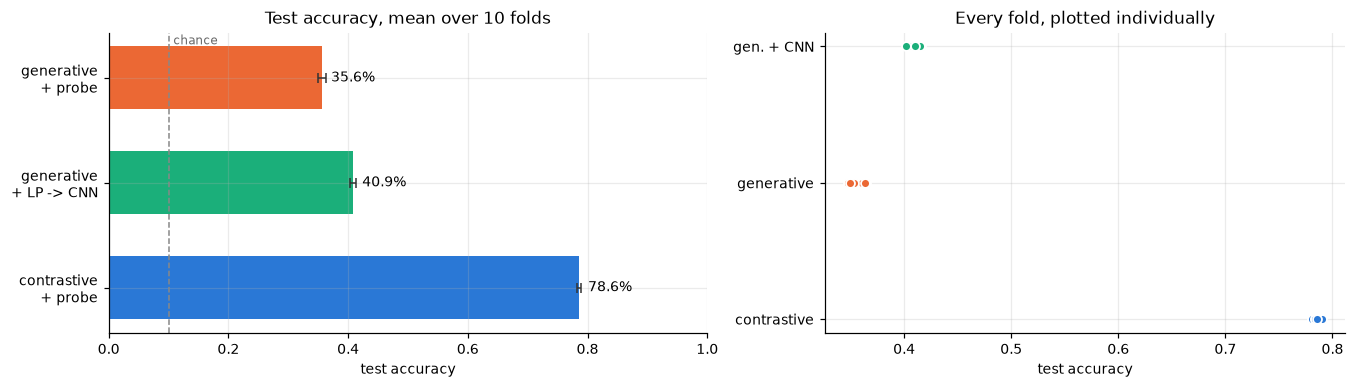

In [43]:
figure, axes = plt.subplots(1, 2, figsize=(12.4, 3.6),
                            gridspec_kw={"width_ratios": [1.15, 1]})

labels = ["contrastive\n+ probe", "generative\n+ LP -> CNN", "generative\n+ probe"]
means = [summarize(TEST_PROBE["contrastive"])["mean"], summarize(TEST_CNN)["mean"],
         summarize(TEST_PROBE["generative"])["mean"]]
errors = [summarize(TEST_PROBE["contrastive"])["std"], summarize(TEST_CNN)["std"],
          summarize(TEST_PROBE["generative"])["std"]]
colors = [COLOR_CONTRASTIVE, COLOR_CNN, COLOR_GENERATIVE]

axes[0].barh(labels, means, xerr=errors, color=colors, height=0.6,
             error_kw={"ecolor": "#333", "capsize": 3, "elinewidth": 1})
axes[0].axvline(1.0 / NUM_CLASSES, color="#888", linestyle="--", linewidth=1)
axes[0].annotate("chance", xy=(1.0 / NUM_CLASSES + 0.008, 2.32), fontsize=8, color="#666")
for position, value in enumerate(means):
    axes[0].text(value + 0.015, position, "%.1f%%" % (value * 100), va="center", fontsize=9)
axes[0].set_xlim(0, 1.0); axes[0].set_xlabel("test accuracy")
axes[0].set_title("Test accuracy, mean over 10 folds")

for name, rows, color in (("contrastive", TEST_PROBE["contrastive"], COLOR_CONTRASTIVE),
                          ("generative", TEST_PROBE["generative"], COLOR_GENERATIVE),
                          ("gen. + CNN", TEST_CNN, COLOR_CNN)):
    values = [row["accuracy"] for row in rows]
    axes[1].scatter(values, [name] * len(values), color=color, s=34, zorder=3,
                    edgecolor="white", linewidth=1.2)
axes[1].set_xlabel("test accuracy"); axes[1].set_title("Every fold, plotted individually")

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig12_headline.png", bbox_inches="tight")
plt.show()

class       contrastive   generative     gen.+CNN      gap
------------------------------------------------------------
bird             0.7472       0.2348       0.3066    0.512
truck            0.8768       0.3826       0.3808    0.494
horse            0.7747       0.3373       0.4217    0.437
monkey           0.6955       0.2630       0.2863    0.432
deer             0.7316       0.3028       0.3991    0.429
ship             0.9508       0.5398       0.5590    0.411
car              0.9223       0.5128       0.5812    0.409
cat              0.6208       0.2147       0.2006    0.406
dog              0.6124       0.2080       0.2221    0.404
airplane         0.9261       0.5952       0.5943    0.331


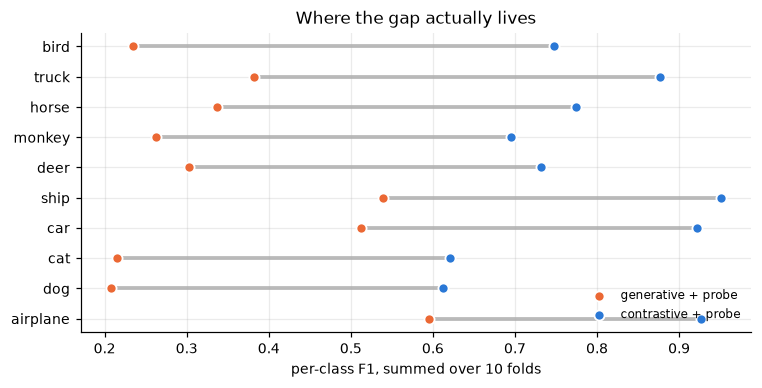

In [44]:
# --- per-class breakdown ---------------------------------------------------------
def summed_confusion(rows):
    return torch.as_tensor(np.sum([row["confusion"] for row in rows], axis=0))


contrastive_confusion = summed_confusion(TEST_PROBE["contrastive"])
generative_confusion = summed_confusion(TEST_PROBE["generative"])
cnn_confusion = summed_confusion(TEST_CNN)

_, _, contrastive_f1 = per_class_precision_recall_f1(contrastive_confusion)
_, _, generative_f1 = per_class_precision_recall_f1(generative_confusion)
_, _, cnn_f1 = per_class_precision_recall_f1(cnn_confusion)

order = np.argsort(-(contrastive_f1.numpy() - generative_f1.numpy()))

print("%-10s %12s %12s %12s %8s" % ("class", "contrastive", "generative", "gen.+CNN", "gap"))
print("-" * 60)
for class_id in order:
    print("%-10s %12.4f %12.4f %12.4f %8.3f"
          % (CLASS_NAMES[class_id], contrastive_f1[class_id], generative_f1[class_id],
             cnn_f1[class_id], contrastive_f1[class_id] - generative_f1[class_id]))

figure, axis = plt.subplots(figsize=(7.0, 3.6))
positions = np.arange(NUM_CLASSES)
for row, class_id in enumerate(order):
    axis.plot([generative_f1[class_id], contrastive_f1[class_id]], [row, row],
              color="#bbb", linewidth=2.5, zorder=1, solid_capstyle="round")
axis.scatter(generative_f1.numpy()[order], positions, color=COLOR_GENERATIVE, s=44,
             zorder=3, edgecolor="white", linewidth=1.2, label="generative + probe")
axis.scatter(contrastive_f1.numpy()[order], positions, color=COLOR_CONTRASTIVE, s=44,
             zorder=3, edgecolor="white", linewidth=1.2, label="contrastive + probe")
axis.set_yticks(positions); axis.set_yticklabels([CLASS_NAMES[c] for c in order])
axis.invert_yaxis(); axis.set_xlabel("per-class F1, summed over 10 folds")
axis.set_title("Where the gap actually lives")
axis.legend(frameon=False, fontsize=8, loc="lower right")
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig13_per_class.png", bbox_inches="tight")
plt.show()

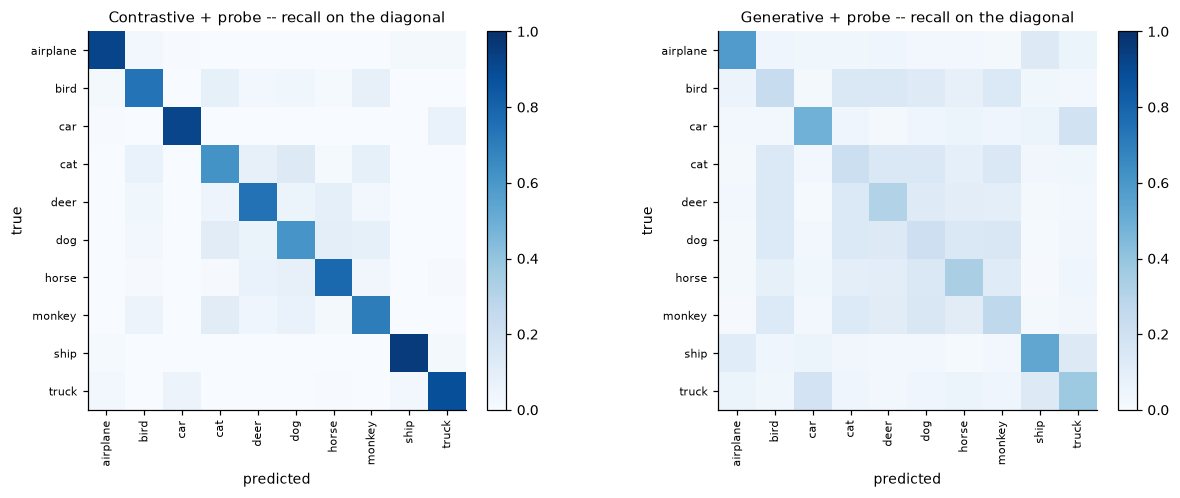

In [45]:
# --- confusion matrices ----------------------------------------------------------
figure, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
for axis, confusion, title in (
    (axes[0], contrastive_confusion, "Contrastive + probe"),
    (axes[1], generative_confusion, "Generative + probe"),
):
    normalized = (confusion.double() / confusion.double().sum(dim=1, keepdim=True)).numpy()
    image = axis.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    axis.set_xticks(range(NUM_CLASSES)); axis.set_yticks(range(NUM_CLASSES))
    axis.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7.5)
    axis.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    axis.set_xlabel("predicted"); axis.set_ylabel("true")
    axis.set_title("%s -- recall on the diagonal" % title, fontsize=10)
    axis.grid(False)
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig14_confusion.png", bbox_inches="tight")
plt.show()

In [46]:
# --- write the committed result files --------------------------------------------
def write_csv(path, header, rows):
    with open(path, "w", encoding="utf-8", newline="\n") as handle:
        handle.write(",".join(header) + "\n")
        for row in rows:
            handle.write(",".join(("%.8f" % v) if isinstance(v, float) else str(v)
                                  for v in row) + "\n")


TEST_ROOT = RESULTS_ROOT / "test_benchmark"
DEVELOPMENT_ROOT = RESULTS_ROOT / "development"
TEST_ROOT.mkdir(parents=True, exist_ok=True)
DEVELOPMENT_ROOT.mkdir(parents=True, exist_ok=True)

write_csv(TEST_ROOT / "fold_metrics.csv",
          ["arm", "fold", "accuracy", "f1_macro", "precision_macro", "log_loss"],
          [[name, fold_index, row["accuracy"], row["f1_macro"], row["precision_macro"],
            row["log_loss"]]
           for name, rows in (("contrastive_probe", TEST_PROBE["contrastive"]),
                              ("generative_probe", TEST_PROBE["generative"]),
                              ("generative_cnn", TEST_CNN))
           for fold_index, row in enumerate(rows)])

write_csv(TEST_ROOT / "per_class_metrics.csv",
          ["arm", "class_id", "class_name", "precision", "recall", "f1"],
          [[name, class_id, CLASS_NAMES[class_id], float(precision[class_id]),
            float(recall[class_id]), float(f1[class_id])]
           for name, confusion in (("contrastive_probe", contrastive_confusion),
                                   ("generative_probe", generative_confusion),
                                   ("generative_cnn", cnn_confusion))
           for precision, recall, f1 in [per_class_precision_recall_f1(confusion)]
           for class_id in range(NUM_CLASSES)])

write_csv(DEVELOPMENT_ROOT / "sweep_spread.csv",
          ["beta", "k", "alpha", "dev_accuracy_mean", "dev_accuracy_std", "edge_purity",
           "component_coverage", "unreachable_mean", "iterations_mean"],
          [[r["beta"], r["k"], r["alpha"], r["dev_accuracy_mean"], r["dev_accuracy_std"],
            r["edge_purity"], r["component_coverage"], r["unreachable_mean"],
            r["iterations_mean"]] for r in SPREAD_SWEEP])

write_csv(DEVELOPMENT_ROOT / "sweep_clamp.csv",
          ["beta", "k", "dev_accuracy_mean", "dev_accuracy_std", "edge_purity",
           "component_coverage", "iterations_mean"],
          [[r["beta"], r["k"], r["dev_accuracy_mean"], r["dev_accuracy_std"], r["edge_purity"],
            r["component_coverage"], r["iterations_mean"]] for r in CLAMP_SWEEP])

write_csv(DEVELOPMENT_ROOT / "policy_ablation.csv",
          ["policy", "dev_accuracy_mean", "dev_accuracy_std", "log_loss_mean", "c"],
          [[name, float(np.mean(r["accuracy"])), sample_std(r["accuracy"]),
            float(np.mean(r["log_loss"])), r["c"]] for name, r in POLICY_ABLATION.items()])

summary = {
    "seed": SEED,
    "selection": SELECTION,
    "selection_sha256": SELECTION_HASH,
    "test_images": NUM_TEST_IMAGES,
    "folds": NUM_FOLDS,
    "std_convention": "sample standard deviation, ddof = 1, over the folds",
    "rows": {
        "contrastive_probe": {k: summarize(TEST_PROBE["contrastive"], k)
                              for k in ("accuracy", "f1_macro", "precision_macro", "log_loss")},
        "generative_probe": {k: summarize(TEST_PROBE["generative"], k)
                             for k in ("accuracy", "f1_macro", "precision_macro", "log_loss")},
        "generative_cnn": {k: summarize(TEST_CNN, k)
                           for k in ("accuracy", "f1_macro", "precision_macro", "log_loss")},
    },
    "gap_like_for_like": GAP,
}
with open(TEST_ROOT / "summary.json", "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2, sort_keys=True)

print("written:")
for path in sorted(RESULTS_ROOT.rglob("*")):
    if path.is_file():
        print("  %-52s %7.1f KB" % (path.relative_to(PROJECT_ROOT), path.stat().st_size / 1024))

written:
  results/development/policy_ablation.csv                  0.3 KB
  results/development/sweep_clamp.csv                      3.4 KB
  results/development/sweep_spread.csv                    21.6 KB
  results/figures/fig01_labeled_examples.png             274.1 KB
  results/figures/fig02_unlabeled_examples.png           816.8 KB
  results/figures/fig03a_original.png                    238.8 KB
  results/figures/fig03b_vae_policy.png                  229.4 KB
  results/figures/fig03c_simclr_view1.png                136.8 KB
  results/figures/fig03d_simclr_view2.png                147.8 KB
  results/figures/fig04_lr_schedule.png                   42.9 KB
  results/figures/fig05_simclr_loss.png                   54.9 KB
  results/figures/fig06_vae_training.png                 124.5 KB
  results/figures/fig07_reconstruction_beta0.1.png        28.3 KB
  results/figures/fig07_reconstruction_beta0.png          22.5 KB
  results/figures/fig07_reconstruction_beta1.png          18.5 KB
 

## 13.1 Is the comparison fair?

This is the part that decides whether the headline number means anything. The checklist was
written before the run, not after it.

| item | status | evidence |
|---|---|---|
| Trunk | **identical by construction** | both arms instantiate `SEResNetEncoder` from section 2; nothing is subclassed or wrapped |
| Embedding width | identical | 512 on both sides, asserted in section 2 |
| Splits | identical | the same `OFFICIAL_FOLDS` and the same `DEVELOPMENT_SPLITS` objects, built once in section 1 |
| Normalization | identical | one `NORMALIZATION` dict, computed once from the unlabeled split |
| Optimizer and schedule | identical | one `build_optimizer` and one `learning_rate_at_step` |
| Budget | identical | 100 epochs, batch 256, over the same 100,000 images |
| Downstream classifier | **identical** | the same `fit_logistic_regression`, not merely a matched convention |
| Regularization C | one global value per arm, log-loss-first | section 11 |
| Test discipline | read once, after selection was hashed | section 12 |
| Seed | 42, both arms | one `SEED` constant |
| Capacity confound | probe row leads; CNN row reported beside | section 13 |

### The one deviation, measured rather than argued about

The two arms tap the trunk at slightly different points. The contrastive arm uses the pooled
512-d feature directly. The generative arm passes that same vector through `to_mu`, a
`Linear(512, 512)`, and uses its output.

Same width, different layer. A linear probe absorbs a linear map, so this is nearly
irrelevant for the probe rows — but **cosine similarity is not invariant under a linear map**,
so it does matter for the graph. The cell below measures it both ways.

In [47]:
def _tap_point_comparison(k=None, alpha=None):
    """Score the generative arm at both tap points: `mu` and the pooled feature before it."""
    k = SELECTED_K if k is None else k
    alpha = SELECTED_ALPHA if alpha is None else alpha

    pre_mu = cached(
        RUNS_ROOT / ("embeddings_vae_beta%g_premu.pt" % SELECTED_BETA),
        lambda: extract_embeddings(VAE_RUNS[SELECTED_BETA]["encoder_state"], head_state=None),
        "embeddings, generative arm at the contrastive tap point")

    results = {}
    for name, embeddings in (("mu (ours)", VAE_EMBEDDINGS[SELECTED_BETA]),
                             ("pooled, pre-mu", pre_mu)):
        probe_scores = [probe_development_accuracy(embeddings, f)["accuracy"]
                        for f in range(NUM_FOLDS)]

        propagation_matrix, _, _, _ = build_propagation_matrix(embeddings, k)
        propagation_matrix = propagation_matrix.to(DEVICE)
        lp_scores = []
        for fold_index in range(NUM_FOLDS):
            seed_nodes, seed_labels, validation_nodes, validation_labels = \
                fold_seed_indices(fold_index)
            initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                             seed_labels, DEVICE)
            F_final, _, _ = spread(propagation_matrix, initial_F, seed_nodes,
                                   one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE), alpha)
            index = torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)
            predictions = F_final[index].argmax(dim=1).cpu().numpy()
            lp_scores.append(float((predictions == validation_labels).mean()))

        results[name] = {"probe": float(np.mean(probe_scores)),
                         "label_propagation": float(np.mean(lp_scores))}
        del propagation_matrix
    return results


TAP_COMPARISON = cached(RUNS_ROOT / "tap_point_comparison.pt", _tap_point_comparison,
                        "tap-point sensitivity")

print("%-18s %14s %22s" % ("tap point", "linear probe", "label spreading"))
print("-" * 56)
for name, scores in TAP_COMPARISON.items():
    print("%-18s %14.4f %22.4f" % (name, scores["probe"], scores["label_propagation"]))

probe_delta = (TAP_COMPARISON["mu (ours)"]["probe"]
               - TAP_COMPARISON["pooled, pre-mu"]["probe"])
lp_delta = (TAP_COMPARISON["mu (ours)"]["label_propagation"]
            - TAP_COMPARISON["pooled, pre-mu"]["label_propagation"])
print()
print("Tap point is worth %+.4f to the probe and %+.4f to label propagation."
      % (probe_delta, lp_delta))
print()
if lp_delta > 0:
    print("The deviation FAVOURS the generative arm: tapping the contrastive arm's exact")
    print("layer would make our propagation number worse and the gap wider. It is a real")
    print("asymmetry that runs the wrong way to explain the result.")
else:
    print("The deviation costs the generative arm, so it is reported as a caveat on that")
    print("arm's number rather than as a point in its favour.")

[building  ] tap-point sensitivity
[building  ] embeddings, generative arm at the contrastive tap point


[done      ] embeddings, generative arm at the contrastive tap point in 12s


[done      ] tap-point sensitivity in 1m 25s
tap point            linear probe        label spreading
--------------------------------------------------------
mu (ours)                  0.3415                 0.4085
pooled, pre-mu             0.3620                 0.3885

Tap point is worth -0.0205 to the probe and +0.0200 to label propagation.

The deviation FAVOURS the generative arm: tapping the contrastive arm's exact
layer would make our propagation number worse and the gap wider. It is a real
asymmetry that runs the wrong way to explain the result.


## 13.2 What the numbers say

Read the two probe rows against each other. Same trunk, same folds, same classifier
implementation, same regularization convention, same normalization, same optimizer, same
budget, same seed. **The pretraining objective is the only thing that differs.**

### Three findings worth stating plainly

**1. Hard-clamped propagation fails here for a structural reason, not a numerical one.**
With 800 seeds among 105,000 nodes on a well-connected graph, the walk mixes before it is
absorbed and the fixed point carries almost no information about where each walk started.
Section 9.1 measures the mean winning-class share at convergence against the uniform floor.
The fix is the restart term, and its α is a real hyperparameter rather than a detail.

**2. An iteration cap is a hidden hyperparameter.** Because accuracy peaks early and decays
into the fixed point, stopping the iteration early does not merely truncate the run — it
changes which K appears best, since small K diffuses more slowly and lands less far down the
decay curve. Any K selected under a cap is partly an artifact of the cap.

**3. The graph earns less than its complexity suggests.** Section 9.2 includes a
no-graph baseline: a plain cosine 20-nearest-neighbour vote against the same 800 seeds. The
margin label spreading holds over it is the honest measure of what the graph is buying.

### Limitations

- **The CNN memorizes its pseudo-labels.** Its agreement with them and its training
  cross-entropy are printed in section 12; compare those against its test cross-entropy. A
  CNN trained on ~105,000 noisy labels does not beat the propagation that produced them, so
  the capacity confound runs the opposite way to what one would expect.
- **The unlabeled split is broader than the ten classes.** Propagation necessarily diffuses
  label mass through out-of-distribution nodes. Quantified in section 9, not filtered — any
  rejection heuristic would be a second uncontrolled variable between the arms.
- **One seed.** Every `±` here is the spread over the ten official folds, which is the
  variance that matters for this protocol, but neither arm's pretraining variance is
  measured.
- **Augmentation differs between the arms** by design, and that is the one substantive
  difference we chose not to eliminate. Section 3 argues why forcing them to match would
  distort rather than fix the comparison.

---

# 14. Verifying the hand-written components

Building from zero is only defensible if the pieces are correct. This section checks each
hand-written component against either a closed form or a reference implementation.

The reference libraries are imported **here and nowhere else**. Nothing above this point
depends on them, and the whole notebook runs to completion with these cells skipped — which
is exactly what makes them a check rather than a dependency.

In [48]:
VERIFICATION = []


def check(name, passed, detail=""):
    VERIFICATION.append({"name": name, "passed": bool(passed), "detail": detail})
    print("  [%s] %-46s %s" % ("PASS" if passed else "FAIL", name, detail))


reset_seed()

# --- 1. chunked KNN == full-matrix topk -----------------------------------------
small = torch.randn(400, 32)
full = l2_normalize(small, torch.device("cpu"))
similarity = full @ full.T
similarity.fill_diagonal_(float("-inf"))
reference_values, reference_indices = torch.topk(similarity, 10, dim=1)

for chunk in (1, 37, 128, 400):
    indices, values = build_knn_graph(small, 10, chunk_rows=chunk, device=torch.device("cpu"))
    check("chunked KNN indices match full topk (chunk=%d)" % chunk,
          torch.equal(indices, reference_indices))
    check("chunked KNN values match full topk (chunk=%d)" % chunk,
          torch.allclose(values, reference_values, atol=1e-6),
          "max delta %.2e" % (values - reference_values).abs().max().item())

# --- 2. row-normalized P has unit row sums --------------------------------------
indices, values = build_knn_graph(small, 10, device=torch.device("cpu"))
weights, _ = heat_kernel_weights(values)
P = row_normalize(symmetrize_union(indices, weights, 400))
row_sums = torch.sparse.sum(P, dim=1).to_dense()
check("P rows sum to 1", torch.allclose(row_sums, torch.ones(400), atol=1e-5),
      "max deviation %.2e" % (row_sums - 1).abs().max().item())

# --- 3. symmetrization really is max(W, W^T) ------------------------------------
dense_P = symmetrize_union(indices, weights, 400).to_dense()
check("symmetrized W equals its own transpose",
      torch.allclose(dense_P, dense_P.T, atol=1e-7))

# --- 4. label spreading matches its closed form ---------------------------------
# F* = (1 - alpha)(I - alpha P)^-1 Y, solved directly on a small graph.
seed_positions = torch.arange(0, 400, 13)
small_labels = torch.randint(0, NUM_CLASSES, (seed_positions.numel(),))
Y = torch.zeros(400, NUM_CLASSES)
Y[seed_positions] = one_hot_matrix(small_labels, NUM_CLASSES, torch.device("cpu"))

for alpha in (0.5, 0.9, 0.99):
    iterated, iterations, _ = spread(P, Y, seed_positions, Y[seed_positions], alpha,
                                     max_iterations=20000, tolerance=1e-12)
    closed_form = (1 - alpha) * torch.linalg.solve(
        torch.eye(400) - alpha * P.to_dense(), Y)
    check("label spreading == closed form (alpha=%.2f)" % alpha,
          torch.allclose(iterated, closed_form, atol=1e-6),
          "max error %.2e in %d iterations"
          % ((iterated - closed_form).abs().max().item(), iterations))

# --- 5. union-find components -----------------------------------------------------
# Two deliberately disjoint clusters, far apart in feature space.
cluster_a = torch.randn(50, 8) + 40.0
cluster_b = torch.randn(50, 8) - 40.0
disjoint_indices, _ = build_knn_graph(torch.cat([cluster_a, cluster_b]), 4,
                                      device=torch.device("cpu"))
component_ids, component_count = connected_components(disjoint_indices, 100)
check("union-find separates two far-apart clusters", component_count == 2,
      "found %d components" % component_count)

  [PASS] chunked KNN indices match full topk (chunk=1)  
  [PASS] chunked KNN values match full topk (chunk=1)   max delta 1.49e-07
  [PASS] chunked KNN indices match full topk (chunk=37) 
  [PASS] chunked KNN values match full topk (chunk=37)  max delta 1.19e-07
  [PASS] chunked KNN indices match full topk (chunk=128) 
  [PASS] chunked KNN values match full topk (chunk=128) max delta 1.79e-07
  [PASS] chunked KNN indices match full topk (chunk=400) 
  [PASS] chunked KNN values match full topk (chunk=400) max delta 0.00e+00
  [PASS] P rows sum to 1                                max deviation 1.19e-07
  [PASS] symmetrized W equals its own transpose         


  [PASS] label spreading == closed form (alpha=0.50)    max error 1.79e-07 in 20000 iterations


  [PASS] label spreading == closed form (alpha=0.90)    max error 4.47e-08 in 20000 iterations


  [PASS] label spreading == closed form (alpha=0.99)    max error 1.49e-08 in 20000 iterations
  [PASS] union-find separates two far-apart clusters    found 2 components


In [49]:
# --- 6. metrics vs sklearn ---------------------------------------------------------
try:
    from sklearn.metrics import (accuracy_score, confusion_matrix as sk_confusion,
                                 f1_score, log_loss, precision_score)
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("scikit-learn is not installed; the reference comparisons below are skipped.")
    print("They are a check on our implementations, not a dependency of the pipeline.")

if SKLEARN_AVAILABLE:
    rng = np.random.default_rng(SEED)
    truth = rng.integers(0, NUM_CLASSES, 500)
    predicted = rng.integers(0, NUM_CLASSES, 500)
    logits = rng.normal(size=(500, NUM_CLASSES))
    probabilities = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)

    ours = confusion_matrix(truth, predicted).numpy()
    check("confusion matrix == sklearn", np.array_equal(ours, sk_confusion(truth, predicted)))
    check("accuracy == sklearn",
          abs(accuracy_from(confusion_matrix(truth, predicted)) - accuracy_score(truth, predicted)) < 1e-12)
    check("macro-F1 == sklearn",
          abs(macro_f1(confusion_matrix(truth, predicted))
              - f1_score(truth, predicted, average="macro", zero_division=0)) < 1e-12)
    check("macro precision == sklearn",
          abs(macro_precision(confusion_matrix(truth, predicted))
              - precision_score(truth, predicted, average="macro", zero_division=0)) < 1e-12)
    check("log loss == sklearn",
          abs(cross_entropy_loss(probabilities, truth)
              - log_loss(truth, probabilities, labels=list(range(NUM_CLASSES)))) < 1e-10)

    # --- 7. the probe vs sklearn's pipeline ---------------------------------------
    features = rng.normal(size=(300, 20))
    labels = rng.integers(0, NUM_CLASSES, 300)

    scaler = StandardScaler().fit(features)
    ours_scaled = Standardizer().fit(features).transform(features).numpy()
    check("Standardizer == StandardScaler",
          np.allclose(ours_scaled, scaler.transform(features), atol=1e-10),
          "max delta %.2e" % np.abs(ours_scaled - scaler.transform(features)).max())

    for c_value in (0.1, 1.0, 10.0):
        weights, bias = fit_logistic_regression(ours_scaled, labels, C=c_value)
        ours_predictions = predict_proba(ours_scaled, weights, bias).argmax(dim=1).numpy()
        reference = LogisticRegression(C=c_value, solver="lbfgs", max_iter=5000).fit(
            scaler.transform(features), labels)
        agreement = float((ours_predictions == reference.predict(scaler.transform(features))).mean())
        check("probe agrees with LogisticRegression (C=%g)" % c_value, agreement >= 0.98,
              "%.1f%% argmax agreement" % (agreement * 100))

  [PASS] confusion matrix == sklearn                    
  [PASS] accuracy == sklearn                            
  [PASS] macro-F1 == sklearn                            
  [PASS] macro precision == sklearn                     
  [PASS] log loss == sklearn                            
  [PASS] Standardizer == StandardScaler                 max delta 1.78e-15
  [PASS] probe agrees with LogisticRegression (C=0.1)   100.0% argmax agreement
  [PASS] probe agrees with LogisticRegression (C=1)     100.0% argmax agreement


  [PASS] probe agrees with LogisticRegression (C=10)    99.7% argmax agreement


In [50]:
# --- 8. augmentations vs torchvision ------------------------------------------------
try:
    import torchvision.transforms.v2.functional as TF
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False
    print("torchvision is not installed; the augmentation comparisons below are skipped.")

if TORCHVISION_AVAILABLE:
    reset_seed()
    sample = torch.rand(6, 3, 32, 32)

    check("rgb_to_grayscale == torchvision",
          torch.allclose(rgb_to_grayscale(sample), TF.rgb_to_grayscale(sample, 1), atol=2e-3),
          "max delta %.2e" % (rgb_to_grayscale(sample)
                              - TF.rgb_to_grayscale(sample, 1)).abs().max().item())

    for factor in (0.6, 1.0, 1.4):
        factors = torch.full((6,), factor)
        for name, ours, reference in (
            ("brightness", adjust_brightness(sample, factors), TF.adjust_brightness(sample, factor)),
            ("contrast", adjust_contrast(sample, factors), TF.adjust_contrast(sample, factor)),
            ("saturation", adjust_saturation(sample, factors), TF.adjust_saturation(sample, factor)),
        ):
            check("adjust_%s == torchvision (factor=%.1f)" % (name, factor),
                  torch.allclose(ours, reference, atol=3e-3),
                  "max delta %.2e" % (ours - reference).abs().max().item())

    for shift in (-0.25, 0.0, 0.1):
        ours = adjust_hue(sample, torch.full((6,), shift))
        reference = TF.adjust_hue(sample, shift)
        check("adjust_hue == torchvision (shift=%+.2f)" % shift,
              torch.allclose(ours, reference, atol=5e-3),
              "max delta %.2e" % (ours - reference).abs().max().item())

    # HSV round trip is the piece most likely to be subtly wrong, so it is checked on its own.
    hue, saturation, value = rgb_to_hsv(sample)
    check("RGB -> HSV -> RGB round trip is the identity",
          torch.allclose(hsv_to_rgb(hue, saturation, value), sample, atol=1e-5),
          "max delta %.2e" % (hsv_to_rgb(hue, saturation, value) - sample).abs().max().item())

print()
passed = sum(1 for row in VERIFICATION if row["passed"])
print("=" * 72)
print("%d of %d checks passed" % (passed, len(VERIFICATION)))
print("=" * 72)

failures = [row for row in VERIFICATION if not row["passed"]]
if failures:
    print()
    print("FAILED:")
    for row in failures:
        print("  -", row["name"], row["detail"])
    raise AssertionError("%d verification check(s) failed" % len(failures))

  [PASS] rgb_to_grayscale == torchvision                max delta 1.19e-07
  [PASS] adjust_brightness == torchvision (factor=0.6)  max delta 0.00e+00
  [PASS] adjust_contrast == torchvision (factor=0.6)    max delta 5.96e-08
  [PASS] adjust_saturation == torchvision (factor=0.6)  max delta 1.19e-07
  [PASS] adjust_brightness == torchvision (factor=1.0)  max delta 0.00e+00
  [PASS] adjust_contrast == torchvision (factor=1.0)    max delta 0.00e+00
  [PASS] adjust_saturation == torchvision (factor=1.0)  max delta 0.00e+00
  [PASS] adjust_brightness == torchvision (factor=1.4)  max delta 0.00e+00
  [PASS] adjust_contrast == torchvision (factor=1.4)    max delta 5.96e-08
  [PASS] adjust_saturation == torchvision (factor=1.4)  max delta 1.19e-07
  [PASS] adjust_hue == torchvision (shift=-0.25)        max delta 7.00e-07
  [PASS] adjust_hue == torchvision (shift=+0.00)        max delta 8.05e-07
  [PASS] adjust_hue == torchvision (shift=+0.10)        max delta 8.05e-07
  [PASS] RGB -> HSV -> RG

---

## Reproducing this notebook

```bash
git clone https://github.com/Tomer232/stl10-ssl-comparison.git
cd stl10-ssl-comparison
bash scripts/setup.sh          # virtual environment, PyTorch, STL-10 download and extraction
jupyter nbconvert --to notebook --execute --inplace \
    stl10_semi_supervised_comparison.ipynb
```

A cold run needs a CUDA GPU with at least 16 GB and roughly two days. Every heavy stage
caches under `runs/`, so an interrupted run resumes where it stopped rather than starting
over. `RUNBOOK.md` covers running it unattended on a remote machine.

**Authors.** Tomer Karmazin (generative arm, graph and propagation, this notebook) and
Lior Reznik (contrastive arm; the original implementation is preserved unmodified at
`reference/simclr_stl10_abilation_f.ipynb`).